# Time Series predictions

In [1]:
# Important libraries

#!pip install numpy==1.26.4
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import datetime
from datetime import date, timedelta
from matplotlib import pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_model import ARIMA

#!pip install pmdarima                  # auto-arima fitting
from pmdarima.utils import tsdisplay
import pmdarima as pm

In [2]:
# Import

df = pd.read_csv('popularity_data.csv')
df['Date'] = pd.to_datetime(df['Date']).dt.date
df.sort_values('Date', inplace=True)
df.info()
df.sample(10, random_state = 123)

<class 'pandas.core.frame.DataFrame'>
Index: 1476 entries, 0 to 1475
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1476 non-null   object 
 1   leader            1476 non-null   object 
 2   popularity_index  1476 non-null   object 
 3   approach          1476 non-null   object 
 4   variant           1476 non-null   object 
 5   popularity_value  1476 non-null   float64
dtypes: float64(1), object(5)
memory usage: 80.7+ KB


,Date,leader,popularity_index,approach,variant,popularity_value
879,2018-12-14,Ramazani,YHRM,VADER,baseline,0.161658
56,2018-11-21,Fayulu,WG,BERT,penalized,0.822488
1168,2018-12-22,Fayulu,TSSW,VADER,baseline,0.296667
166,2018-11-24,Ramazani,WG,BERT,baseline,0.148928
1200,2018-12-23,Fayulu,TSSW,VADER,penalized,0.264773
85,2018-11-22,Tshisekedi,WG,VADER,baseline,0.177142
176,2018-11-24,Fayulu,WG,VADER,baseline,0.424131
880,2018-12-14,Ramazani,TSSW,BERT,baseline,0.400309
185,2018-11-25,Tshisekedi,WG,VADER,penalized,0.211017
708,2018-12-09,Ramazani,WG,VADER,penalized,0.145305


In [3]:
# Standardizer function

def standardizer(*values):
    """Normalize values to sum to 1"""
    total = sum(values)
    return [v/total for v in values] if total != 0 else [np.nan] * len(values)

In [4]:
# --- canonical date index taken directly from df['Date'] ---
canonical_index = pd.DatetimeIndex(sorted(pd.to_datetime(df['Date']).dt.normalize().unique()))

# combos configuration
variants = ['baseline', 'penalized']
indices = ['TSSW', 'WG', 'YHRM']
approaches = ['VADER', 'BERT']
leaders = ['Fayulu', 'Ramazani', 'Tshisekedi']

In [5]:
# retrieving all time series per variants x indices x approches x leaders

for variant in variants:
    prefix = 'p' if variant == 'penalized' else 'b'
    for idx in indices:
        for appr in approaches:
            for leader in leaders:
                varname = f"{prefix}_{idx.lower()}_{appr.lower()}_{leader.lower().replace(' ', '_')}"
                mask = (
                    (df['popularity_index'] == idx) &
                    (df['approach'] == appr) &
                    (df['variant'] == variant) &
                    (df['leader'] == leader)
                )

                sub = df.loc[mask, ['Date', 'popularity_value']].copy()

                if not sub.empty:
                    # normalize date column and group by date to collapse duplicates (take mean)
                    sub['Date'] = pd.to_datetime(sub['Date']).dt.normalize()
                    grouped = sub.groupby('Date', as_index=True)['popularity_value'].mean().sort_index()
                    # reindex to canonical_index (aligns and fills missing dates with NaN)
                    s = grouped.reindex(canonical_index)
                else:
                    # empty -> full NaN series aligned to canonical index
                    s = pd.Series(index=canonical_index, dtype=float)

                s.name = varname
                globals()[varname] = s   # optional: inject into global namespace

## Baseline predictions

### VADER results

#### TSSW

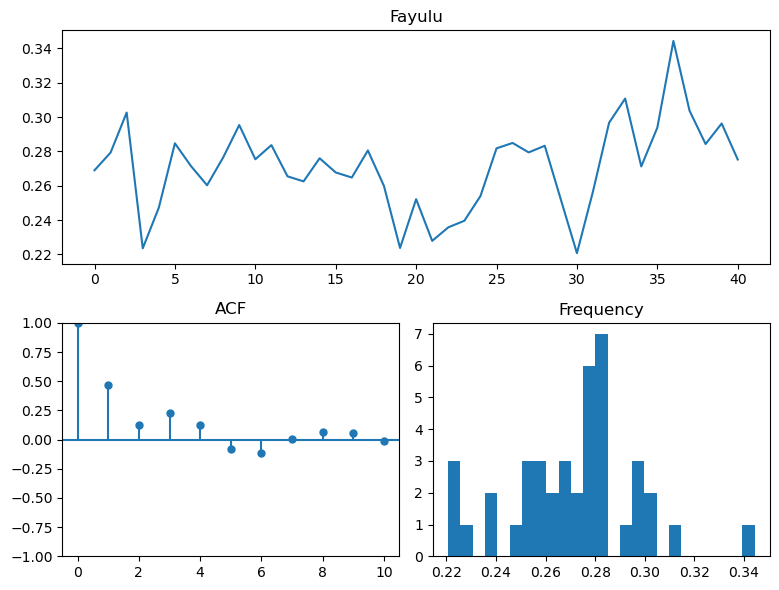

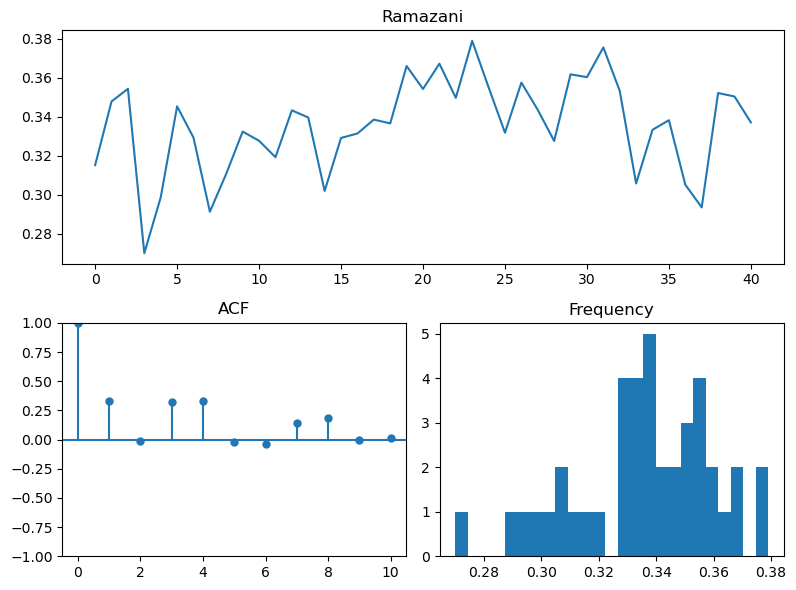

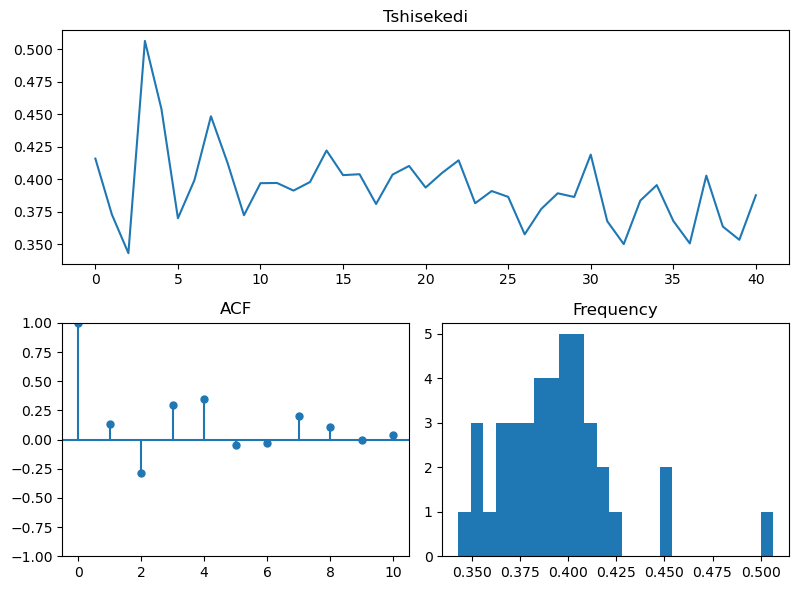

In [6]:
# visual inspection

warnings.filterwarnings('ignore')
[tsdisplay(globals()[f'b_tssw_vader_{leader.lower()}'], lag_max=10, title=f'{leader}') for leader in leaders];

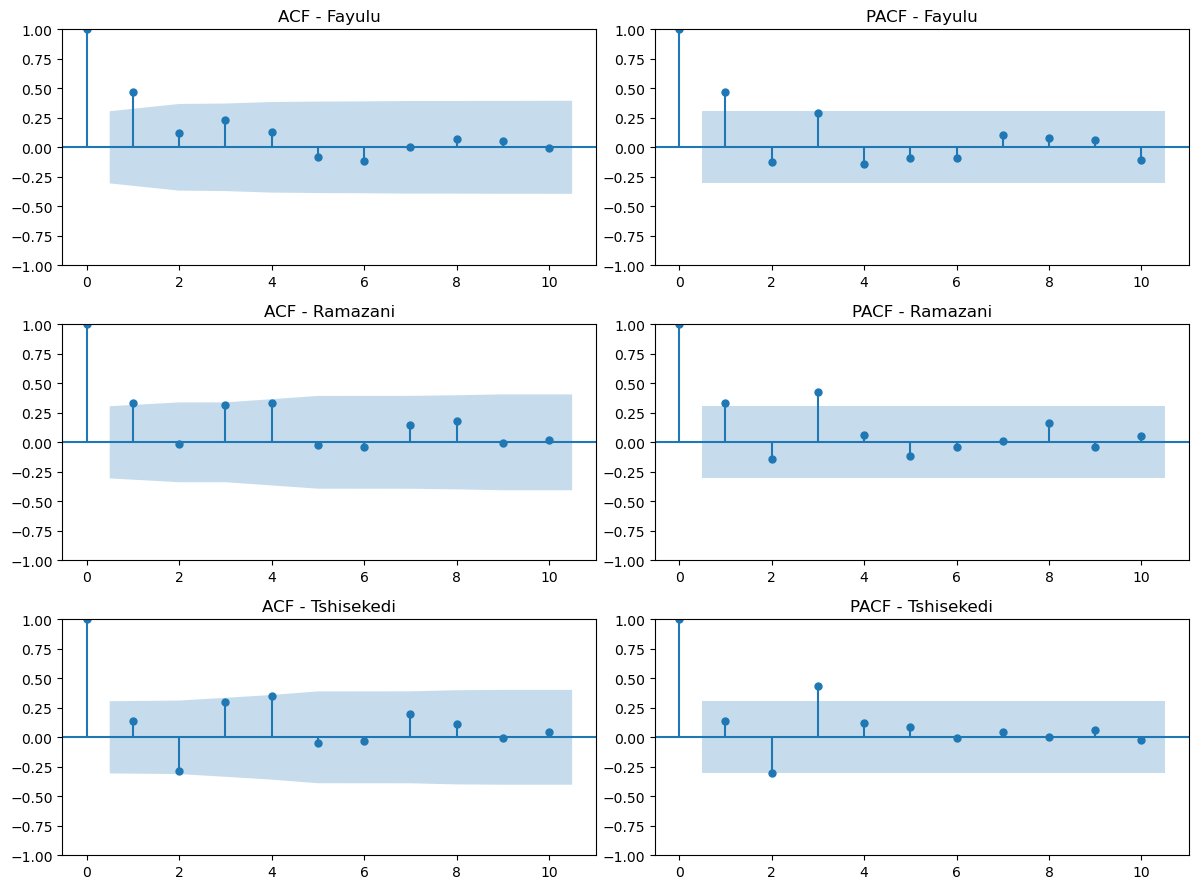

In [7]:
# Correlograms

def plot_correlograms(series_pattern, lags=10):
    """
    Plot ACF and PACF for multiple series in combined subplots.
    
    Parameters:
    series_pattern (str): Pattern like 'b_tssw_vader_'
    lags (int): Number of lags to display
    """
    leaders = ['fayulu', 'ramazani', 'tshisekedi']
    
    fig, axes = plt.subplots(len(leaders), 2, figsize=(12, 3 * len(leaders)))
    
    for i, leader in enumerate(leaders):
        series_name = f"{series_pattern}{leader}"
        series = globals().get(series_name)
        
        if series is None:
            print(f"Series {series_name} not found")
            continue
            
        # ACF
        plot_acf(series.dropna(), lags=lags, ax=axes[i, 0], title=f'ACF - {leader.title()}')
        
        # PACF
        plot_pacf(series.dropna(), lags=lags, ax=axes[i, 1], title=f'PACF - {leader.title()}')
    
    plt.tight_layout()
    plt.show()

plot_correlograms('b_tssw_vader_', lags=10)

In [8]:
# unit root test

def calculate_adf_stats(series_pattern):
    """
    Calculate ADF statistics for time series matching the given pattern.
    
    Parameters:
    series_pattern (str): Pattern like 'b_tssw_vader_' to match series names
    
    Returns:
    pd.DataFrame: ADF statistics table with leaders as columns
    """
    regressions = ["c", "ct", "ctt"]
    leaders = ['fayulu', 'ramazani', 'tshisekedi']
    results = {}
    
    for leader in leaders:
        series_name = f"{series_pattern}{leader}"
        series = globals().get(series_name)
        
        if series is None:
            print(f"Warning: Series '{series_name}' not found")
            continue
            
        leader_results = {}
        for reg in regressions:
            adf_result = adfuller(series.dropna(), regression=reg)
            leader_results[f"ADF ({reg})"] = adf_result[0]
            leader_results[f"p-value ({reg})"] = adf_result[1]
            
        results[leader] = leader_results
    
    return pd.DataFrame(results)

adf_b_tssw_vader = calculate_adf_stats('b_tssw_vader_')
adf_b_tssw_vader

,fayulu,ramazani,tshisekedi
ADF (c),-3.703452,-4.405212,-2.339958e+00
p-value (c),0.004065,0.000291,1.594042e-01
ADF (ct),-3.824318,-4.544925,-8.767194e+00
p-value (ct),0.015369,0.001273,1.226144e-12
ADF (ctt),-3.370948,-2.817611,-8.622193e+00
p-value (ctt),0.149165,0.388675,1.003868e-11


In [9]:
# model selection / parameters fitting (1/2)

def estimate_arima_models(series_pattern, seasonal=False, **kwargs):
    """
    Estimate ARIMA models for time series matching the given pattern.
    
    Parameters:
    series_pattern (str): Pattern like 'b_tssw_vader_' to match series names
    seasonal (bool): Whether to use seasonal ARIMA, defaults to False
    **kwargs: Additional arguments passed to auto_arima
    
    Returns:
    dict: Dictionary of ARIMA model results for each leader
    """
    
    leaders = ['fayulu', 'ramazani', 'tshisekedi']
    
    models = {}
    results_summary = []
    
    for leader in leaders:
        series_name = f"{series_pattern}{leader}"
        series = globals().get(series_name)
        
        if series is None:
            print(f"Warning: Series '{series_name}' not found")
            continue
            
        try:
            # Fit ARIMA model
            model = pm.auto_arima(series.dropna(), seasonal=seasonal,
                                  suppress_warnings=True, **kwargs)
            models[leader] = model
            
            # Store model summary info
            order = model.order
            aic = model.aic()
            bic = model.bic()
            
            results_summary.append({
                'Leader': leader.title(),
                'Series': series_name,
                'Order': order,
                'AIC': aic,
                'BIC': bic
            })
            
        except Exception as e:
            print(f"Error fitting ARIMA for {series_name}: {e}")
            models[leader] = None
            results_summary.append({
                'Leader': leader.title(),
                'Series': series_name,
                'Order': 'Failed',
                'AIC': None,
                'BIC': None
            })
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(results_summary)
    print(f"ARIMA Models for: {series_pattern}")
    print("=" * 50)
    print(f"\nSummary Table:")
    print(summary_df.to_string(index=False))
    
    return models, summary_df

models_b_tssw_vader, summary_b_tssw_vader = estimate_arima_models('b_tssw_vader_')

ARIMA Models for: b_tssw_vader_

Summary Table:
    Leader                  Series     Order         AIC         BIC
    Fayulu     b_tssw_vader_fayulu (0, 0, 1) -192.739374 -187.598657
  Ramazani   b_tssw_vader_ramazani (0, 0, 1) -191.259845 -186.119129
Tshisekedi b_tssw_vader_tshisekedi (2, 1, 1) -176.638361 -168.193964


In [10]:
# model selection / parameters fitting (2/2)

for leader in leaders:
    print("=" * 50)
    print(f"Fitted model for {leader}")
    print("=" * 50)
    display(models_b_tssw_vader[leader.lower()].summary())

Fitted model for Fayulu


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(0, 0, 1)   Log Likelihood                  99.370
Date:                Tue, 18 Nov 2025   AIC                           -192.739
Time:                        17:50:07   BIC                           -187.599
Sample:                    11-20-2018   HQIC                          -190.867
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2712      0.006     42.293      0.000       0.259       0.284
ma.L1          0.6684      0.127      5.280      0.000       0.420       0.917
sigma2         0.0005   9.03e-05      5.012      0.000       0.000       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 4.48
Prob(Q):                              0.80   Prob(JB):                         0.11
Heteroskedasticity (H):               1.21   Skew:                            -0.63
Prob(H) (two-sided):                  0.73   Kurtosis:                         4.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Ramazani


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(0, 0, 1)   Log Likelihood                  98.630
Date:                Tue, 18 Nov 2025   AIC                           -191.260
Time:                        17:50:07   BIC                           -186.119
Sample:                    11-20-2018   HQIC                          -189.388
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3355      0.008     43.897      0.000       0.321       0.350
ma.L1          0.5082      0.360      1.411      0.158      -0.198       1.214
sigma2         0.0005   9.03e-05      5.237      0.000       0.000       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                 4.84
Prob(Q):                              0.75   Prob(JB):                         0.09
Heteroskedasticity (H):               0.74   Skew:                            -0.58
Prob(H) (two-sided):                  0.58   Kurtosis:                         4.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Tshisekedi


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(2, 1, 1)   Log Likelihood                  93.319
Date:                Tue, 18 Nov 2025   AIC                           -176.638
Time:                        17:50:07   BIC                           -168.194
Sample:                    11-20-2018   HQIC                          -173.585
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0019      0.001     -3.563      0.000      -0.003      -0.001
ar.L1         -0.0722      0.185     -0.391      0.696      -0.434       0.290
ar.L2         -0.5792      0.158     -3.660      0.000      -0.889      -0.269
ma.L1         -0.9781      0.675     -1.450      0.147      -2.300       0.344
sigma2         0.0005      0.000      1.520      0.128      -0.000       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.18   Jarque-Bera (JB):                99.82
Prob(Q):                              0.67   Prob(JB):                         0.00
Heteroskedasticity (H):               0.26   Skew:                             1.97
Prob(H) (two-sided):                  0.02   Kurtosis:                         9.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Diagnostics of the Fayulu series


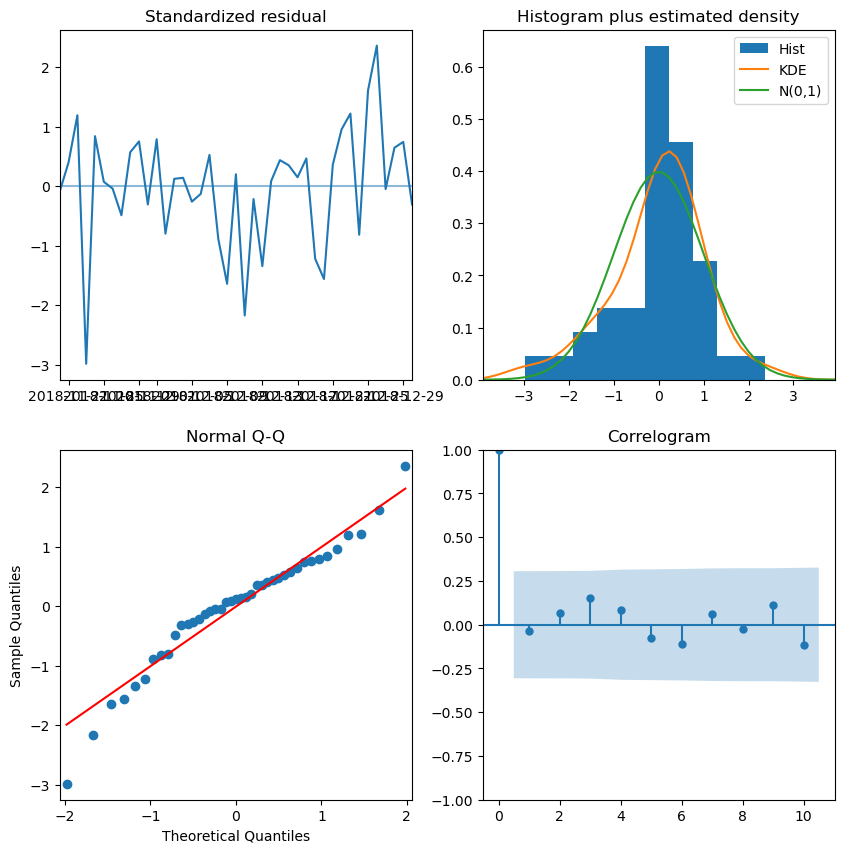

Diagnostics of the Ramazani series


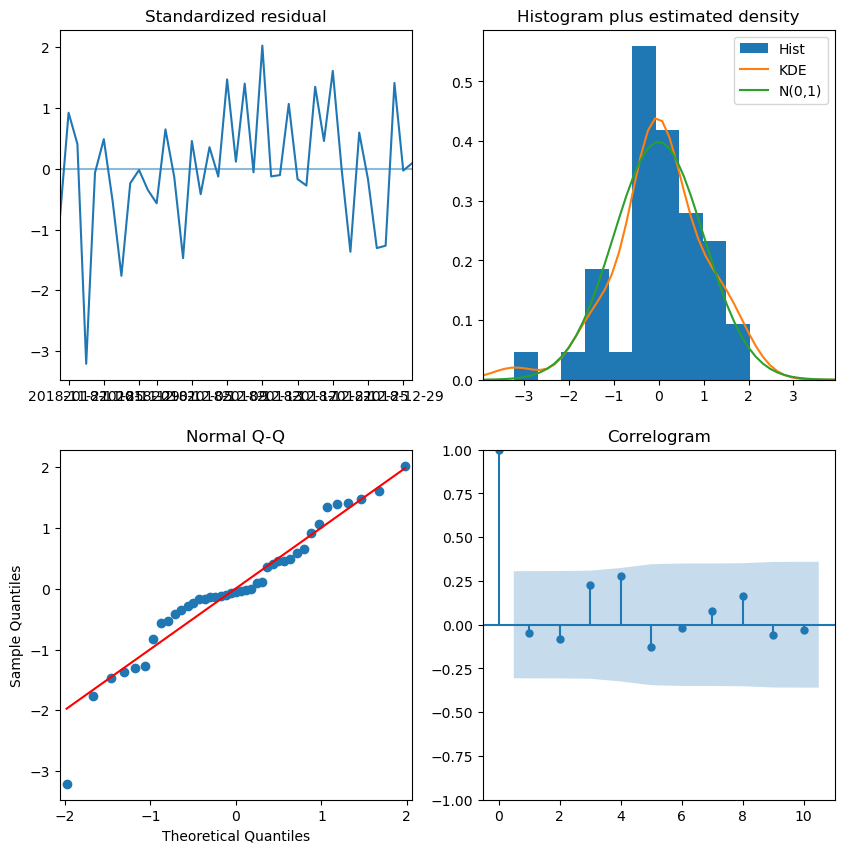

Diagnostics of the Tshisekedi series


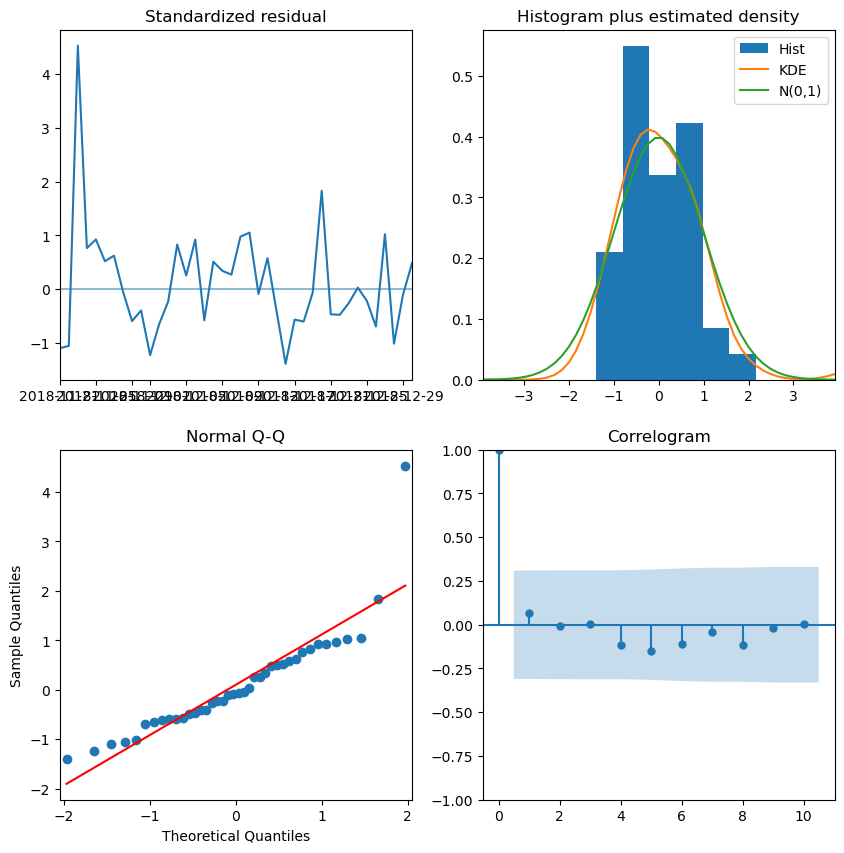

In [11]:
# residual diagnostics / model validation

for leader in leaders:
    print("=" * 50)
    print(f"Diagnostics of the {leader} series")
    print("=" * 50)
    models_b_tssw_vader[leader.lower()].plot_diagnostics(figsize=(10,10))
    plt.show();

In [12]:
# forecasting (ARIMA vs ARIMA-X)

def make_predictions(models_dict, alpha=0.1):
    """
    Make normalized predictions with confidence intervals for multiple leaders.
    
    Parameters:
    models_dict (dict): Dictionary of {leader: model} pairs
    alpha (float): Significance level for confidence intervals
    
    Returns:
    tuple: (predictions_df, conf_int_df)
    """
    leaders = list(models_dict.keys())
    preds_raw = {}
    conf_ints = {}
    
    for leader, model in models_dict.items():
        try:
            pred, conf = model.predict(n_periods=1, return_conf_int=True, alpha=alpha)
            preds_raw[leader] = float(pred[0])
            conf_ints[leader] = (float(conf[0, 0]), float(conf[0, 1]))
        except Exception as e:
            preds_raw[leader] = np.nan
            conf_ints[leader] = (np.nan, np.nan)
            print(f"Warning: prediction failed for {leader}: {e}")
    
    # Normalize predictions to sum to 1
    predictions_norm = standardizer(*preds_raw.values())
    
    # Create results DataFrame
    results = []
    for i, leader in enumerate(leaders):
        results.append({
            'Leader': leader,
            'Forecast': predictions_norm[i],
            'Lower_Bound': conf_ints[leader][0],
            'Upper_Bound': conf_ints[leader][1]
        })
    
    predictions_df = pd.DataFrame(results)
    return predictions_df

b_tssw_vader_predictions = make_predictions(models_b_tssw_vader)
print('='*50)
print('One-point-ahead forecast for TSSW index (VADER)')
print('='*50)
b_tssw_vader_predictions

One-point-ahead forecast for TSSW index (VADER)


,Leader,Forecast,Lower_Bound,Upper_Bound
0,fayulu,0.271643,0.231820,0.301821
1,ramazani,0.342571,0.300724,0.372256
2,tshisekedi,0.385786,0.343197,0.414678


#### WG

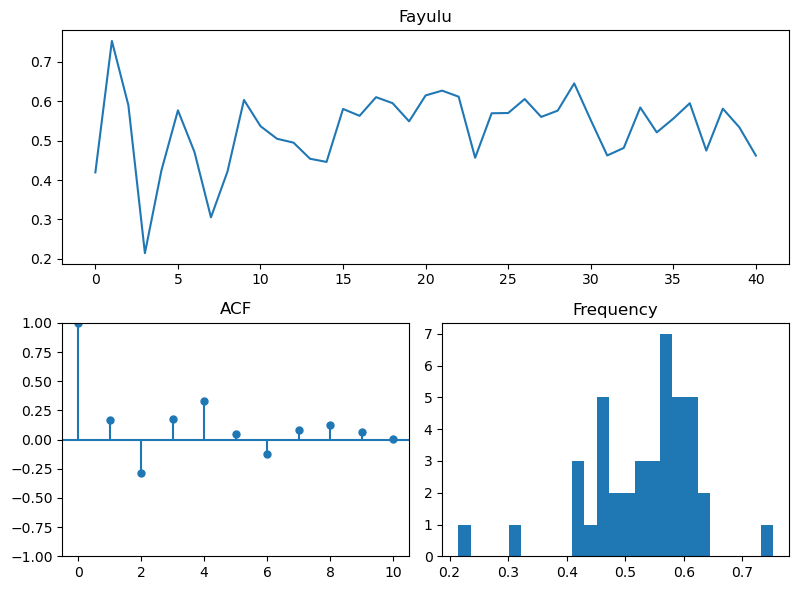

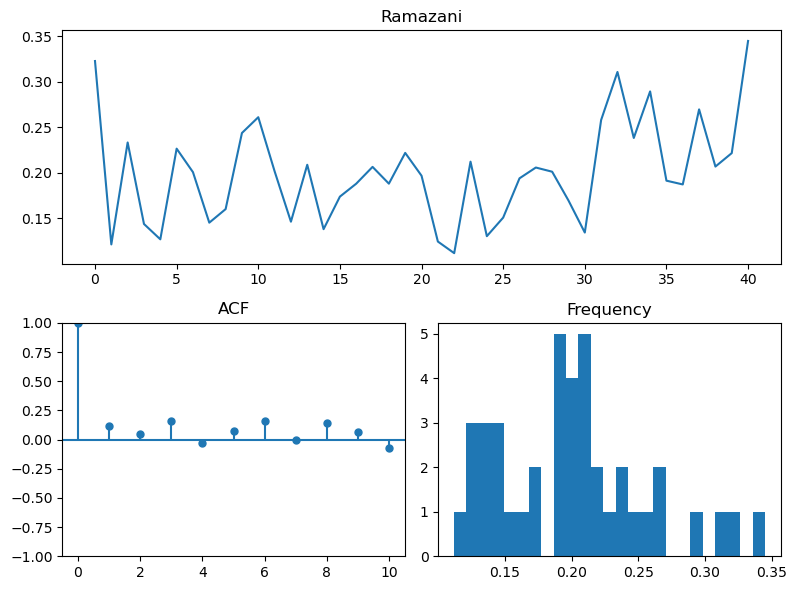

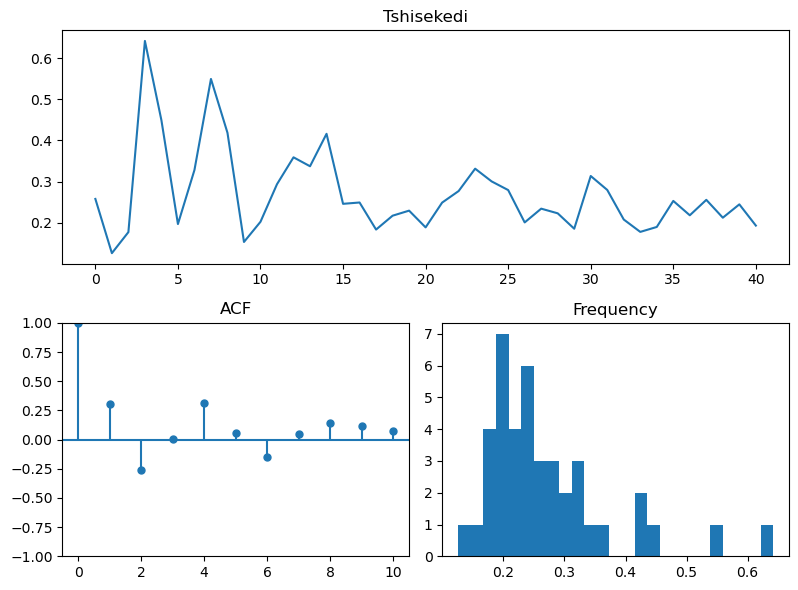

In [13]:
# visual inspection

warnings.filterwarnings('ignore')
[tsdisplay(globals()[f'b_wg_vader_{leader.lower()}'], lag_max=10, title=f'{leader}') for leader in leaders];

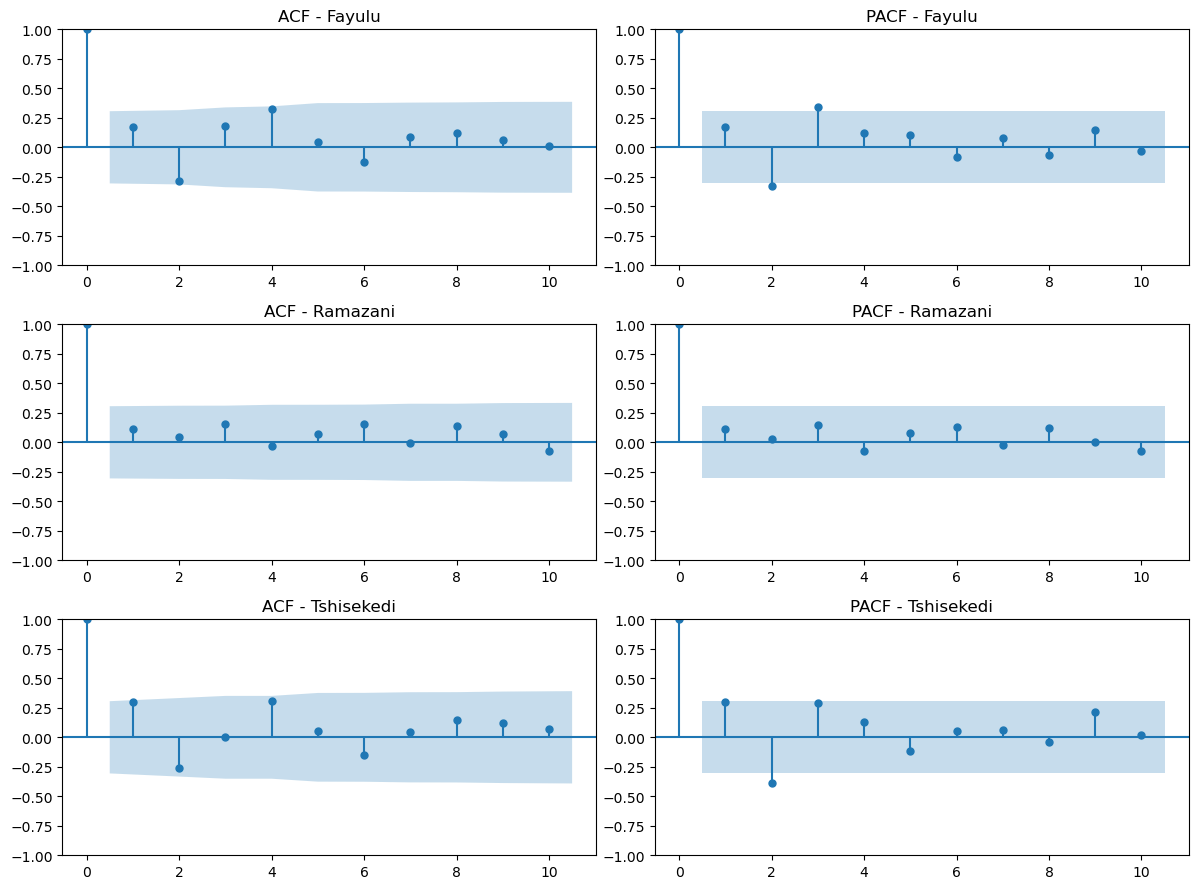

In [14]:
# Correlograms

plot_correlograms('b_wg_vader_', lags=10)

In [15]:
# unit root test

adf_b_tssw_vader = calculate_adf_stats('b_wg_vader_')
adf_b_tssw_vader

,fayulu,ramazani,tshisekedi
ADF (c),-5.251326,-5.238082,-4.460207
p-value (c),0.000007,0.000007,0.000232
ADF (ct),-5.289525,-6.014596,-5.459893
p-value (ct),0.000059,0.000002,0.000028
ADF (ctt),-5.422165,-6.455743,-6.362142
p-value (ctt),0.000178,0.000001,0.000002


In [16]:
# model selection / parameters fitting

models_b_wg_vader, summary_b_wg_vader = estimate_arima_models('b_wg_vader_')

for leader in leaders:
    print("=" * 50)
    print(f"Fitted model for {leader}")
    print("=" * 50)
    display(models_b_wg_vader[leader.lower()].summary())

ARIMA Models for: b_wg_vader_

Summary Table:
    Leader                Series     Order         AIC         BIC
    Fayulu     b_wg_vader_fayulu (3, 0, 0)  -84.586770  -76.018910
  Ramazani   b_wg_vader_ramazani (0, 0, 0) -116.143789 -112.716645
Tshisekedi b_wg_vader_tshisekedi (2, 1, 2)  -72.448161  -62.314885
Fitted model for Fayulu


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(3, 0, 0)   Log Likelihood                  47.293
Date:                Tue, 18 Nov 2025   AIC                            -84.587
Time:                        17:50:14   BIC                            -76.019
Sample:                    11-20-2018   HQIC                           -81.467
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3341      0.158      2.116      0.034       0.025       0.644
ar.L1          0.4637      0.197      2.353      0.019       0.078       0.850
ar.L2         -0.5790      0.132     -4.380      0.000      -0.838      -0.320
ar.L3          0.4838      0.182      2.664      0.008       0.128       0.840
sigma2         0.0056      0.002      3.410      0.001       0.002       0.009
===================================================================================
Ljung-Box (L1) (Q):                   0.76   Jarque-Bera (JB):                 0.47
Prob(Q):                              0.38   Prob(JB):                         0.79
Heteroskedasticity (H):               0.39   Skew:                             0.17
Prob(H) (two-sided):                  0.09   Kurtosis:                         2.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Ramazani


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:                        SARIMAX   Log Likelihood                  60.072
Date:                Tue, 18 Nov 2025   AIC                           -116.144
Time:                        17:50:14   BIC                           -112.717
Sample:                    11-20-2018   HQIC                          -114.896
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2003      0.010     20.756      0.000       0.181       0.219
sigma2         0.0031      0.001      4.071      0.000       0.002       0.005
===================================================================================
Ljung-Box (L1) (Q):                   0.58   Jarque-Bera (JB):                 2.45
Prob(Q):                              0.45   Prob(JB):                         0.29
Heteroskedasticity (H):               1.27   Skew:                             0.60
Prob(H) (two-sided):                  0.66   Kurtosis:                         2.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Tshisekedi


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(2, 1, 2)   Log Likelihood                  42.224
Date:                Tue, 18 Nov 2025   AIC                            -72.448
Time:                        17:50:14   BIC                            -62.315
Sample:                    11-20-2018   HQIC                           -68.784
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0045      0.003     -1.587      0.112      -0.010       0.001
ar.L1          0.2713      0.286      0.947      0.344      -0.290       0.833
ar.L2         -0.5513      0.173     -3.187      0.001      -0.890      -0.212
ma.L1         -0.9373      0.468     -2.004      0.045      -1.854      -0.021
ma.L2         -0.0304      0.404     -0.075      0.940      -0.823       0.762
sigma2         0.0065      0.003      1.945      0.052   -5.03e-05       0.013
===================================================================================
Ljung-Box (L1) (Q):                   0.16   Jarque-Bera (JB):                44.93
Prob(Q):                              0.69   Prob(JB):                         0.00
Heteroskedasticity (H):               0.14   Skew:                             1.53
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Diagnostics of the Fayulu series


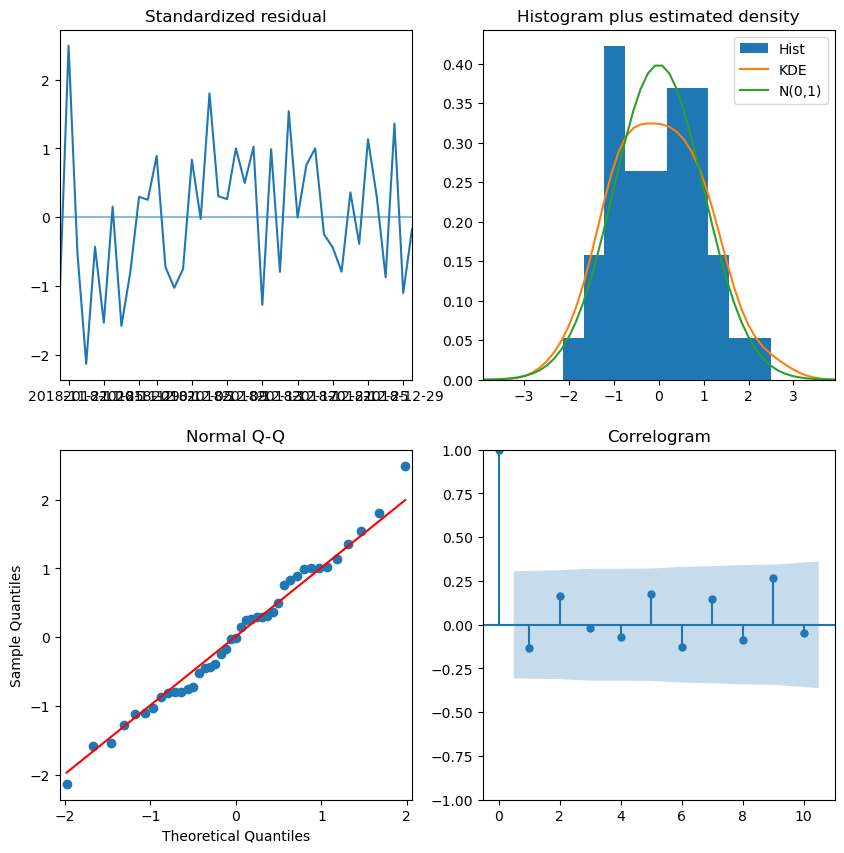

Diagnostics of the Ramazani series


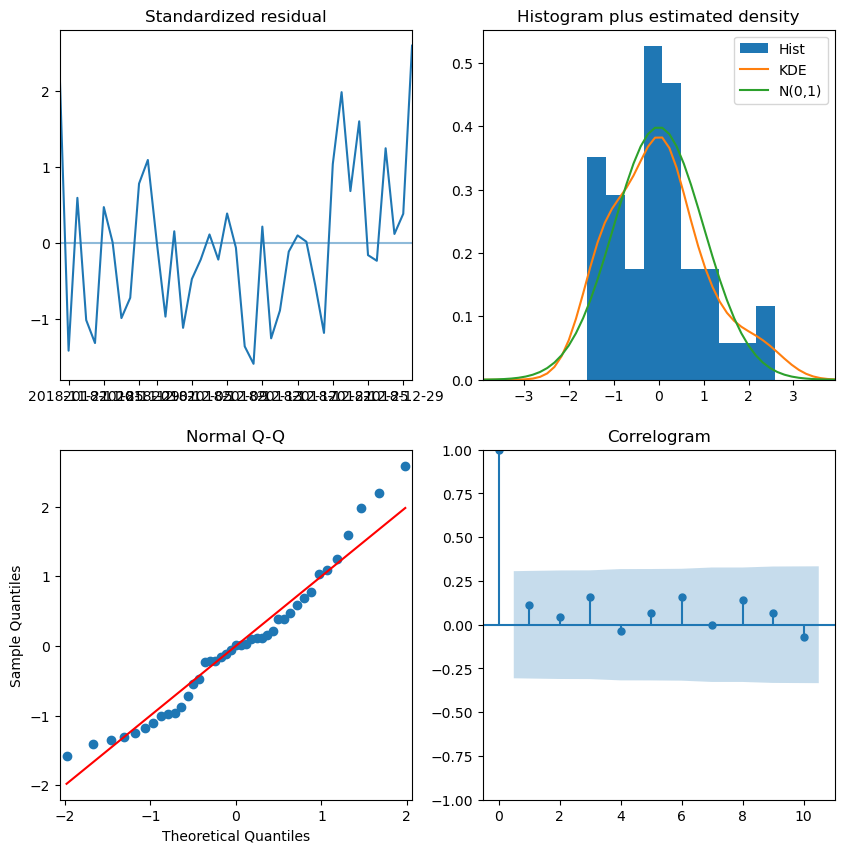

Diagnostics of the Tshisekedi series


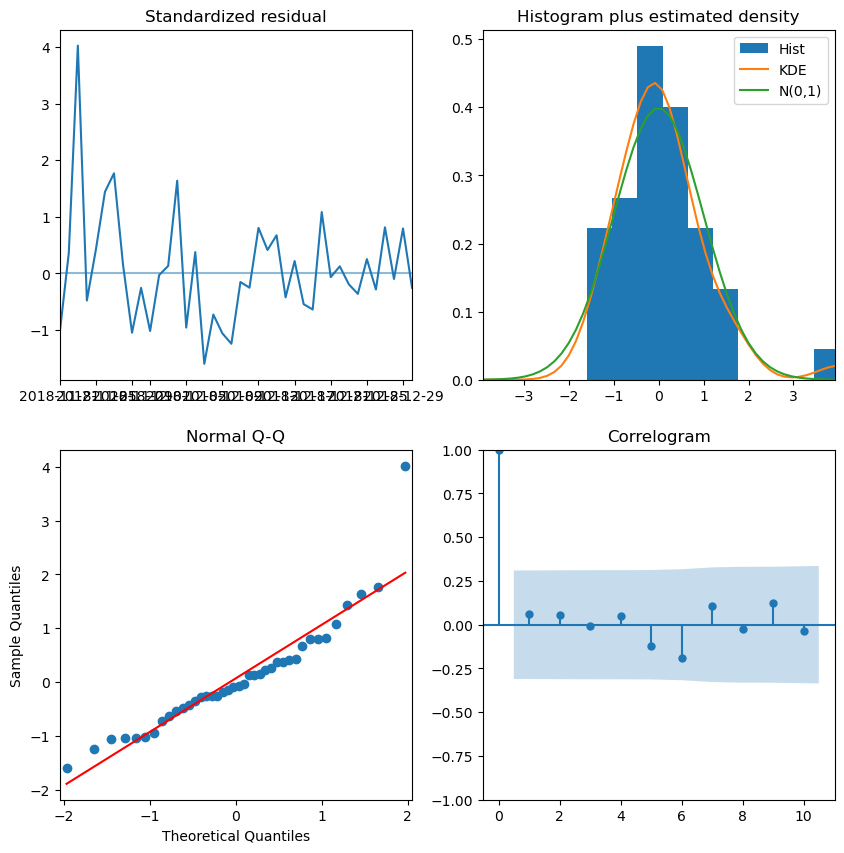

In [17]:
# residual diagnostics / model validation

for leader in leaders:
    print("=" * 50)
    print(f"Diagnostics of the {leader} series")
    print("=" * 50)
    models_b_wg_vader[leader.lower()].plot_diagnostics(figsize=(10,10))
    plt.show();

In [18]:
# forecasting (ARIMA vs ARIMA-X)

b_wg_vader_predictions = make_predictions(models_b_wg_vader)
print('='*50)
print('One-point-ahead forecast for WG index (VADER)')
print('='*50)
b_wg_vader_predictions

One-point-ahead forecast for WG index (VADER)


,Leader,Forecast,Lower_Bound,Upper_Bound
0,fayulu,0.581769,0.396761,0.643932
1,ramazani,0.223957,0.108357,0.292267
2,tshisekedi,0.194274,0.041260,0.306265


#### YHRM

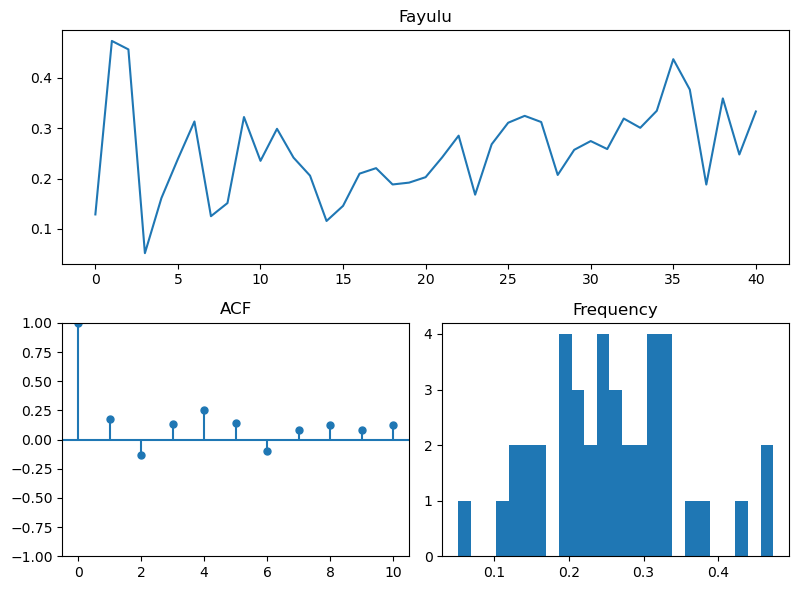

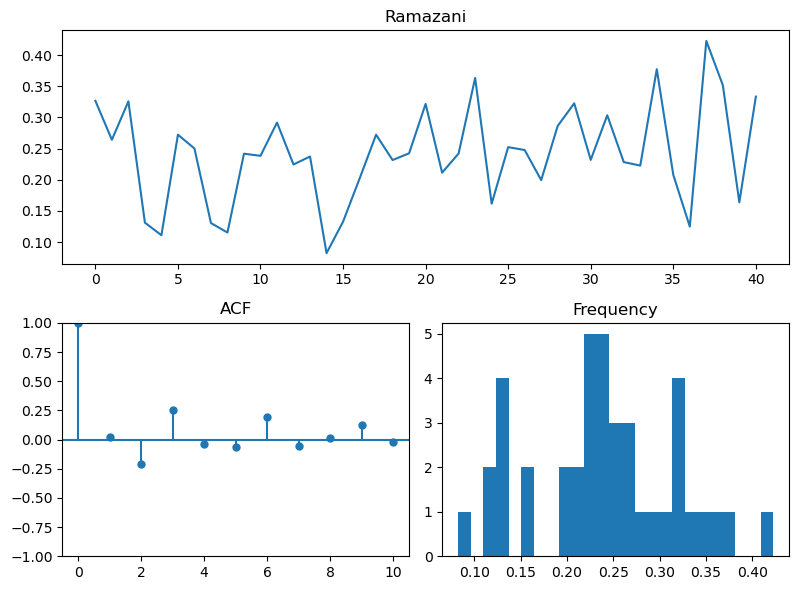

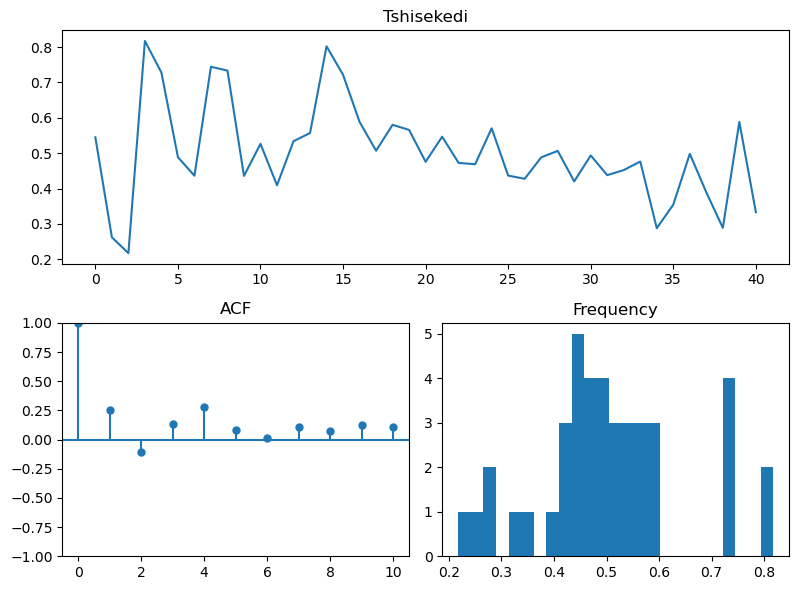

In [19]:
# visual inspection

warnings.filterwarnings('ignore')
[tsdisplay(globals()[f'b_yhrm_vader_{leader.lower()}'], lag_max=10, title=f'{leader}') for leader in leaders];

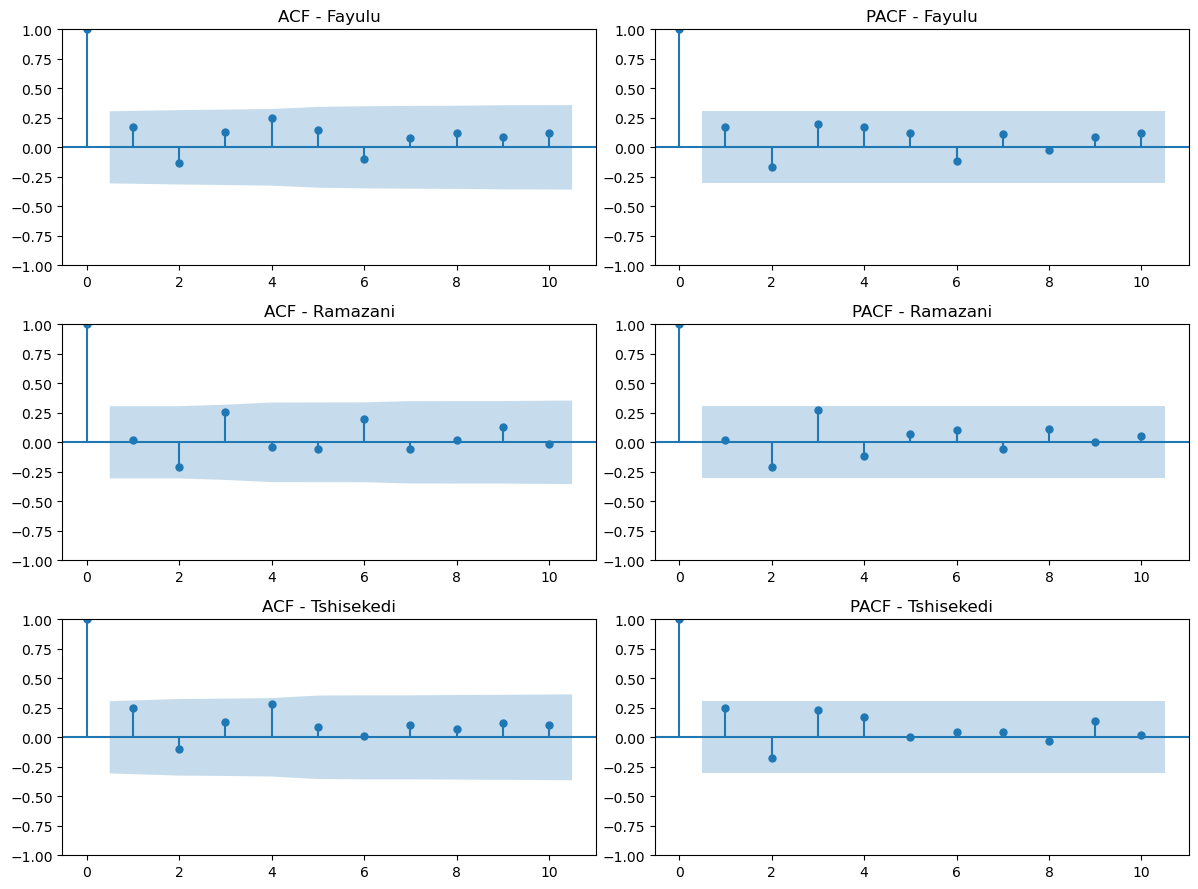

In [20]:
# Correlograms

plot_correlograms('b_yhrm_vader_', lags=10)

In [21]:
# unit root test

adf_b_tssw_vader = calculate_adf_stats('b_yhrm_vader_')
adf_b_tssw_vader

,fayulu,ramazani,tshisekedi
ADF (c),-5.240695,-2.904786,-4.628945
p-value (c),0.000007,0.044794,0.000114
ADF (ct),-5.484861,-3.661541,-5.140309
p-value (ct),0.000025,0.025018,0.000113
ADF (ctt),-6.165322,-3.593238,-0.894363
p-value (ctt),0.000006,0.091131,0.990500


In [22]:
# model selection / parameters fitting

models_b_yhrm_vader, summary_b_yhrm_vader = estimate_arima_models('b_yhrm_vader_')

for leader in leaders:
    print("=" * 50)
    print(f"Fitted model for {leader}")
    print("=" * 50)
    display(models_b_yhrm_vader[leader.lower()].summary())

ARIMA Models for: b_yhrm_vader_

Summary Table:
    Leader                  Series     Order        AIC        BIC
    Fayulu     b_yhrm_vader_fayulu (4, 0, 0) -75.310642 -65.029210
  Ramazani   b_yhrm_vader_ramazani (0, 0, 0) -88.458542 -85.031398
Tshisekedi b_yhrm_vader_tshisekedi (2, 1, 1) -43.742304 -36.986786
Fitted model for Fayulu


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(4, 0, 0)   Log Likelihood                  43.655
Date:                Tue, 18 Nov 2025   AIC                            -75.311
Time:                        17:50:21   BIC                            -65.029
Sample:                    11-20-2018   HQIC                           -71.567
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1446      0.082      1.753      0.080      -0.017       0.306
ar.L1          0.2345      0.174      1.344      0.179      -0.107       0.576
ar.L2         -0.2510      0.171     -1.466      0.143      -0.587       0.085
ar.L3          0.1257      0.233      0.540      0.589      -0.330       0.582
ar.L4          0.3312      0.236      1.404      0.160      -0.131       0.794
sigma2         0.0068      0.002      3.728      0.000       0.003       0.010
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                 0.51
Prob(Q):                              0.70   Prob(JB):                         0.78
Heteroskedasticity (H):               0.67   Skew:                             0.22
Prob(H) (two-sided):                  0.46   Kurtosis:                         2.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Ramazani


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:                        SARIMAX   Log Likelihood                  46.229
Date:                Tue, 18 Nov 2025   AIC                            -88.459
Time:                        17:50:21   BIC                            -85.031
Sample:                    11-20-2018   HQIC                           -87.211
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2415      0.012     19.736      0.000       0.218       0.266
sigma2         0.0061      0.002      3.998      0.000       0.003       0.009
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 0.33
Prob(Q):                              0.90   Prob(JB):                         0.85
Heteroskedasticity (H):               1.41   Skew:                             0.01
Prob(H) (two-sided):                  0.53   Kurtosis:                         2.56
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Tshisekedi


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(2, 1, 1)   Log Likelihood                  25.871
Date:                Tue, 18 Nov 2025   AIC                            -43.742
Time:                        17:50:21   BIC                            -36.987
Sample:                    11-20-2018   HQIC                           -41.300
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0948      0.204      0.466      0.642      -0.304       0.494
ar.L2         -0.4648      0.154     -3.015      0.003      -0.767      -0.163
ma.L1         -0.7199      0.209     -3.437      0.001      -1.130      -0.309
sigma2         0.0155      0.004      3.937      0.000       0.008       0.023
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                10.19
Prob(Q):                              0.87   Prob(JB):                         0.01
Heteroskedasticity (H):               0.41   Skew:                             0.97
Prob(H) (two-sided):                  0.12   Kurtosis:                         4.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Diagnostics of the Fayulu series


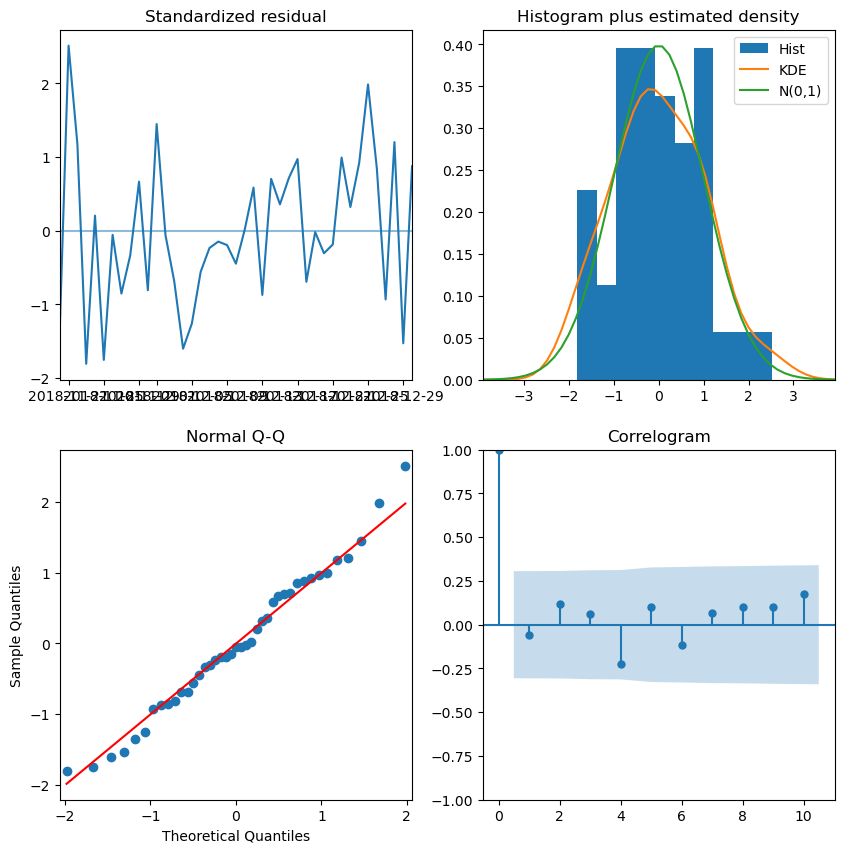

Diagnostics of the Ramazani series


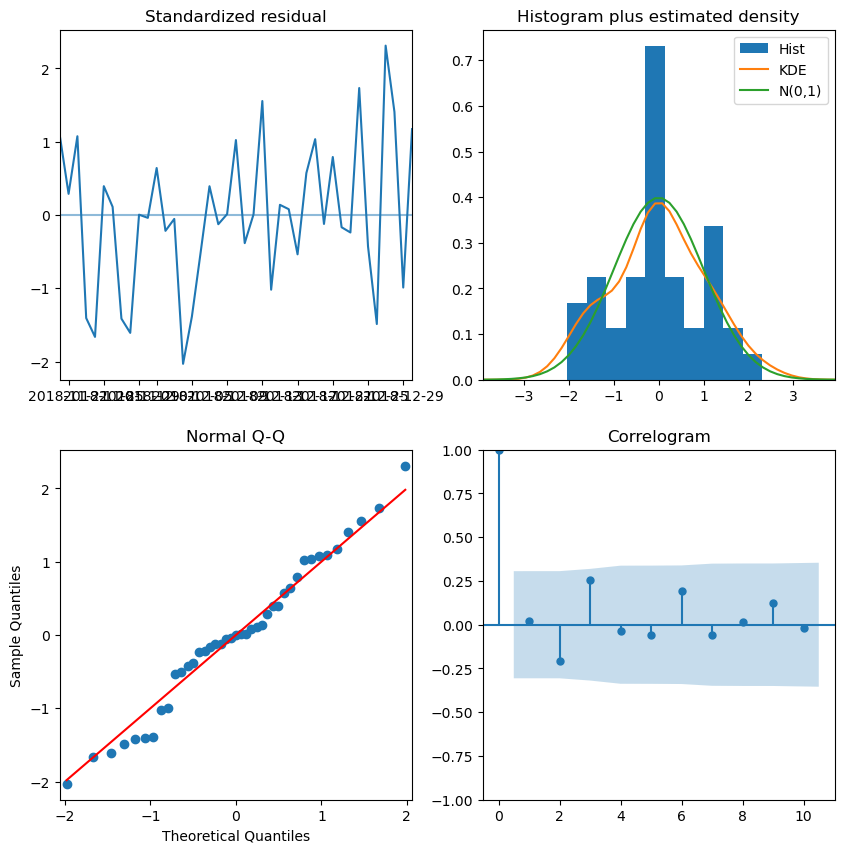

Diagnostics of the Tshisekedi series


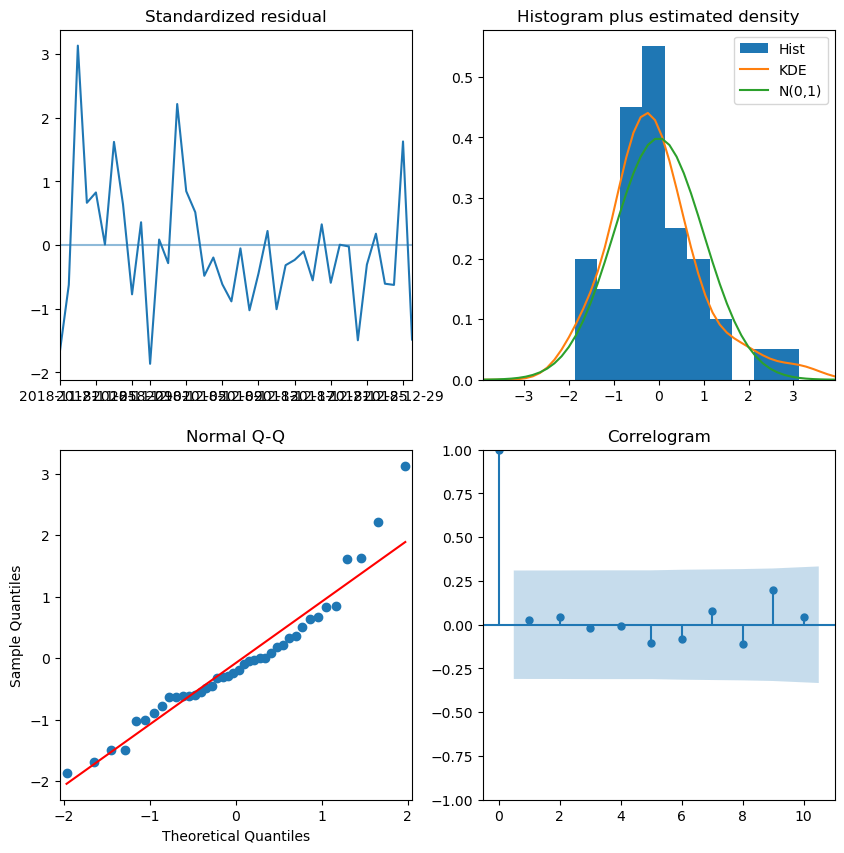

In [23]:
# residual diagnostics / model validation

for leader in leaders:
    print("=" * 50)
    print(f"Diagnostics of the {leader} series")
    print("=" * 50)
    models_b_yhrm_vader[leader.lower()].plot_diagnostics(figsize=(10,10))
    plt.show();

In [24]:
# forecasting (ARIMA vs ARIMA-X)

b_yhrm_vader_predictions = make_predictions(models_b_yhrm_vader)
print('='*50)
print('One-point-ahead forecast for YHRM index (VADER)')
print('='*50)
b_yhrm_vader_predictions

One-point-ahead forecast for YHRM index (VADER)


,Leader,Forecast,Lower_Bound,Upper_Bound
0,fayulu,0.329935,0.132233,0.403775
1,ramazani,0.297326,0.112631,0.370402
2,tshisekedi,0.372739,0.098305,0.507244


### BERT results

#### TSSW

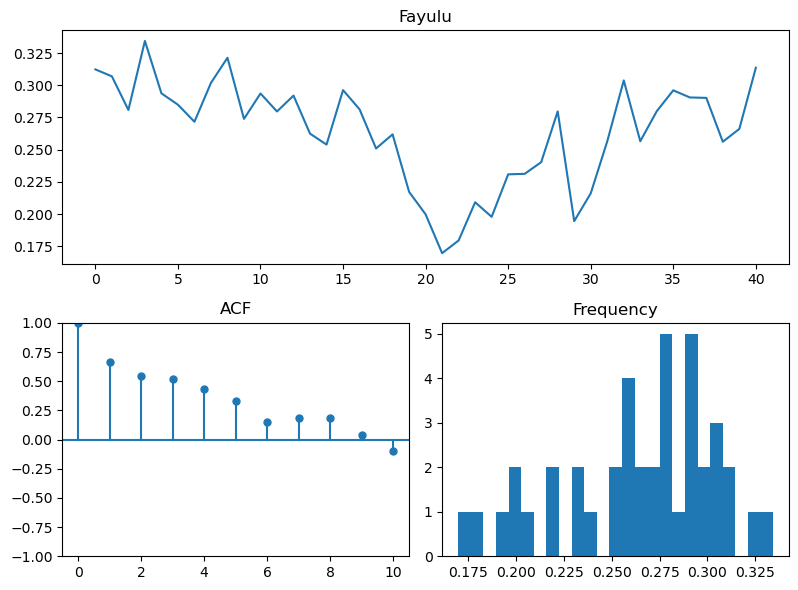

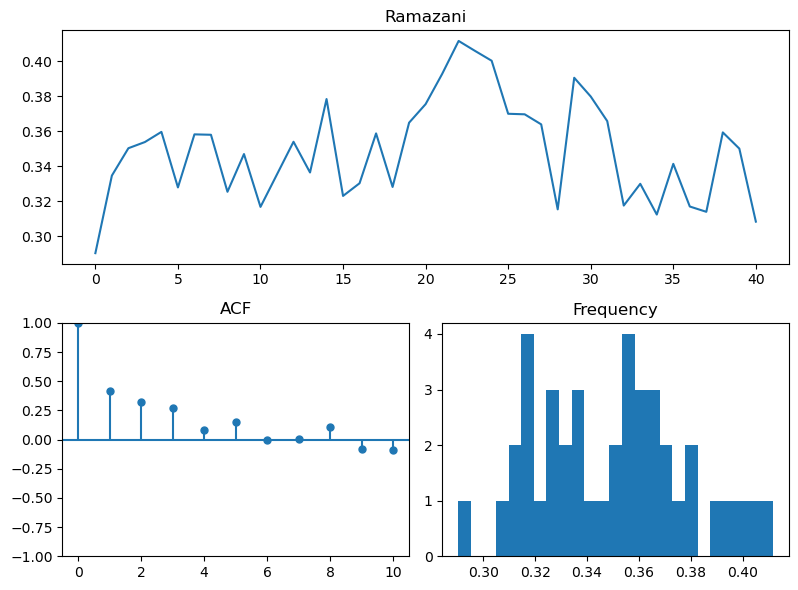

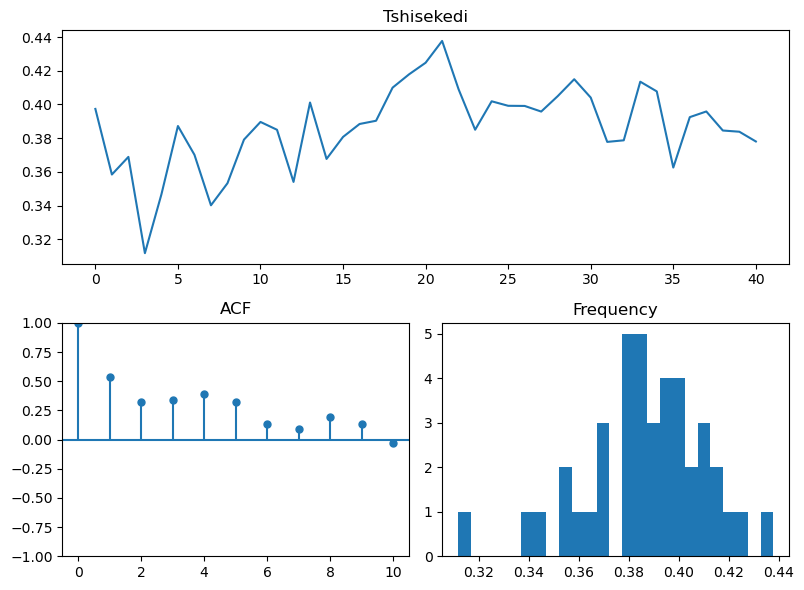

In [25]:
# visual inspection

warnings.filterwarnings('ignore')
[tsdisplay(globals()[f'b_tssw_bert_{leader.lower()}'], lag_max=10, title=f'{leader}') for leader in leaders];

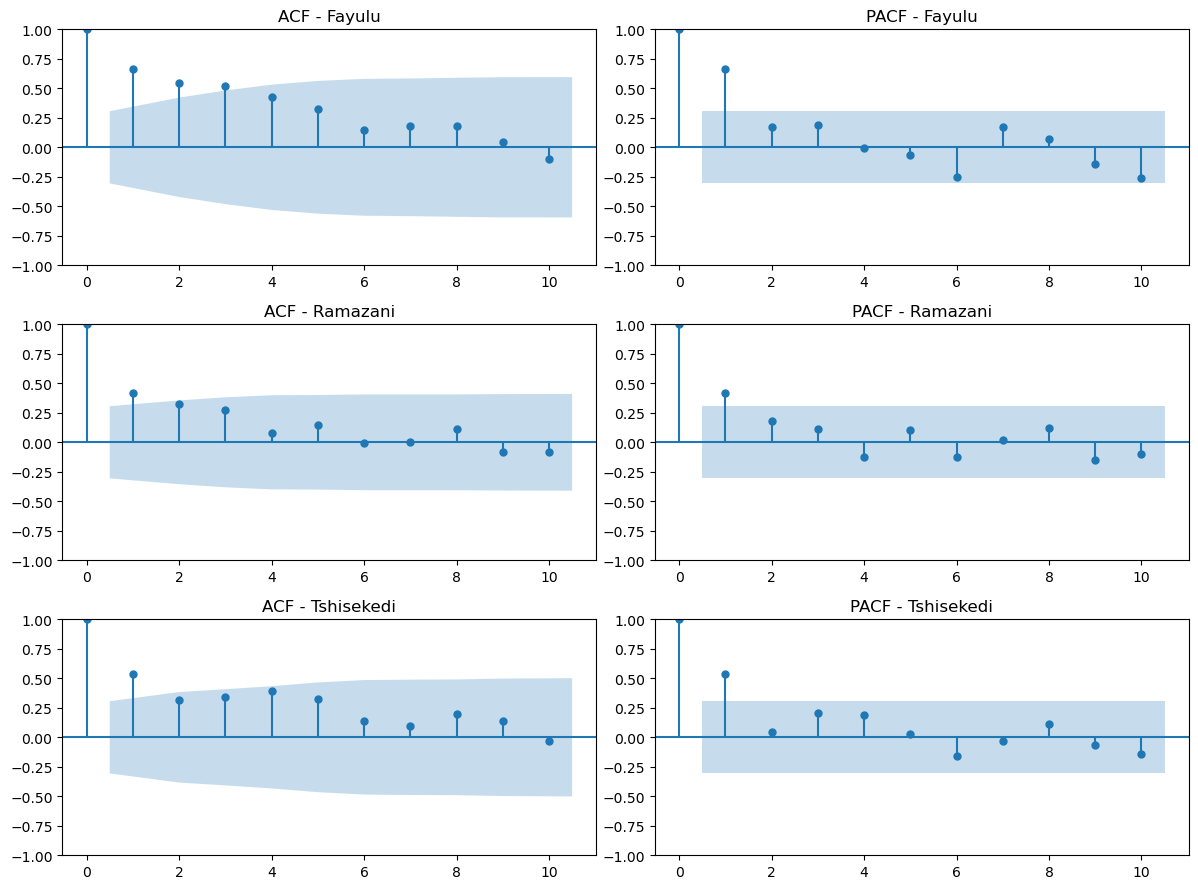

In [26]:
# Correlograms

plot_correlograms('b_tssw_bert_', lags=10)

In [27]:
# unit root test

adf_b_tssw_vader = calculate_adf_stats('b_tssw_bert_')
adf_b_tssw_vader

,fayulu,ramazani,tshisekedi
ADF (c),-2.617372,-4.007031,-3.393763
p-value (c),0.089460,0.001374,0.011173
ADF (ct),-2.413997,-3.880723,-3.971259
p-value (ct),0.372204,0.012894,0.009657
ADF (ctt),-3.737005,-4.379221,-5.783684
p-value (ctt),0.064092,0.009787,0.000035


In [28]:
# model selection / parameters fitting

models_b_tssw_bert, summary_b_tssw_bert = estimate_arima_models('b_tssw_bert_')

for leader in leaders:
    print("=" * 50)
    print(f"Fitted model for {leader}")
    print("=" * 50)
    display(models_b_tssw_bert[leader.lower()].summary())

ARIMA Models for: b_tssw_bert_

Summary Table:
    Leader                 Series     Order         AIC         BIC
    Fayulu     b_tssw_bert_fayulu (1, 0, 0) -167.715457 -162.574741
  Ramazani   b_tssw_bert_ramazani (1, 0, 0) -178.507188 -173.366471
Tshisekedi b_tssw_bert_tshisekedi (0, 1, 1) -191.159540 -187.781781
Fitted model for Fayulu


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(1, 0, 0)   Log Likelihood                  86.858
Date:                Tue, 18 Nov 2025   AIC                           -167.715
Time:                        17:50:27   BIC                           -162.575
Sample:                    11-20-2018   HQIC                          -165.843
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0796      0.037      2.140      0.032       0.007       0.153
ar.L1          0.7042      0.139      5.068      0.000       0.432       0.977
sigma2         0.0008      0.000      4.520      0.000       0.000       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.64   Jarque-Bera (JB):                 0.73
Prob(Q):                              0.42   Prob(JB):                         0.69
Heteroskedasticity (H):               1.69   Skew:                            -0.32
Prob(H) (two-sided):                  0.34   Kurtosis:                         3.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Ramazani


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(1, 0, 0)   Log Likelihood                  92.254
Date:                Tue, 18 Nov 2025   AIC                           -178.507
Time:                        17:50:27   BIC                           -173.366
Sample:                    11-20-2018   HQIC                          -176.635
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1789      0.050      3.602      0.000       0.082       0.276
ar.L1          0.4848      0.143      3.400      0.001       0.205       0.764
sigma2         0.0006      0.000      3.629      0.000       0.000       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.67   Jarque-Bera (JB):                 0.84
Prob(Q):                              0.41   Prob(JB):                         0.66
Heteroskedasticity (H):               1.82   Skew:                            -0.13
Prob(H) (two-sided):                  0.28   Kurtosis:                         2.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Tshisekedi


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(0, 1, 1)   Log Likelihood                  97.580
Date:                Tue, 18 Nov 2025   AIC                           -191.160
Time:                        17:50:27   BIC                           -187.782
Sample:                    11-20-2018   HQIC                          -189.938
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6624      0.130     -5.111      0.000      -0.916      -0.408
sigma2         0.0004   9.44e-05      4.645      0.000       0.000       0.001
===================================================================================
Ljung-Box (L1) (Q):                   1.01   Jarque-Bera (JB):                 1.75
Prob(Q):                              0.31   Prob(JB):                         0.42
Heteroskedasticity (H):               0.37   Skew:                            -0.50
Prob(H) (two-sided):                  0.09   Kurtosis:                         3.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Diagnostics of the Fayulu series


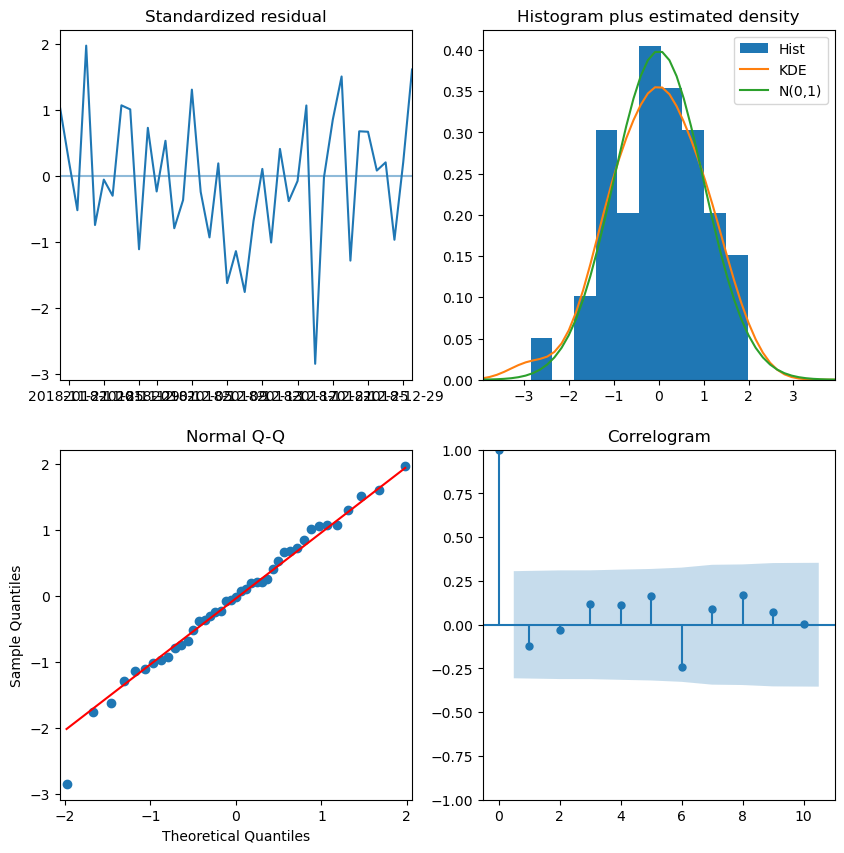

Diagnostics of the Ramazani series


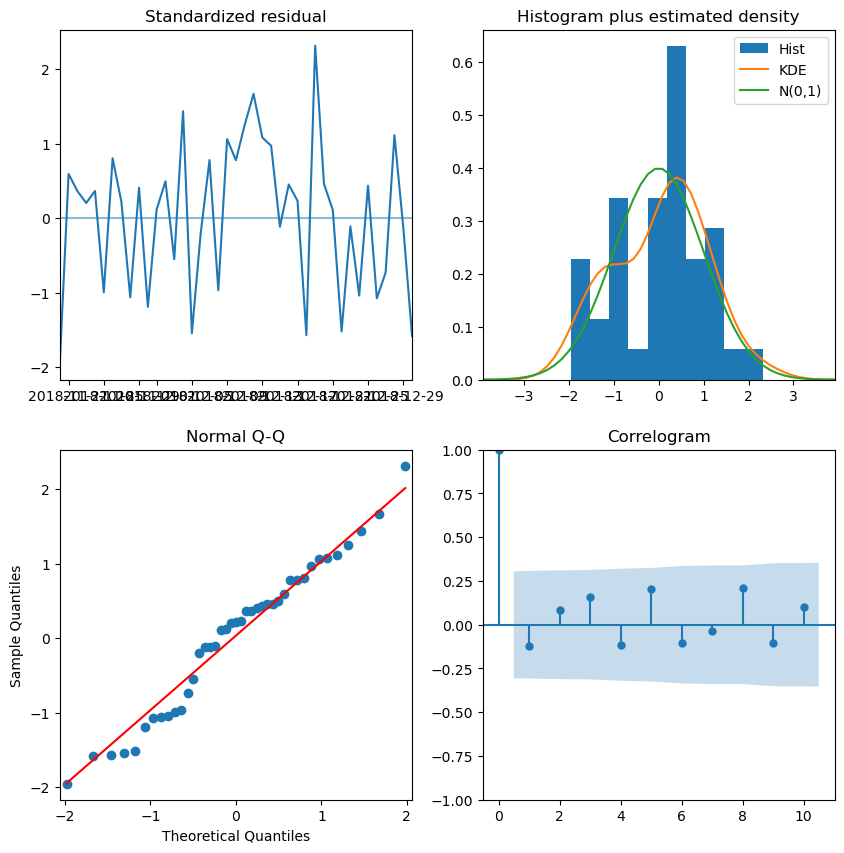

Diagnostics of the Tshisekedi series


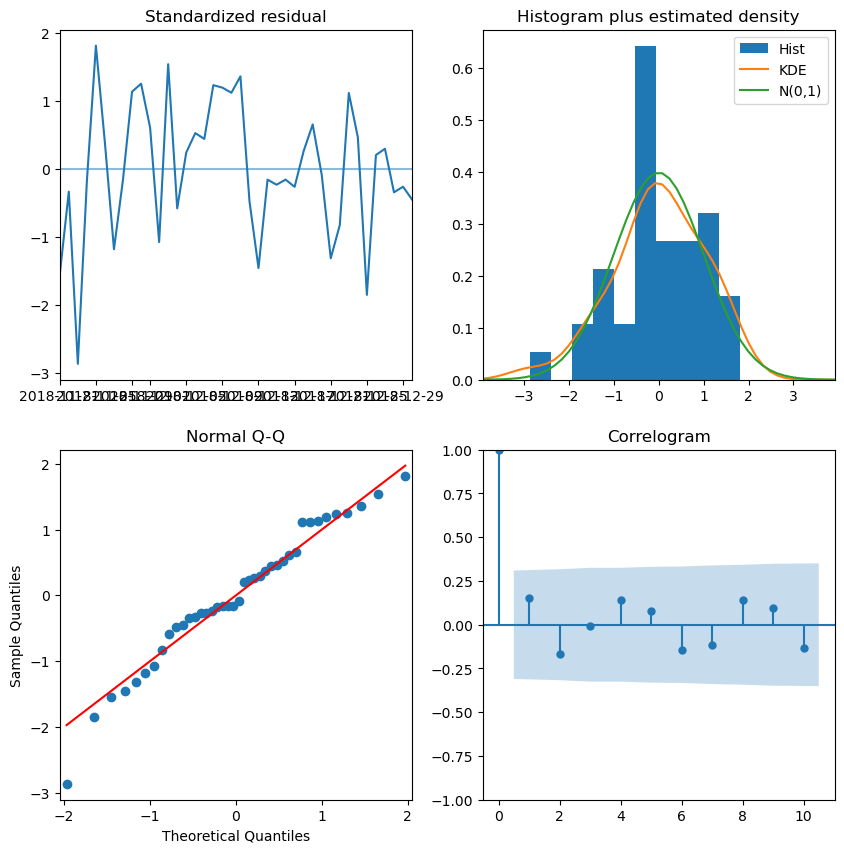

In [29]:
# residual diagnostics / model validation

for leader in leaders:
    print("=" * 50)
    print(f"Diagnostics of the {leader} series")
    print("=" * 50)
    models_b_tssw_bert[leader.lower()].plot_diagnostics(figsize=(10,10))
    plt.show();

In [30]:
# forecasting (ARIMA vs ARIMA-X)

b_tssw_bert_predictions = make_predictions(models_b_tssw_bert)
print('='*50)
print('One-point-ahead forecast for TSSW index (BERT)')
print('='*50)
b_tssw_bert_predictions

One-point-ahead forecast for TSSW index (BERT)


,Leader,Forecast,Lower_Bound,Upper_Bound
0,fayulu,0.296594,0.253035,0.347915
1,ramazani,0.324114,0.286538,0.370172
2,tshisekedi,0.379292,0.349810,0.418699


#### WG

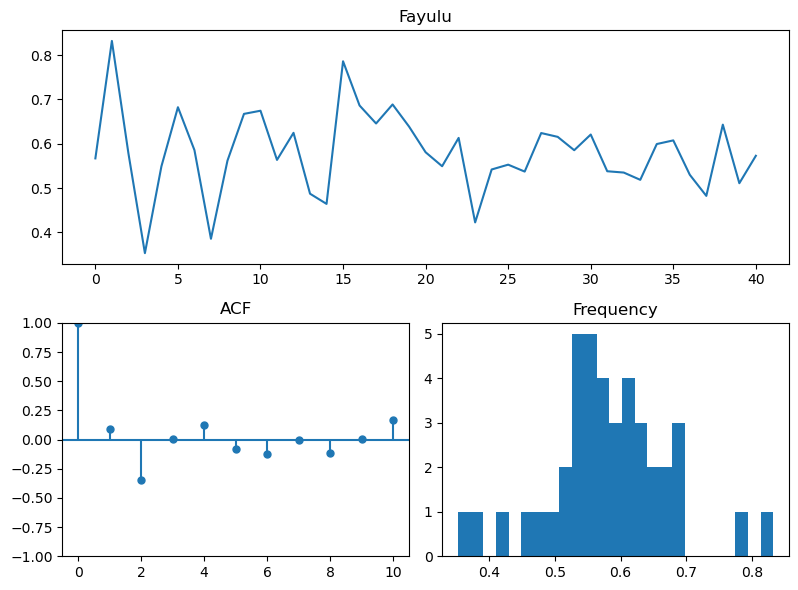

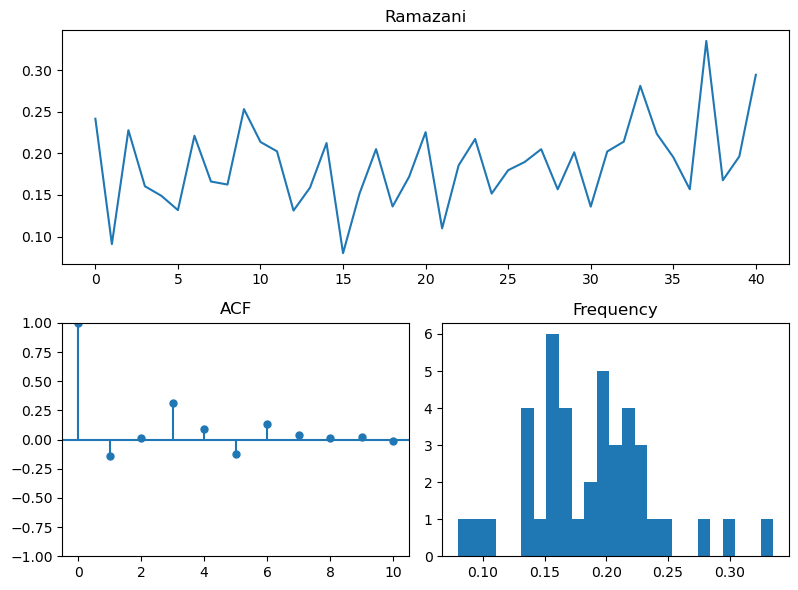

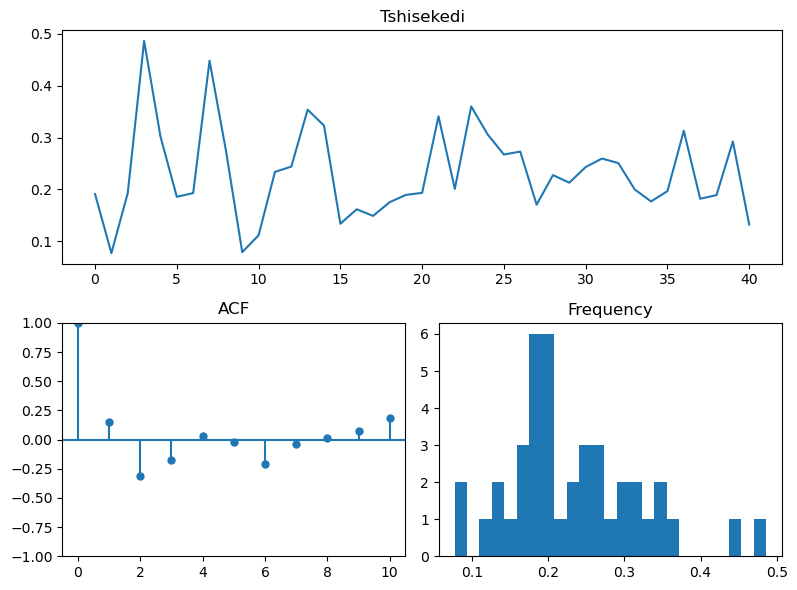

In [31]:
# visual inspection

warnings.filterwarnings('ignore')
[tsdisplay(globals()[f'b_wg_bert_{leader.lower()}'], lag_max=10, title=f'{leader}') for leader in leaders];

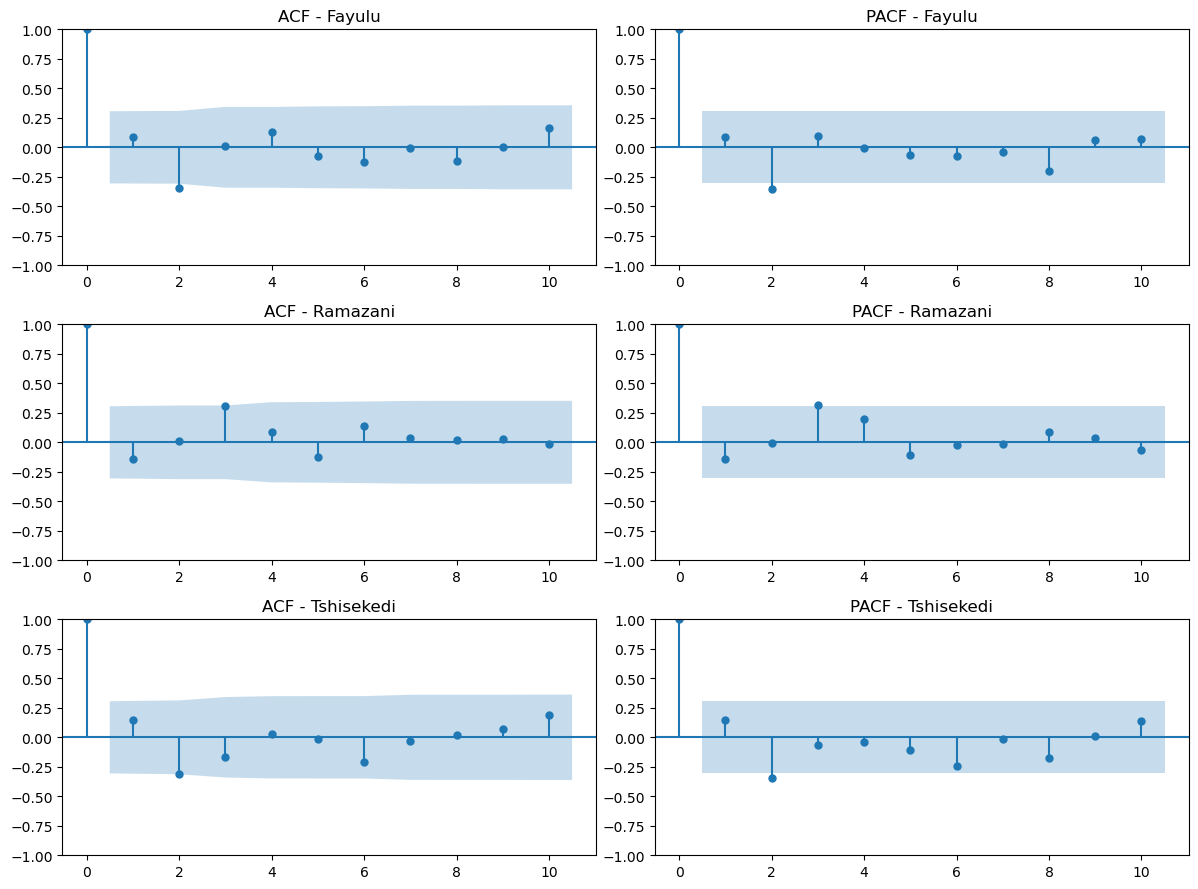

In [32]:
# Correlograms

plot_correlograms('b_wg_bert_', lags=10)

In [33]:
# unit root test

adf_b_tssw_vader = calculate_adf_stats('b_wg_bert_')
adf_b_tssw_vader

,fayulu,ramazani,tshisekedi
ADF (c),-5.634867,-2.164253e+00,-5.197659
p-value (c),0.000001,2.194745e-01,0.000009
ADF (ct),-5.657993,-8.089373e+00,-5.146192
p-value (ct),0.000011,4.440140e-11,0.000111
ADF (ctt),-5.598309,-6.324254e+00,-5.086028
p-value (ctt),0.000082,2.632055e-06,0.000728


In [34]:
# model selection / parameters fitting

models_b_wg_bert, summary_b_wg_bert = estimate_arima_models('b_wg_bert_')

for leader in leaders:
    print("=" * 50)
    print(f"Fitted model for {leader}")
    print("=" * 50)
    display(models_b_wg_bert[leader.lower()].summary())

ARIMA Models for: b_wg_bert_

Summary Table:
    Leader               Series     Order         AIC         BIC
    Fayulu     b_wg_bert_fayulu (2, 0, 0)  -78.692104  -71.837815
  Ramazani   b_wg_bert_ramazani (0, 1, 2) -119.882862 -114.816224
Tshisekedi b_wg_bert_tshisekedi (1, 0, 2)  -84.698916  -76.131055
Fitted model for Fayulu


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(2, 0, 0)   Log Likelihood                  43.346
Date:                Tue, 18 Nov 2025   AIC                            -78.692
Time:                        17:50:32   BIC                            -71.838
Sample:                    11-20-2018   HQIC                           -76.196
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.7467      0.124      6.044      0.000       0.505       0.989
ar.L1          0.1304      0.217      0.602      0.547      -0.294       0.555
ar.L2         -0.4193      0.133     -3.161      0.002      -0.679      -0.159
sigma2         0.0070      0.001      4.720      0.000       0.004       0.010
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 1.32
Prob(Q):                              0.79   Prob(JB):                         0.52
Heteroskedasticity (H):               0.33   Skew:                             0.37
Prob(H) (two-sided):                  0.05   Kurtosis:                         3.47
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Ramazani


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(0, 1, 2)   Log Likelihood                  62.941
Date:                Tue, 18 Nov 2025   AIC                           -119.883
Time:                        17:50:32   BIC                           -114.816
Sample:                    11-20-2018   HQIC                          -118.051
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.1672      0.164     -7.116      0.000      -1.489      -0.846
ma.L2          0.3418      0.136      2.513      0.012       0.075       0.608
sigma2         0.0024      0.001      4.003      0.000       0.001       0.004
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.13
Prob(Q):                              0.98   Prob(JB):                         0.94
Heteroskedasticity (H):               1.28   Skew:                             0.05
Prob(H) (two-sided):                  0.66   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Tshisekedi


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(1, 0, 2)   Log Likelihood                  47.349
Date:                Tue, 18 Nov 2025   AIC                            -84.699
Time:                        17:50:32   BIC                            -76.131
Sample:                    11-20-2018   HQIC                           -81.579
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1234      0.065      1.894      0.058      -0.004       0.251
ar.L1          0.4722      0.281      1.683      0.092      -0.078       1.022
ma.L1         -0.4382      0.400     -1.096      0.273      -1.222       0.346
ma.L2         -0.5128      0.310     -1.654      0.098      -1.120       0.095
sigma2         0.0056      0.002      3.191      0.001       0.002       0.009
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 6.36
Prob(Q):                              0.98   Prob(JB):                         0.04
Heteroskedasticity (H):               0.27   Skew:                             0.81
Prob(H) (two-sided):                  0.02   Kurtosis:                         4.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Diagnostics of the Fayulu series


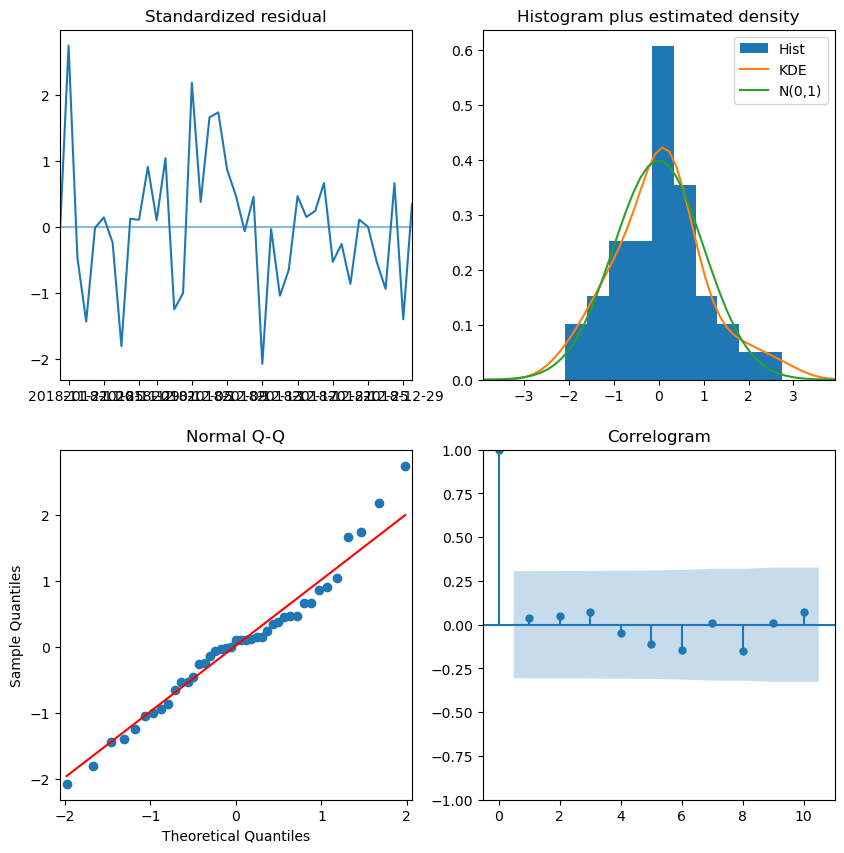

Diagnostics of the Ramazani series


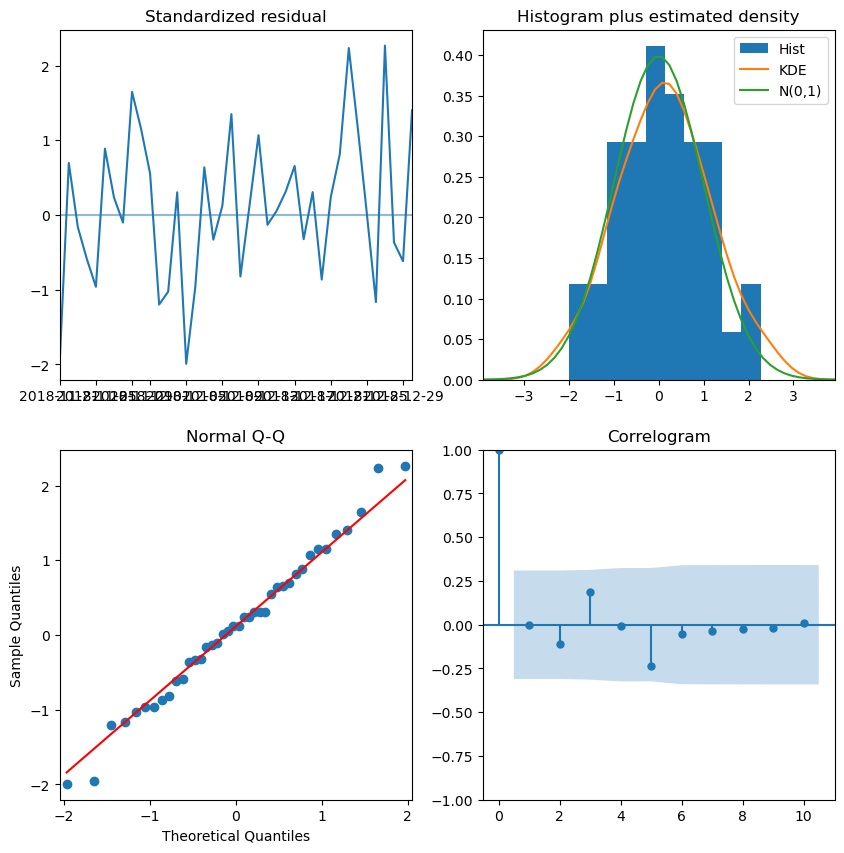

Diagnostics of the Tshisekedi series


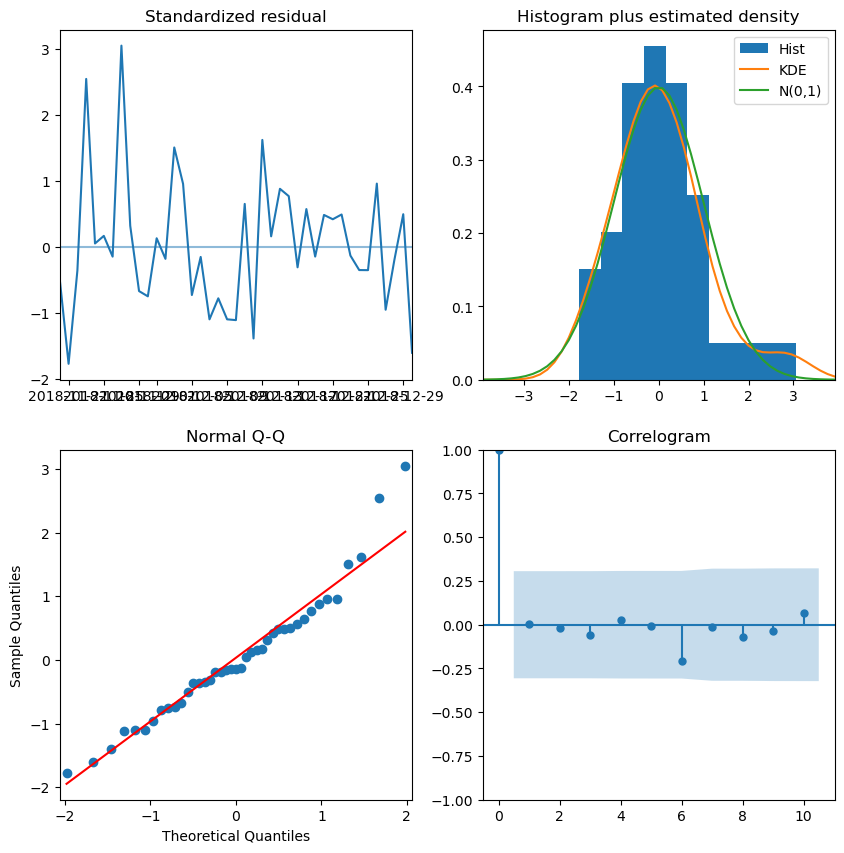

In [35]:
# residual diagnostics / model validation

for leader in leaders:
    print("=" * 50)
    print(f"Diagnostics of the {leader} series")
    print("=" * 50)
    models_b_wg_bert[leader.lower()].plot_diagnostics(figsize=(10,10))
    plt.show();

In [36]:
# forecasting (ARIMA vs ARIMA-X)

b_wg_bert_predictions = make_predictions(models_b_wg_bert)
print('='*50)
print('One-point-ahead forecast for WG index (BERT)')
print('='*50)
b_wg_bert_predictions

One-point-ahead forecast for WG index (BERT)


,Leader,Forecast,Lower_Bound,Upper_Bound
0,fayulu,0.589260,0.469427,0.744629
1,ramazani,0.197868,0.123027,0.284641
2,tshisekedi,0.212872,0.096226,0.342355


#### YHRM

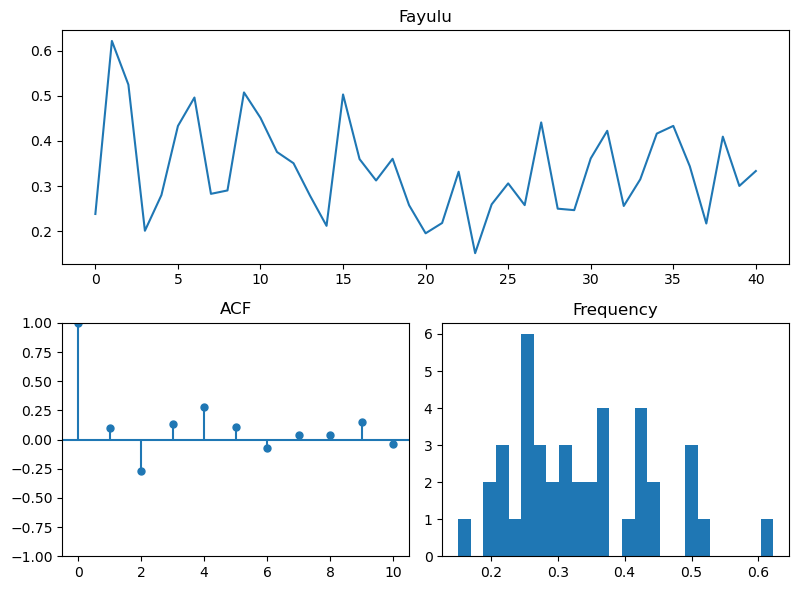

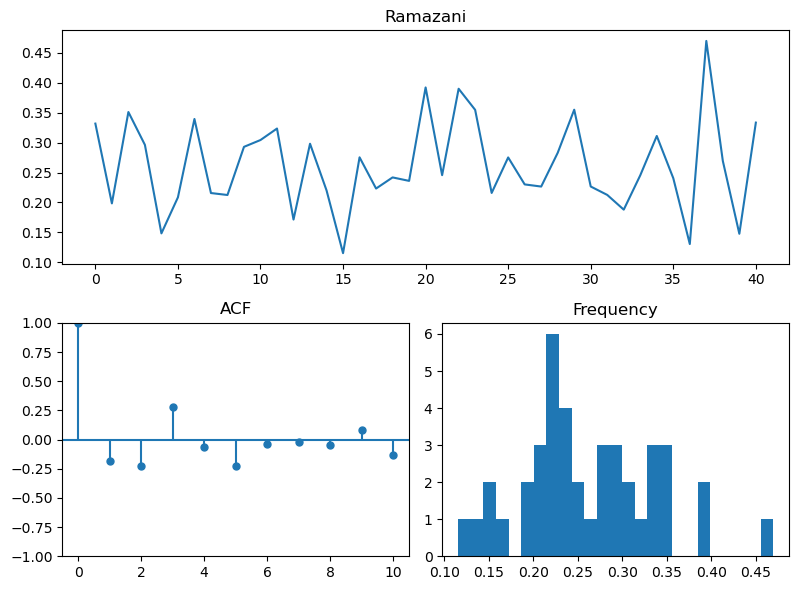

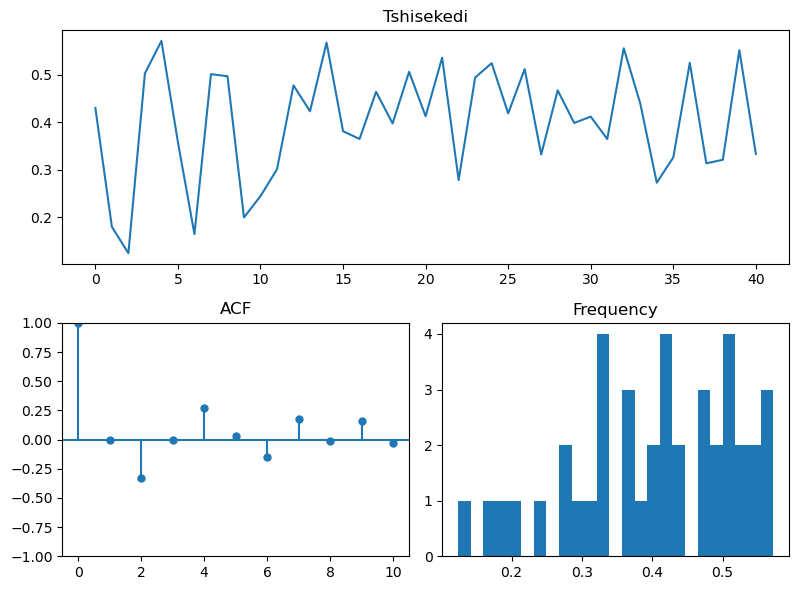

In [37]:
# visual inspection

warnings.filterwarnings('ignore')
[tsdisplay(globals()[f'b_yhrm_bert_{leader.lower()}'], lag_max=10, title=f'{leader}') for leader in leaders];

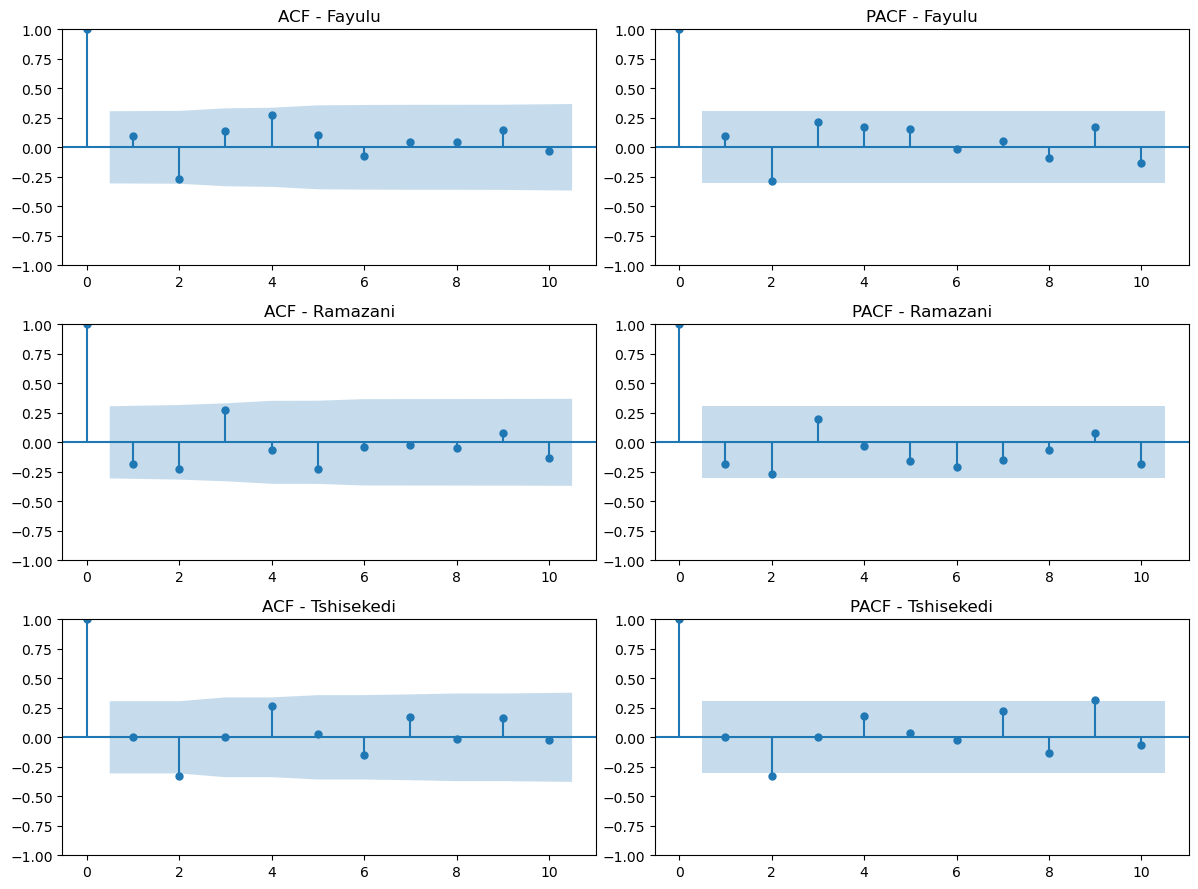

In [38]:
# Correlograms

plot_correlograms('b_yhrm_bert_', lags=10)

In [39]:
# unit root test

adf_b_tssw_vader = calculate_adf_stats('b_yhrm_bert_')
adf_b_tssw_vader

,fayulu,ramazani,tshisekedi
ADF (c),-5.661408e+00,-7.444248e+00,-6.141100e+00
p-value (c),9.361506e-07,5.895317e-11,7.967675e-08
ADF (ct),-5.955841e+00,-7.350421e+00,-6.290529e+00
p-value (ct),2.718854e-06,2.247747e-09,5.278071e-07
ADF (ctt),-6.726908e+00,-7.257602e+00,-4.304627e+00
p-value (ctt),3.385503e-07,2.017186e-08,1.248055e-02


In [40]:
# model selection / parameters fitting

models_b_yhrm_bert, summary_b_yhrm_bert = estimate_arima_models('b_yhrm_bert_')

for leader in leaders:
    print("=" * 50)
    print(f"Fitted model for {leader}")
    print("=" * 50)
    display(models_b_yhrm_bert[leader.lower()].summary())

ARIMA Models for: b_yhrm_bert_

Summary Table:
    Leader                 Series     Order        AIC        BIC
    Fayulu     b_yhrm_bert_fayulu (3, 0, 1) -66.124904 -55.843472
  Ramazani   b_yhrm_bert_ramazani (4, 0, 1) -92.328476 -80.333472
Tshisekedi b_yhrm_bert_tshisekedi (2, 0, 0) -57.331548 -50.477260
Fitted model for Fayulu


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(3, 0, 1)   Log Likelihood                  39.062
Date:                Tue, 18 Nov 2025   AIC                            -66.125
Time:                        17:50:39   BIC                            -55.843
Sample:                    11-20-2018   HQIC                           -62.381
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0811      0.112      0.722      0.471      -0.139       0.301
ar.L1          0.7522      0.379      1.987      0.047       0.010       1.494
ar.L2         -0.4707      0.246     -1.917      0.055      -0.952       0.011
ar.L3          0.4807      0.173      2.784      0.005       0.142       0.819
ma.L1         -0.5793      0.374     -1.549      0.121      -1.312       0.154
sigma2         0.0086      0.002      3.721      0.000       0.004       0.013
===================================================================================
Ljung-Box (L1) (Q):                   0.11   Jarque-Bera (JB):                 0.69
Prob(Q):                              0.74   Prob(JB):                         0.71
Heteroskedasticity (H):               0.65   Skew:                             0.32
Prob(H) (two-sided):                  0.43   Kurtosis:                         3.01
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Ramazani


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(4, 0, 1)   Log Likelihood                  53.164
Date:                Tue, 18 Nov 2025   AIC                            -92.328
Time:                        17:50:39   BIC                            -80.333
Sample:                    11-20-2018   HQIC                           -87.961
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1190      0.072      1.655      0.098      -0.022       0.260
ar.L1          0.7404      0.205      3.612      0.000       0.339       1.142
ar.L2         -0.1728      0.255     -0.678      0.497      -0.672       0.326
ar.L3          0.4425      0.252      1.755      0.079      -0.052       0.937
ar.L4         -0.4652      0.212     -2.199      0.028      -0.880      -0.051
ma.L1         -0.9195      0.211     -4.359      0.000      -1.333      -0.506
sigma2         0.0042      0.001      3.415      0.001       0.002       0.007
===================================================================================
Ljung-Box (L1) (Q):                   0.85   Jarque-Bera (JB):                 0.60
Prob(Q):                              0.36   Prob(JB):                         0.74
Heteroskedasticity (H):               1.71   Skew:                             0.24
Prob(H) (two-sided):                  0.33   Kurtosis:                         2.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Tshisekedi


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(2, 0, 0)   Log Likelihood                  32.666
Date:                Tue, 18 Nov 2025   AIC                            -57.332
Time:                        17:50:39   BIC                            -50.477
Sample:                    11-20-2018   HQIC                           -54.836
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.5443      0.097      5.614      0.000       0.354       0.734
ar.L1          0.0114      0.165      0.069      0.945      -0.312       0.334
ar.L2         -0.3653      0.175     -2.090      0.037      -0.708      -0.023
sigma2         0.0118      0.003      3.537      0.000       0.005       0.018
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.08
Prob(Q):                              0.98   Prob(JB):                         0.58
Heteroskedasticity (H):               0.43   Skew:                            -0.34
Prob(H) (two-sided):                  0.12   Kurtosis:                         2.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Diagnostics of the Fayulu series


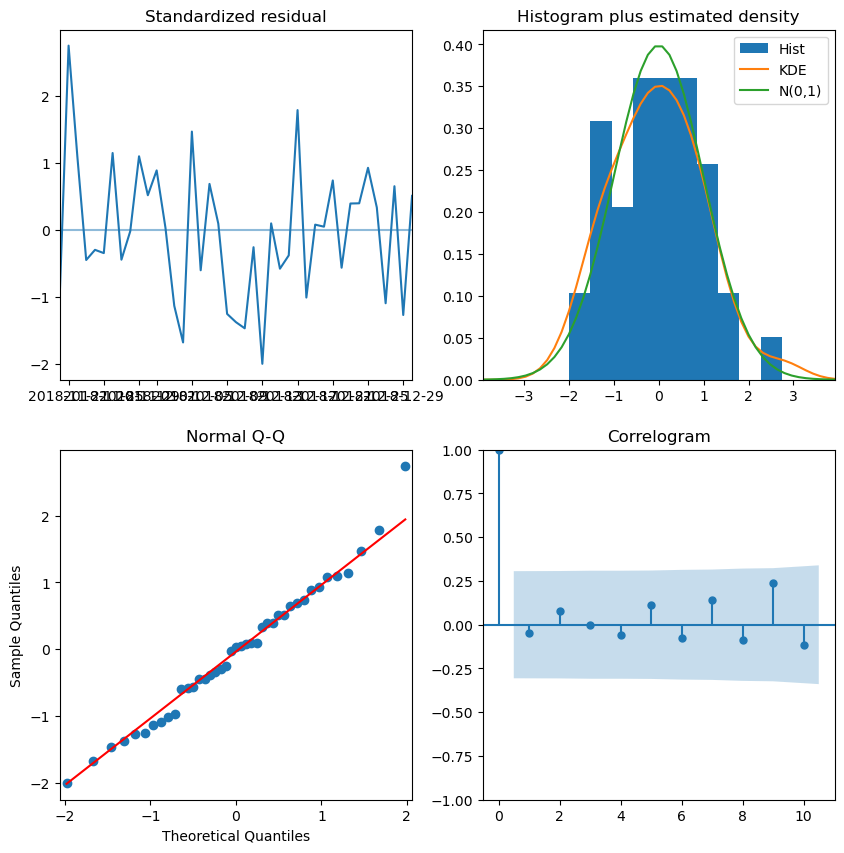

Diagnostics of the Ramazani series


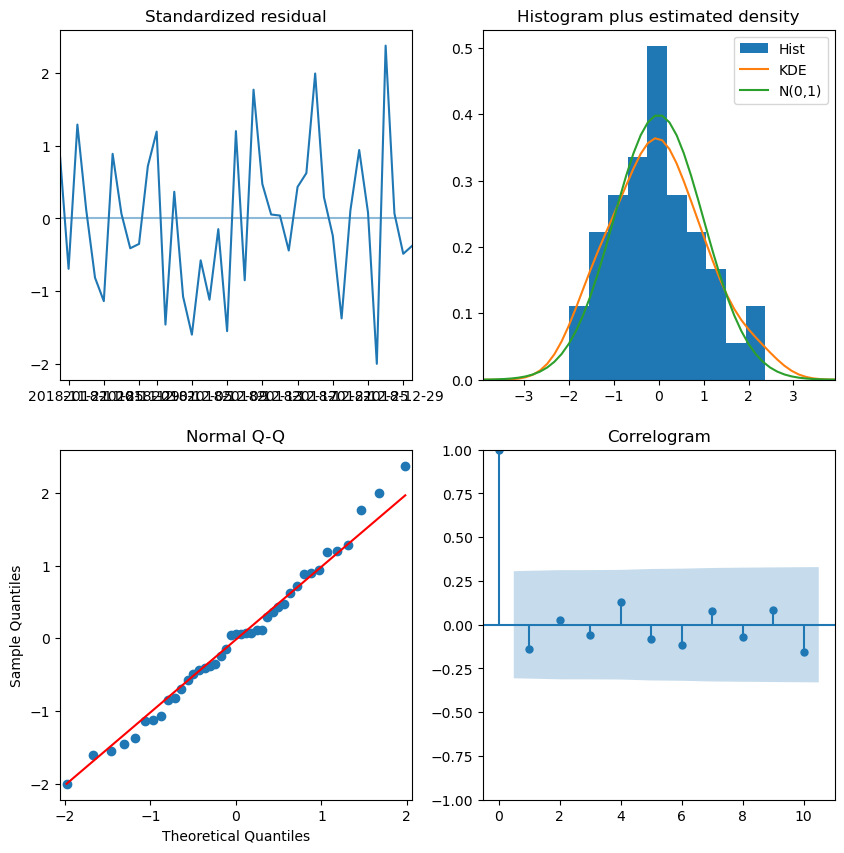

Diagnostics of the Tshisekedi series


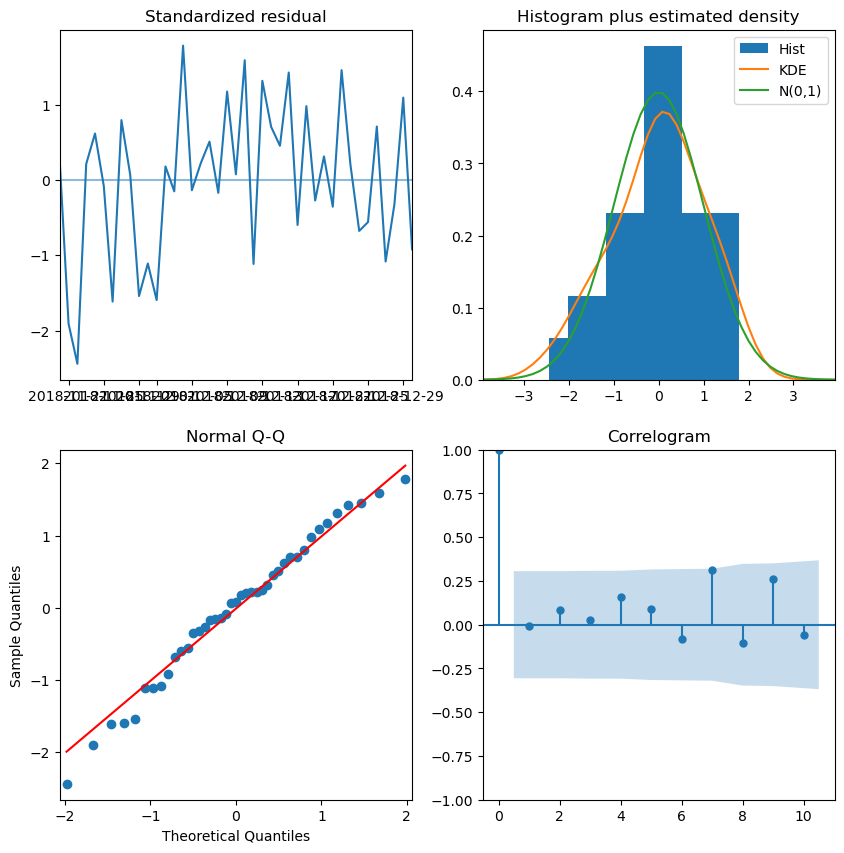

In [41]:
# residual diagnostics / model validation

for leader in leaders:
    print("=" * 50)
    print(f"Diagnostics of the {leader} series")
    print("=" * 50)
    models_b_yhrm_bert[leader.lower()].plot_diagnostics(figsize=(10,10))
    plt.show();

In [42]:
# forecasting (ARIMA vs ARIMA-X)

b_yhrm_bert_predictions = make_predictions(models_b_yhrm_bert)
print('='*50)
print('One-point-ahead forecast for YHRM index (BERT)')
print('='*50)
b_yhrm_bert_predictions

One-point-ahead forecast for YHRM index (BERT)


,Leader,Forecast,Lower_Bound,Upper_Bound
0,fayulu,0.371352,0.207938,0.512512
1,ramazani,0.271532,0.157162,0.369630
2,tshisekedi,0.357116,0.167627,0.525203


## Penalized predictions

### VADER results

#### P-TSSW

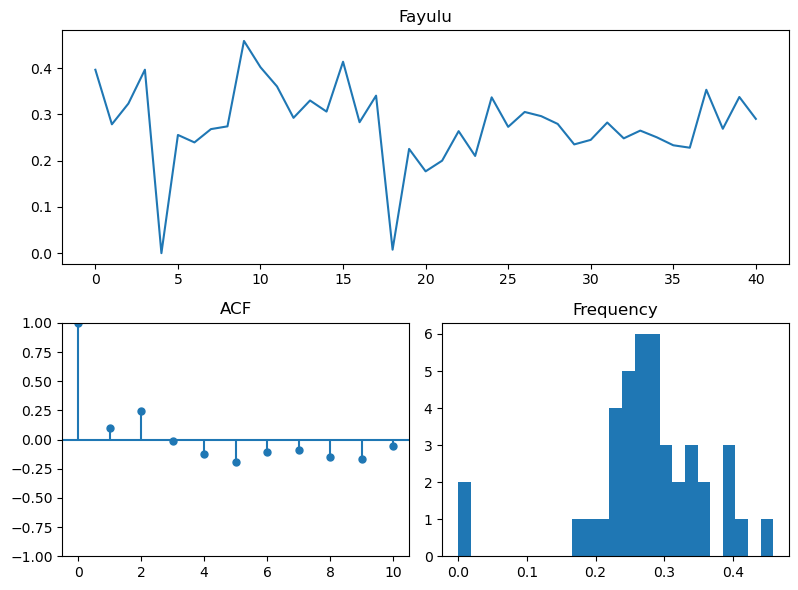

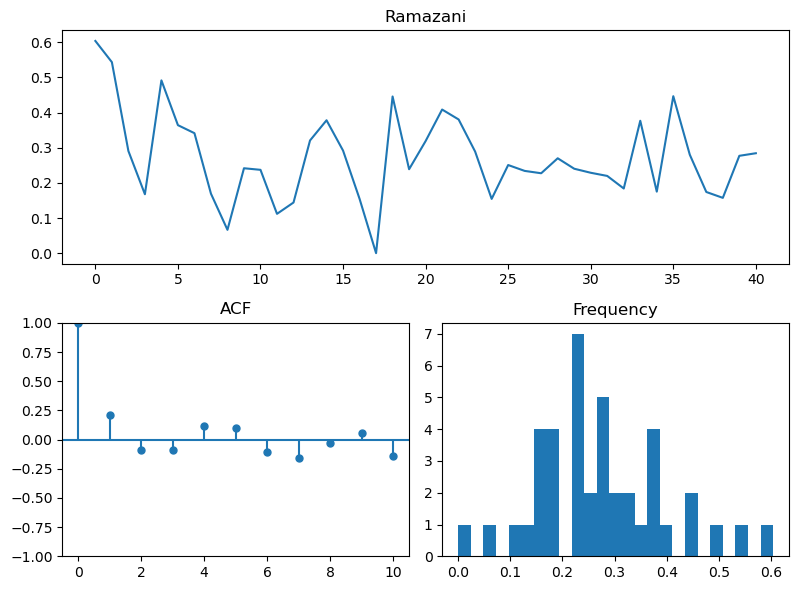

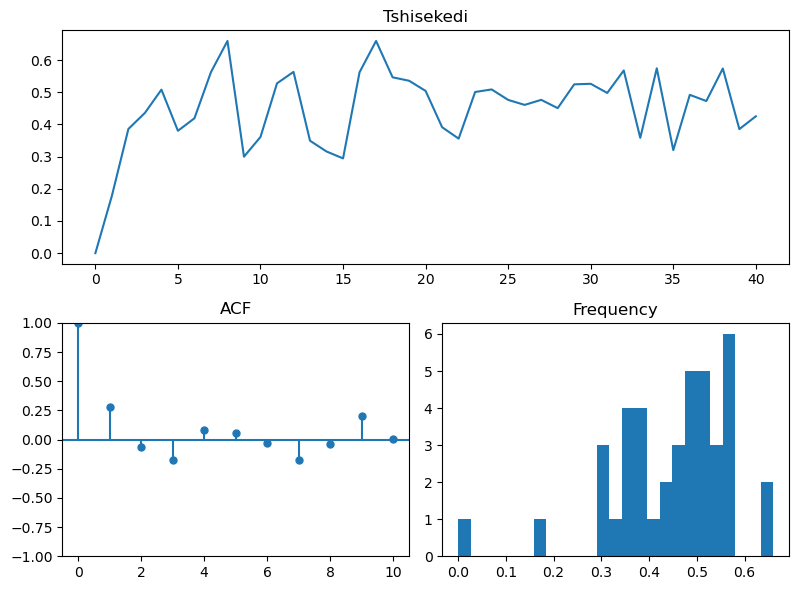

In [43]:
# visual inspection

warnings.filterwarnings('ignore')
[tsdisplay(globals()[f'p_tssw_vader_{leader.lower()}'], lag_max=10, title=f'{leader}') for leader in leaders];

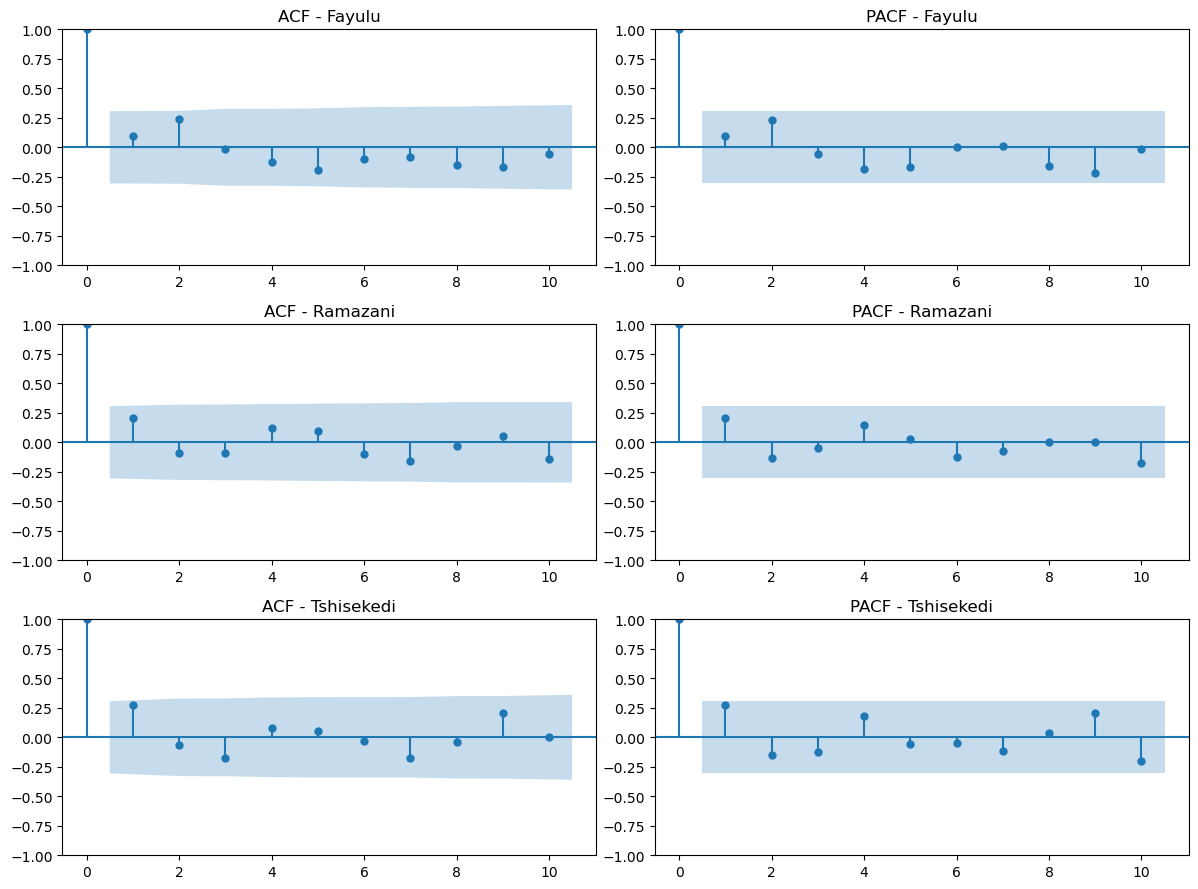

In [44]:
# Correlograms

plot_correlograms('p_tssw_vader_', lags=10)

In [45]:
# unit root test

adf_b_tssw_vader = calculate_adf_stats('p_tssw_vader_')
adf_b_tssw_vader

,fayulu,ramazani,tshisekedi
ADF (c),-3.186593,-5.537992,-5.240047
p-value (c),0.020774,0.000002,0.000007
ADF (ct),-3.122269,-5.430838,-5.216000
p-value (ct),0.101032,0.000032,0.000082
ADF (ctt),-4.847813,-5.387905,-5.334341
p-value (ctt),0.001851,0.000207,0.000260


In [46]:
# model selection / parameters fitting

models_p_tssw_vader, summary_p_tssw_vader = estimate_arima_models('p_tssw_vader_')

for leader in leaders:
    print("=" * 50)
    print(f"Fitted model for {leader}")
    print("=" * 50)
    display(models_p_tssw_vader[leader.lower()].summary())

ARIMA Models for: p_tssw_vader_

Summary Table:
    Leader                  Series     Order        AIC        BIC
    Fayulu     p_tssw_vader_fayulu (2, 0, 0) -78.608765 -71.754477
  Ramazani   p_tssw_vader_ramazani (0, 0, 1) -51.694472 -46.553755
Tshisekedi p_tssw_vader_tshisekedi (1, 0, 0) -53.307683 -48.166967
Fitted model for Fayulu


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(2, 0, 0)   Log Likelihood                  43.304
Date:                Tue, 18 Nov 2025   AIC                            -78.609
Time:                        17:50:45   BIC                            -71.754
Sample:                    11-20-2018   HQIC                           -76.113
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1929      0.114      1.694      0.090      -0.030       0.416
ar.L1          0.0754      0.236      0.320      0.749      -0.387       0.538
ar.L2          0.2367      0.364      0.651      0.515      -0.476       0.949
sigma2         0.0071      0.001      5.511      0.000       0.005       0.010
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                52.15
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               0.11   Skew:                            -1.45
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Ramazani


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(0, 0, 1)   Log Likelihood                  28.847
Date:                Tue, 18 Nov 2025   AIC                            -51.694
Time:                        17:50:45   BIC                            -46.554
Sample:                    11-20-2018   HQIC                           -49.823
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2744      0.027     10.317      0.000       0.222       0.327
ma.L1          0.2624      0.141      1.859      0.063      -0.014       0.539
sigma2         0.0143      0.003      4.113      0.000       0.007       0.021
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 3.20
Prob(Q):                              0.85   Prob(JB):                         0.20
Heteroskedasticity (H):               0.36   Skew:                             0.67
Prob(H) (two-sided):                  0.07   Kurtosis:                         3.23
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Tshisekedi


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(1, 0, 0)   Log Likelihood                  29.654
Date:                Tue, 18 Nov 2025   AIC                            -53.308
Time:                        17:50:45   BIC                            -48.167
Sample:                    11-20-2018   HQIC                           -51.436
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2664      0.061      4.366      0.000       0.147       0.386
ar.L1          0.3964      0.131      3.017      0.003       0.139       0.654
sigma2         0.0137      0.003      4.448      0.000       0.008       0.020
===================================================================================
Ljung-Box (L1) (Q):                   0.18   Jarque-Bera (JB):                14.30
Prob(Q):                              0.67   Prob(JB):                         0.00
Heteroskedasticity (H):               0.41   Skew:                            -1.09
Prob(H) (two-sided):                  0.10   Kurtosis:                         4.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Diagnostics of the Fayulu series


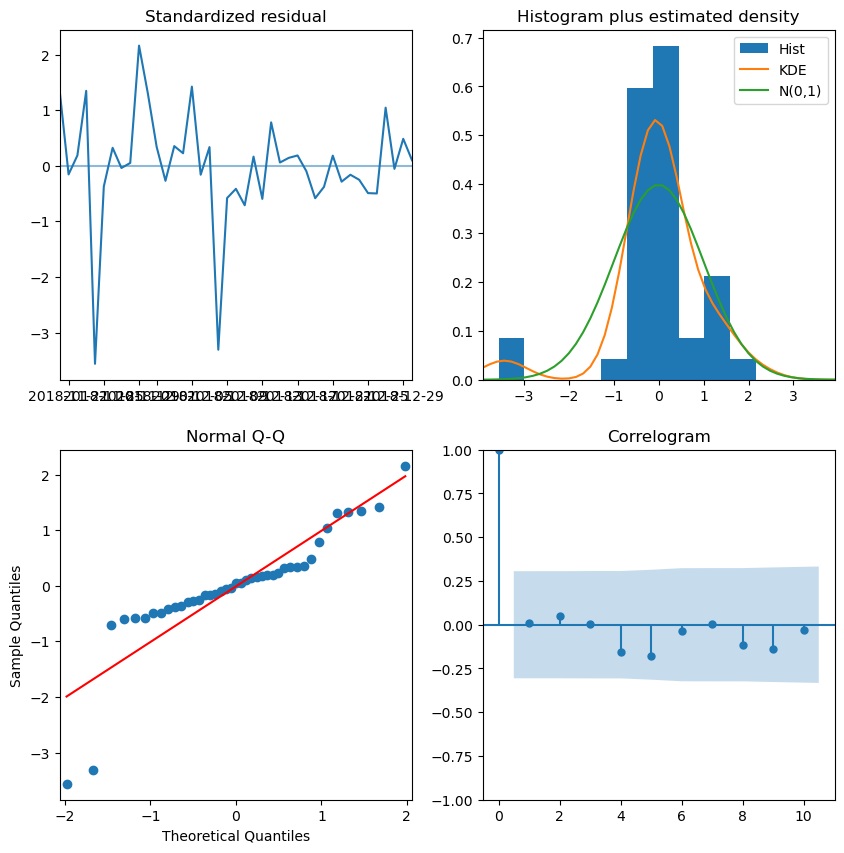

Diagnostics of the Ramazani series


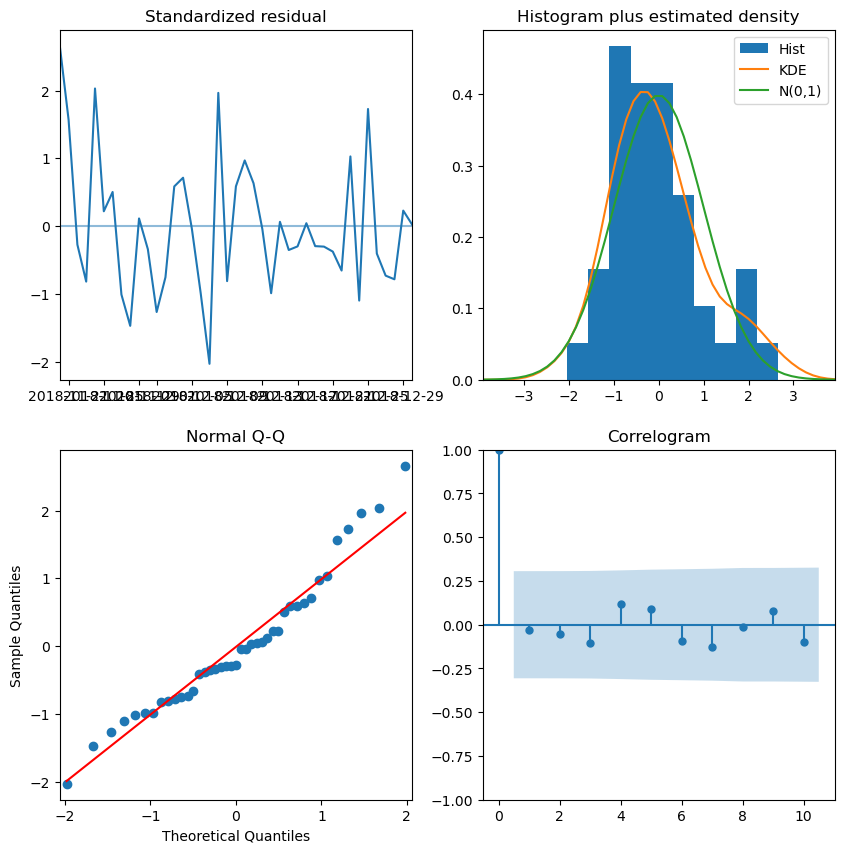

Diagnostics of the Tshisekedi series


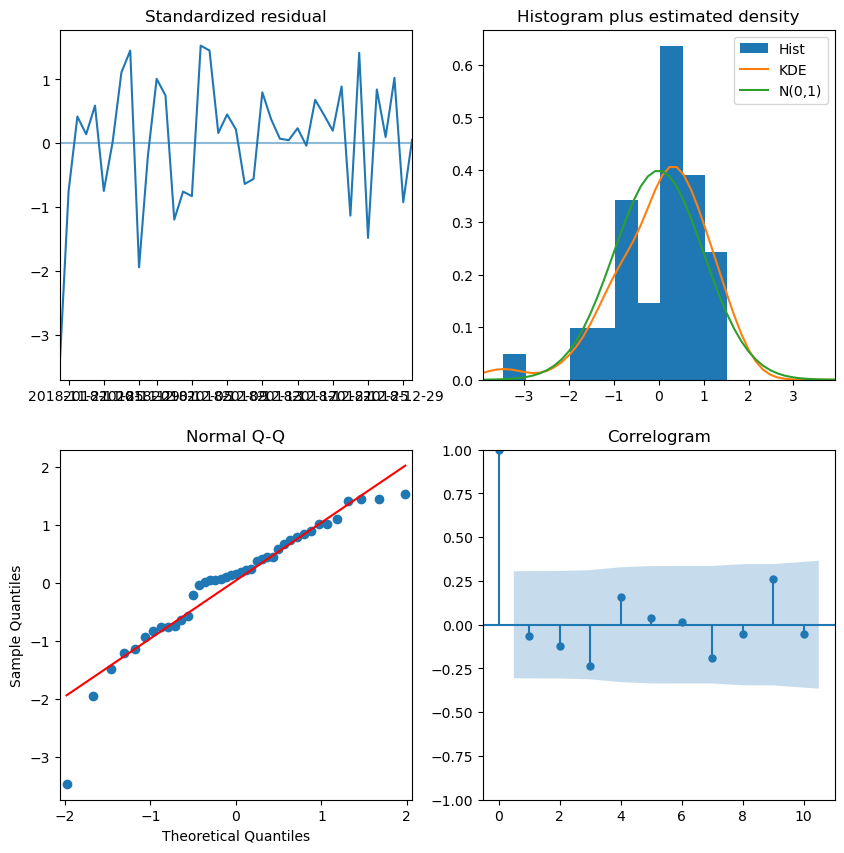

In [47]:
# residual diagnostics / model validation

for leader in leaders:
    print("=" * 50)
    print(f"Diagnostics of the {leader} series")
    print("=" * 50)
    models_p_tssw_vader[leader.lower()].plot_diagnostics(figsize=(10,10))
    plt.show();

In [48]:
# forecasting (ARIMA vs ARIMA-X)

p_tssw_vader_predictions = make_predictions(models_p_tssw_vader)
print('='*50)
print('One-point-ahead forecast for P-TSSW index (VADER)')
print('='*50)
p_tssw_vader_predictions

One-point-ahead forecast for P-TSSW index (VADER)


,Leader,Forecast,Lower_Bound,Upper_Bound
0,fayulu,0.293225,0.156457,0.432851
1,ramazani,0.273781,0.078358,0.471873
2,tshisekedi,0.432994,0.242418,0.627791


#### P-WG

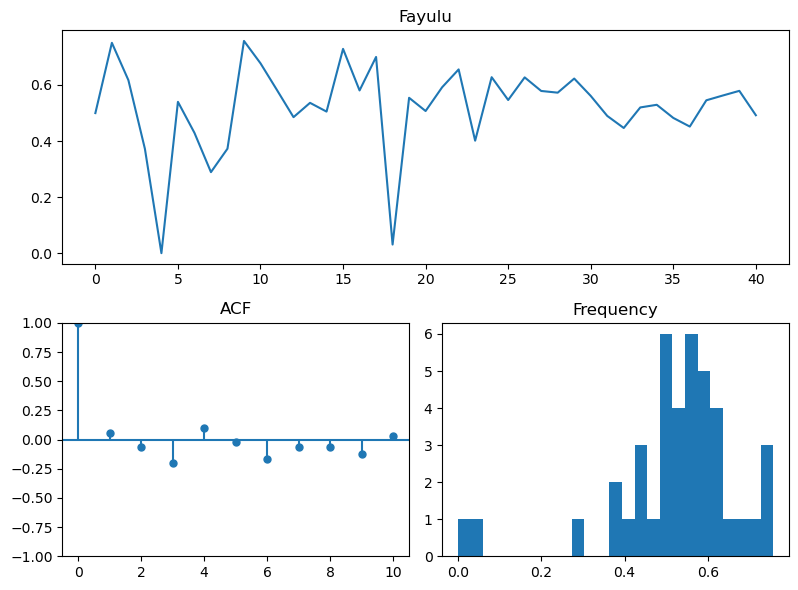

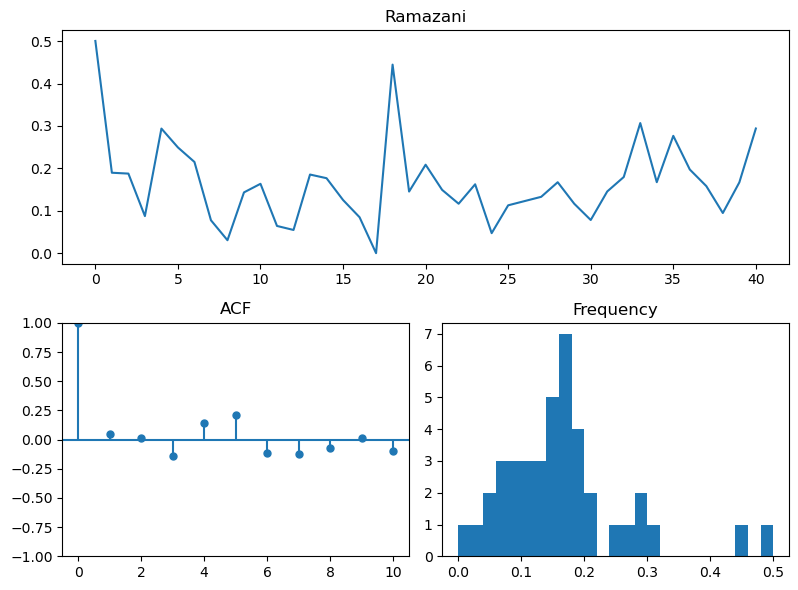

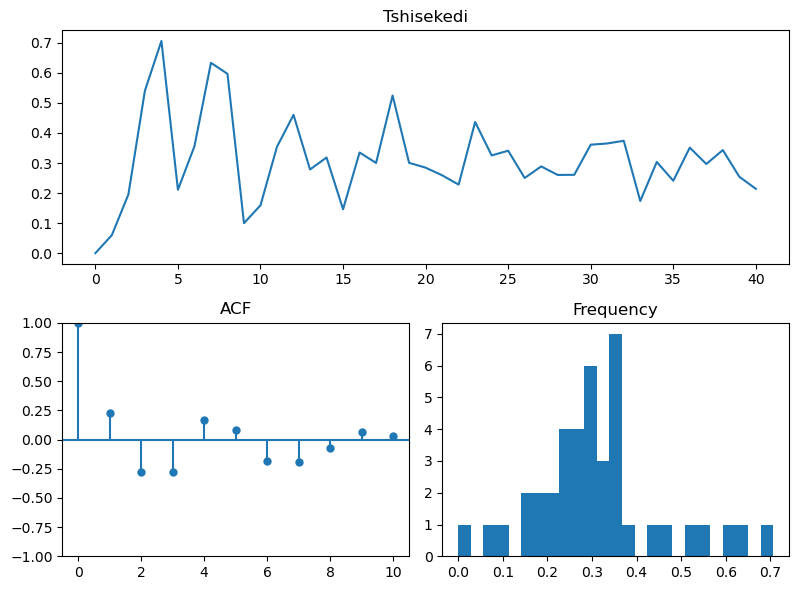

In [49]:
# visual inspection

warnings.filterwarnings('ignore')
[tsdisplay(globals()[f'p_wg_vader_{leader.lower()}'], lag_max=10, title=f'{leader}') for leader in leaders];

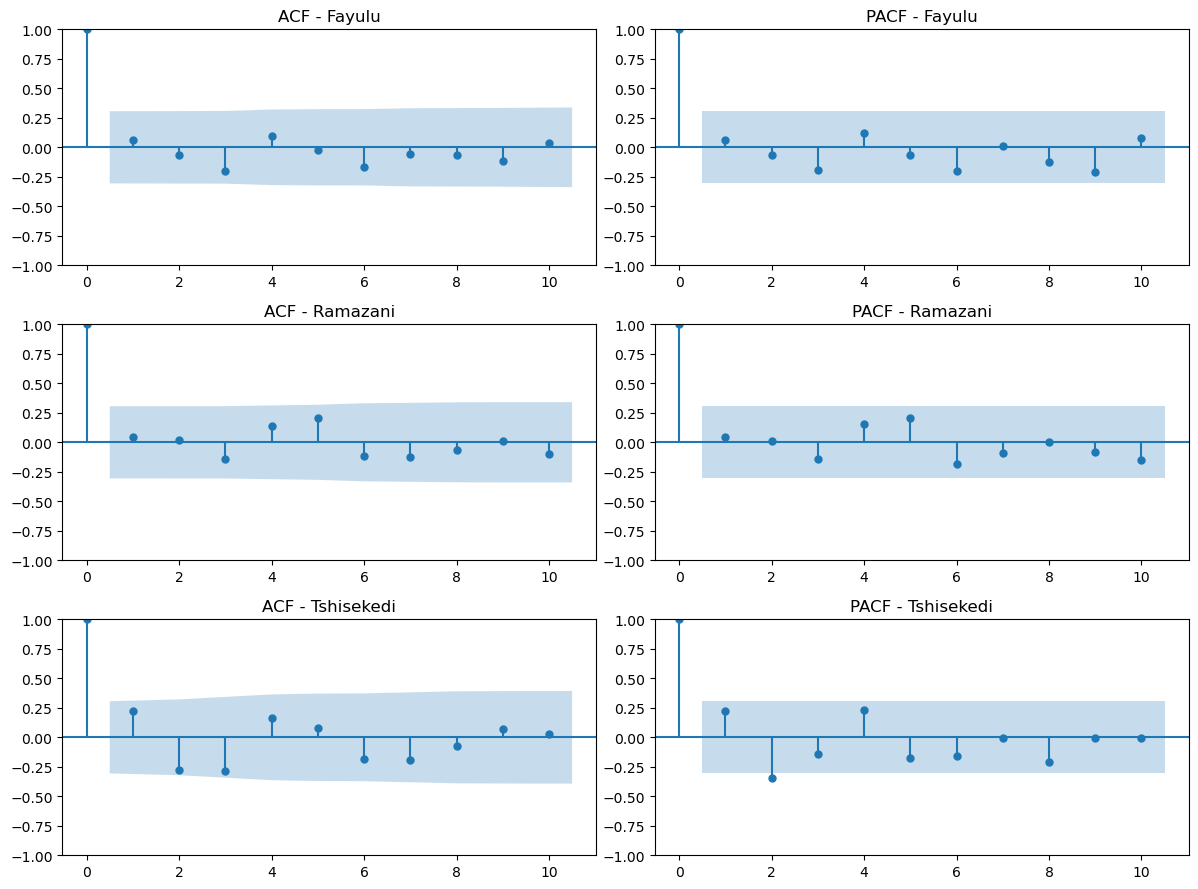

In [50]:
# Correlograms

plot_correlograms('p_wg_vader_', lags=10)

In [51]:
# unit root test

adf_b_tssw_vader = calculate_adf_stats('p_wg_vader_')
adf_b_tssw_vader

,fayulu,ramazani,tshisekedi
ADF (c),-5.812989e+00,-6.838314e+00,-2.296417
p-value (c),4.357426e-07,1.818365e-09,0.173126
ADF (ct),-4.680401e+00,-6.666154e+00,-4.532446
p-value (ct),7.539546e-04,7.924836e-08,0.001335
ADF (ctt),-4.070776e+00,-6.905448e+00,-4.259524
p-value (ctt),2.565633e-02,1.328307e-07,0.014412


In [52]:
# model selection / parameters fitting

models_p_wg_vader, summary_p_wg_vader = estimate_arima_models('p_wg_vader_')

for leader in leaders:
    print("=" * 50)
    print(f"Fitted model for {leader}")
    print("=" * 50)
    display(models_p_wg_vader[leader.lower()].summary())

ARIMA Models for: p_wg_vader_

Summary Table:
    Leader                Series     Order        AIC        BIC
    Fayulu     p_wg_vader_fayulu (0, 0, 0) -34.269654 -30.842510
  Ramazani   p_wg_vader_ramazani (5, 0, 0) -64.885754 -52.890749
Tshisekedi p_wg_vader_tshisekedi (2, 0, 0) -43.290249 -36.435961
Fitted model for Fayulu


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:                        SARIMAX   Log Likelihood                  19.135
Date:                Tue, 18 Nov 2025   AIC                            -34.270
Time:                        17:50:50   BIC                            -30.843
Sample:                    11-20-2018   HQIC                           -33.022
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.5217      0.032     16.228      0.000       0.459       0.585
sigma2         0.0230      0.004      5.654      0.000       0.015       0.031
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                41.83
Prob(Q):                              0.70   Prob(JB):                         0.00
Heteroskedasticity (H):               0.07   Skew:                            -1.62
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Ramazani


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(5, 0, 0)   Log Likelihood                  39.443
Date:                Tue, 18 Nov 2025   AIC                            -64.886
Time:                        17:50:50   BIC                            -52.891
Sample:                    11-20-2018   HQIC                           -60.518
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1024      0.068      1.512      0.131      -0.030       0.235
ar.L1          0.0782      0.200      0.390      0.696      -0.315       0.471
ar.L2          0.0680      0.298      0.228      0.820      -0.517       0.653
ar.L3         -0.2061      0.216     -0.954      0.340      -0.629       0.217
ar.L4          0.1802      0.202      0.892      0.373      -0.216       0.576
ar.L5          0.2881      0.218      1.323      0.186      -0.139       0.715
sigma2         0.0084      0.002      3.845      0.000       0.004       0.013
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                28.29
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               0.43   Skew:                             1.49
Prob(H) (two-sided):                  0.13   Kurtosis:                         5.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Tshisekedi


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(2, 0, 0)   Log Likelihood                  25.645
Date:                Tue, 18 Nov 2025   AIC                            -43.290
Time:                        17:50:50   BIC                            -36.436
Sample:                    11-20-2018   HQIC                           -40.794
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3379      0.058      5.786      0.000       0.223       0.452
ar.L1          0.3065      0.135      2.273      0.023       0.042       0.571
ar.L2         -0.3782      0.124     -3.040      0.002      -0.622      -0.134
sigma2         0.0166      0.005      3.687      0.000       0.008       0.025
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                 0.84
Prob(Q):                              0.70   Prob(JB):                         0.66
Heteroskedasticity (H):               0.15   Skew:                             0.31
Prob(H) (two-sided):                  0.00   Kurtosis:                         2.68
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Diagnostics of the Fayulu series


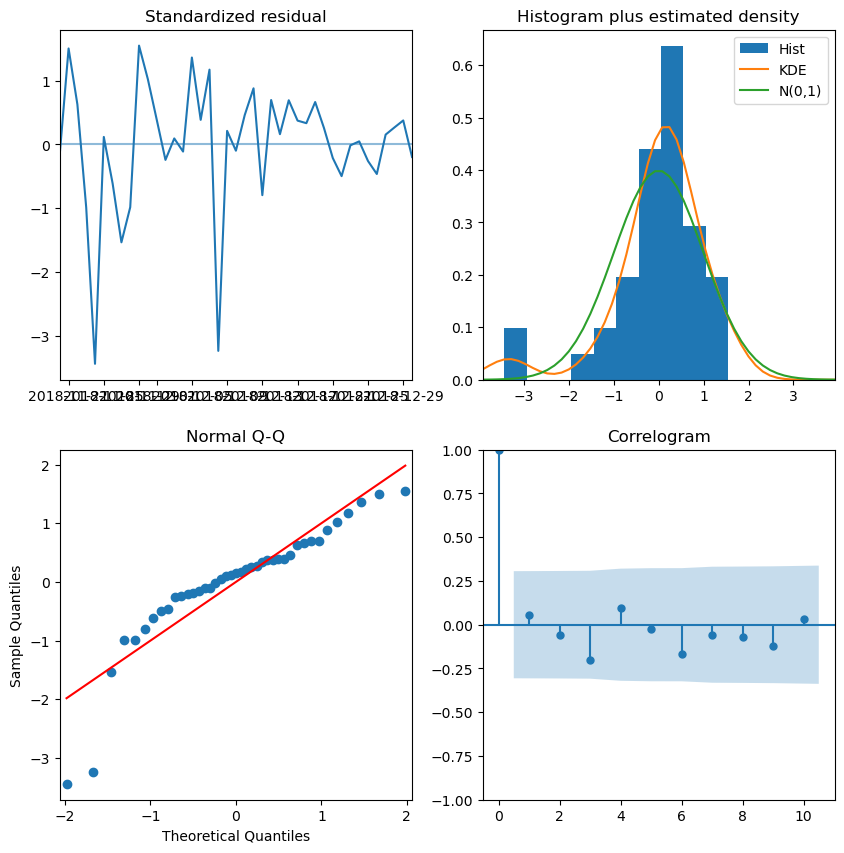

Diagnostics of the Ramazani series


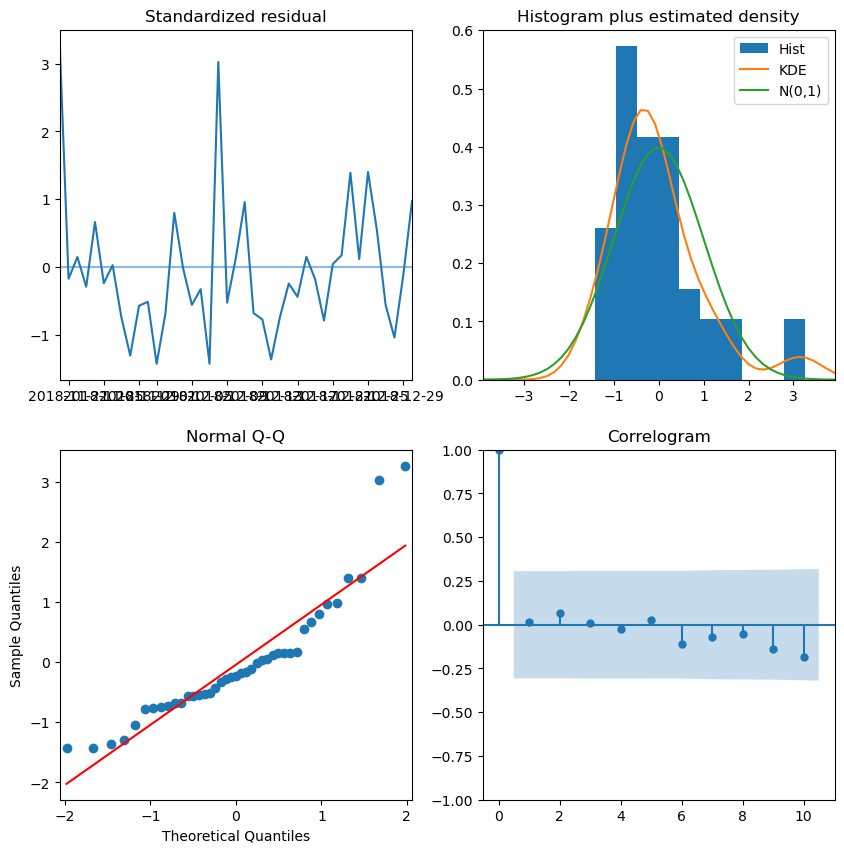

Diagnostics of the Tshisekedi series


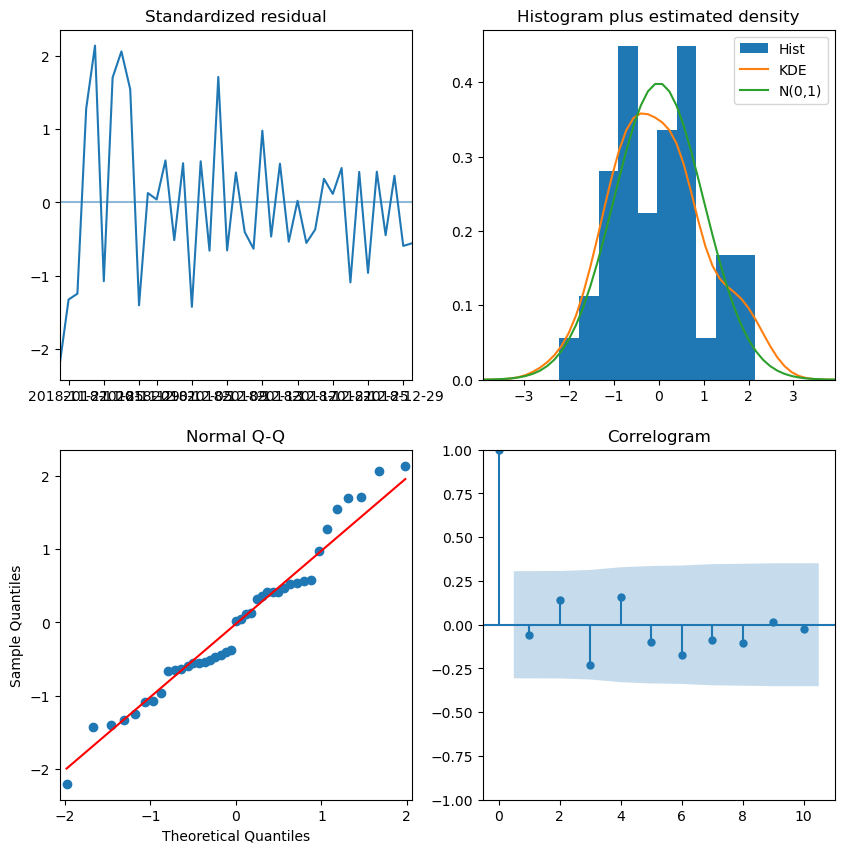

In [53]:
# residual diagnostics / model validation

for leader in leaders:
    print("=" * 50)
    print(f"Diagnostics of the {leader} series")
    print("=" * 50)
    models_p_wg_vader[leader.lower()].plot_diagnostics(figsize=(10,10))
    plt.show();

In [54]:
# forecasting (ARIMA vs ARIMA-X)

p_wg_vader_predictions = make_predictions(models_p_wg_vader)
print('='*50)
print('One-point-ahead forecast for P-WG index (VADER)')
print('='*50)
p_wg_vader_predictions

One-point-ahead forecast for P-WG index (VADER)


,Leader,Forecast,Lower_Bound,Upper_Bound
0,fayulu,0.505700,0.272156,0.771309
1,ramazani,0.196355,0.051875,0.353285
2,tshisekedi,0.297945,0.095387,0.519394


#### P-YHRM

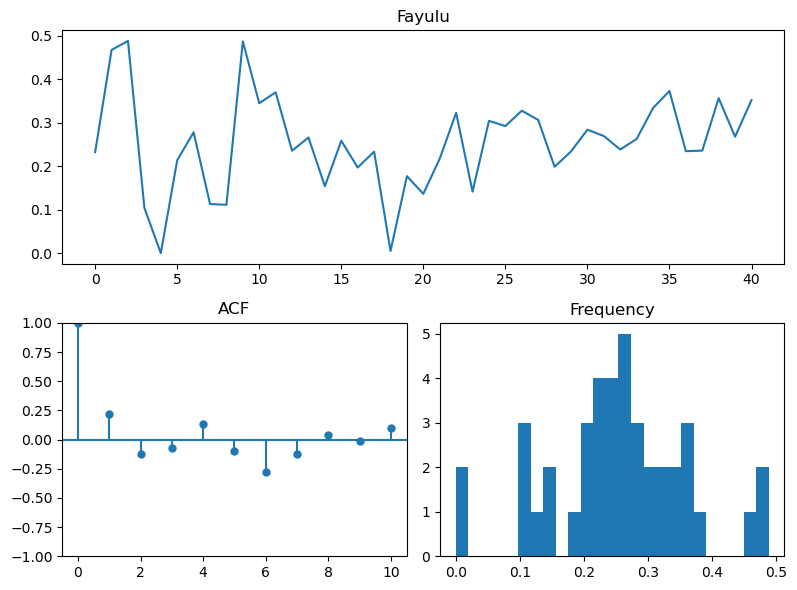

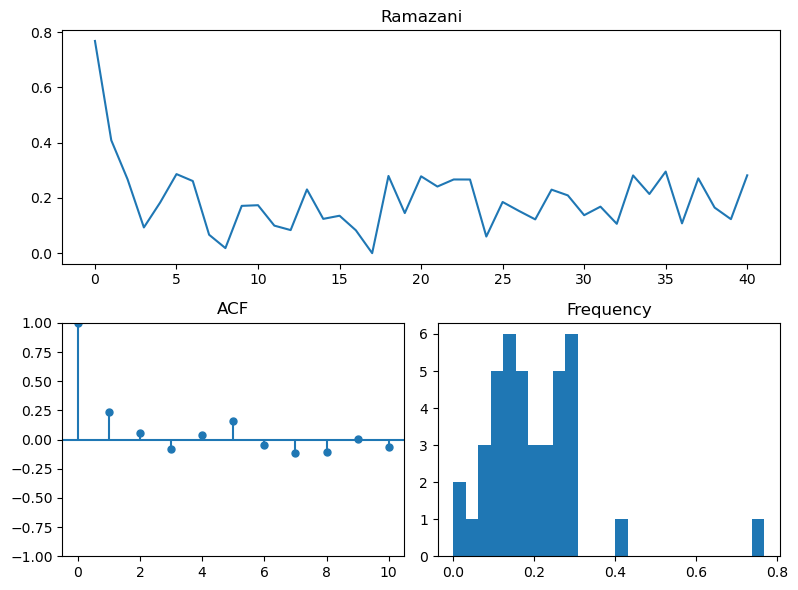

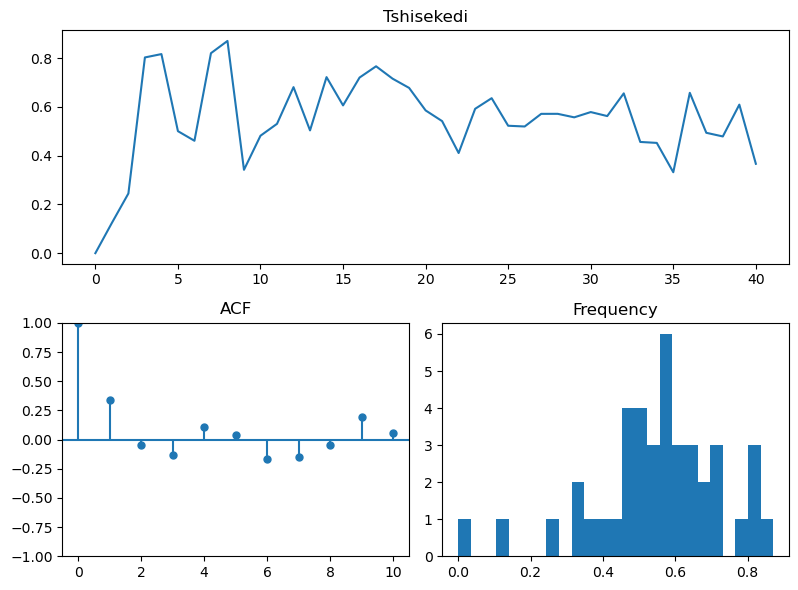

In [55]:
# visual inspection

warnings.filterwarnings('ignore')
[tsdisplay(globals()[f'p_yhrm_vader_{leader.lower()}'], lag_max=10, title=f'{leader}') for leader in leaders];

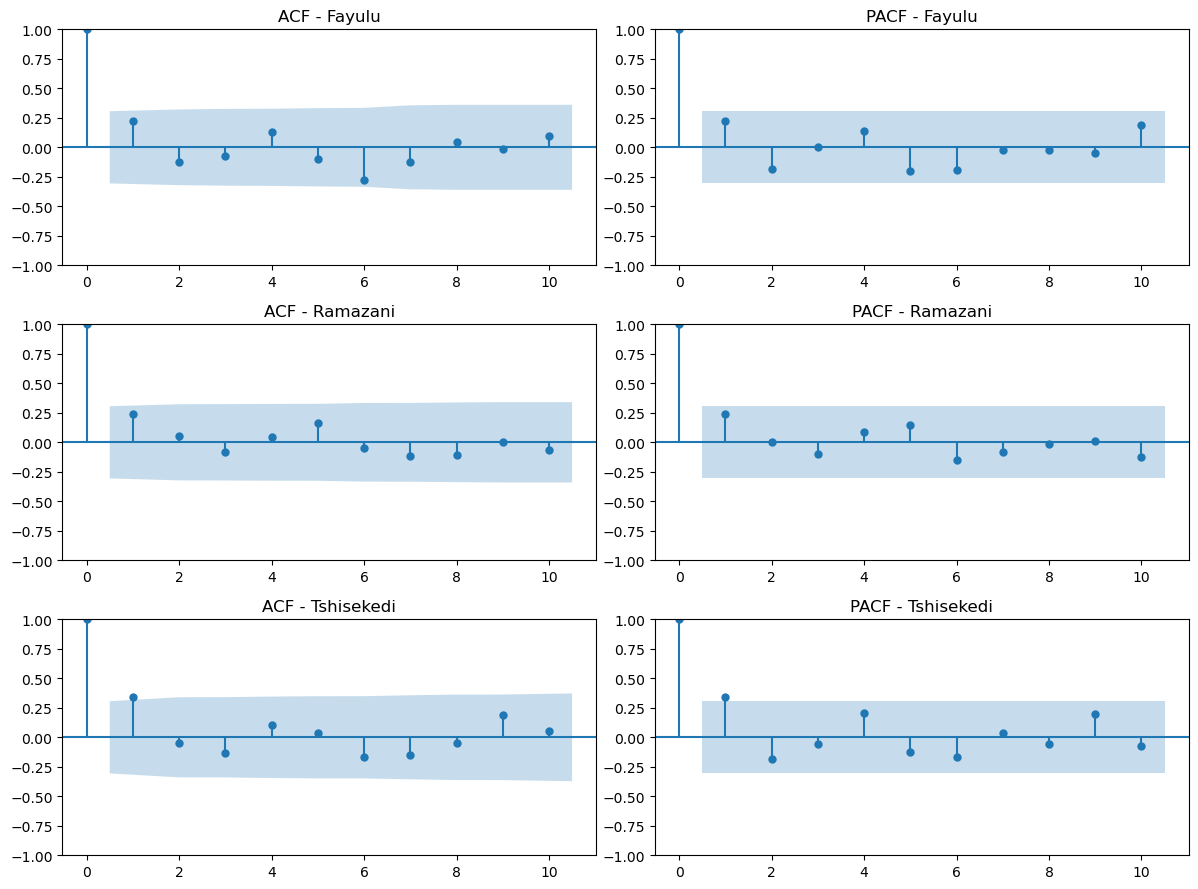

In [56]:
# Correlograms

plot_correlograms('p_yhrm_vader_', lags=10)

In [57]:
# unit root test

adf_b_tssw_vader = calculate_adf_stats('p_yhrm_vader_')
adf_b_tssw_vader

,fayulu,ramazani,tshisekedi
ADF (c),-4.703232,-7.166392e+00,-5.403933
p-value (c),0.000083,2.879000e-10,0.000003
ADF (ct),-4.897331,-6.838703e+00,-4.854596
p-value (ct),0.000315,3.263233e-08,0.000375
ADF (ctt),-4.963348,-6.619204e+00,-4.972414
p-value (ctt),0.001185,5.909259e-07,0.001144


In [58]:
# model selection / parameters fitting

models_p_yhrm_vader, summary_p_yhrm_vader = estimate_arima_models('p_yhrm_vader_')

for leader in leaders:
    print("=" * 50)
    print(f"Fitted model for {leader}")
    print("=" * 50)
    display(models_p_yhrm_vader[leader.lower()].summary())

ARIMA Models for: p_yhrm_vader_

Summary Table:
    Leader                  Series     Order        AIC        BIC
    Fayulu     p_yhrm_vader_fayulu (0, 0, 1) -62.902551 -57.761835
  Ramazani   p_yhrm_vader_ramazani (0, 0, 2) -52.829044 -45.974756
Tshisekedi p_yhrm_vader_tshisekedi (1, 0, 2) -19.206535 -12.352247
Fitted model for Fayulu


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(0, 0, 1)   Log Likelihood                  34.451
Date:                Tue, 18 Nov 2025   AIC                            -62.903
Time:                        17:50:54   BIC                            -57.762
Sample:                    11-20-2018   HQIC                           -61.031
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2545      0.021     12.071      0.000       0.213       0.296
ma.L1          0.2873      0.154      1.870      0.061      -0.014       0.588
sigma2         0.0109      0.002      4.975      0.000       0.007       0.015
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.31
Prob(Q):                              0.93   Prob(JB):                         0.86
Heteroskedasticity (H):               0.17   Skew:                            -0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.42
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Ramazani


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(0, 0, 2)   Log Likelihood                  30.415
Date:                Tue, 18 Nov 2025   AIC                            -52.829
Time:                        17:50:54   BIC                            -45.975
Sample:                    11-20-2018   HQIC                           -50.333
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2094      0.043      4.924      0.000       0.126       0.293
ma.L1          0.4822      0.181      2.662      0.008       0.127       0.837
ma.L2          0.4534      0.226      2.011      0.044       0.011       0.895
sigma2         0.0131      0.003      4.169      0.000       0.007       0.019
===================================================================================
Ljung-Box (L1) (Q):                   1.88   Jarque-Bera (JB):                58.46
Prob(Q):                              0.17   Prob(JB):                         0.00
Heteroskedasticity (H):               0.32   Skew:                             1.59
Prob(H) (two-sided):                  0.04   Kurtosis:                         7.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Tshisekedi


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(1, 0, 2)   Log Likelihood                  13.603
Date:                Tue, 18 Nov 2025   AIC                            -19.207
Time:                        17:50:54   BIC                            -12.352
Sample:                    11-20-2018   HQIC                           -16.711
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9923      0.019     51.461      0.000       0.955       1.030
ma.L1         -0.3847      0.157     -2.453      0.014      -0.692      -0.077
ma.L2         -0.2866      0.189     -1.514      0.130      -0.657       0.084
sigma2         0.0284      0.005      6.095      0.000       0.019       0.037
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                15.89
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               0.23   Skew:                             0.89
Prob(H) (two-sided):                  0.01   Kurtosis:                         5.47
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Diagnostics of the Fayulu series


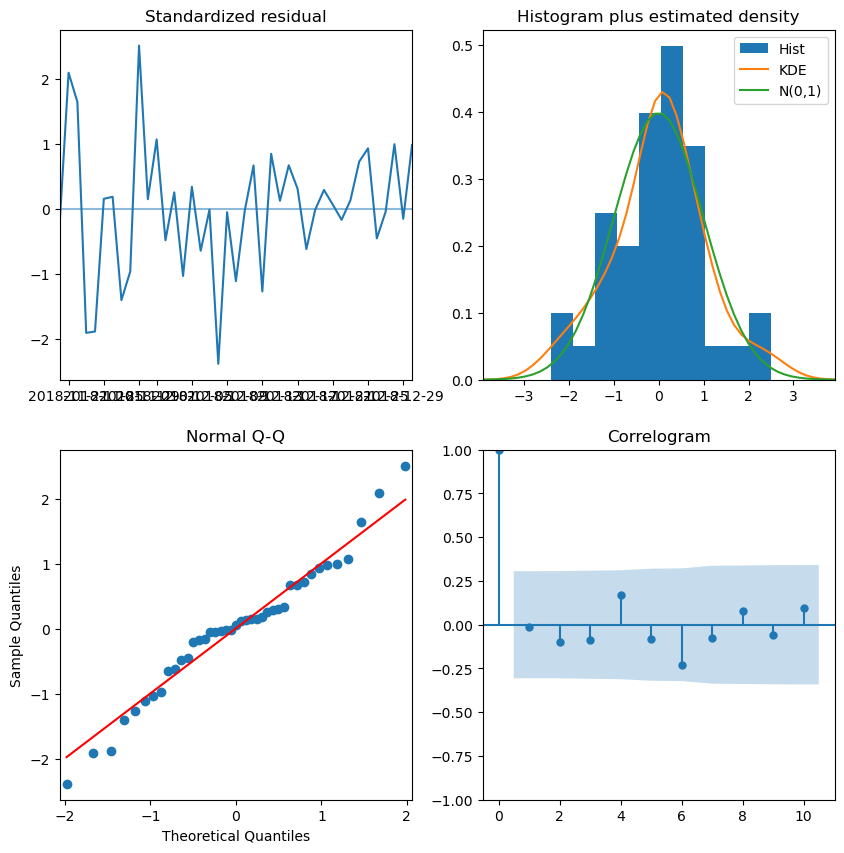

Diagnostics of the Ramazani series


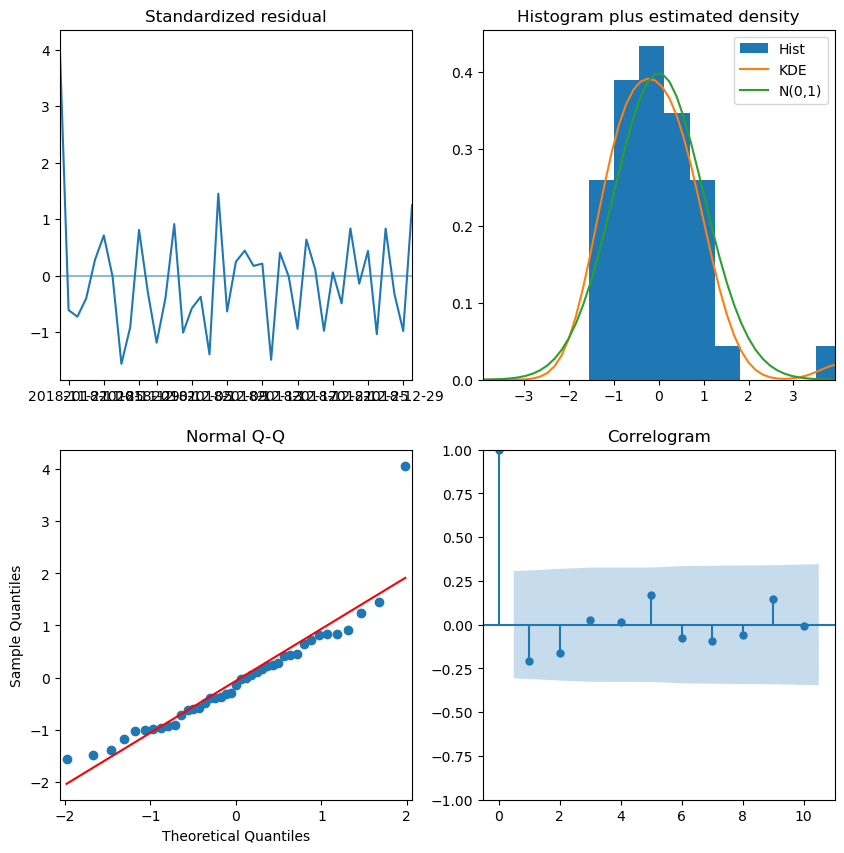

Diagnostics of the Tshisekedi series


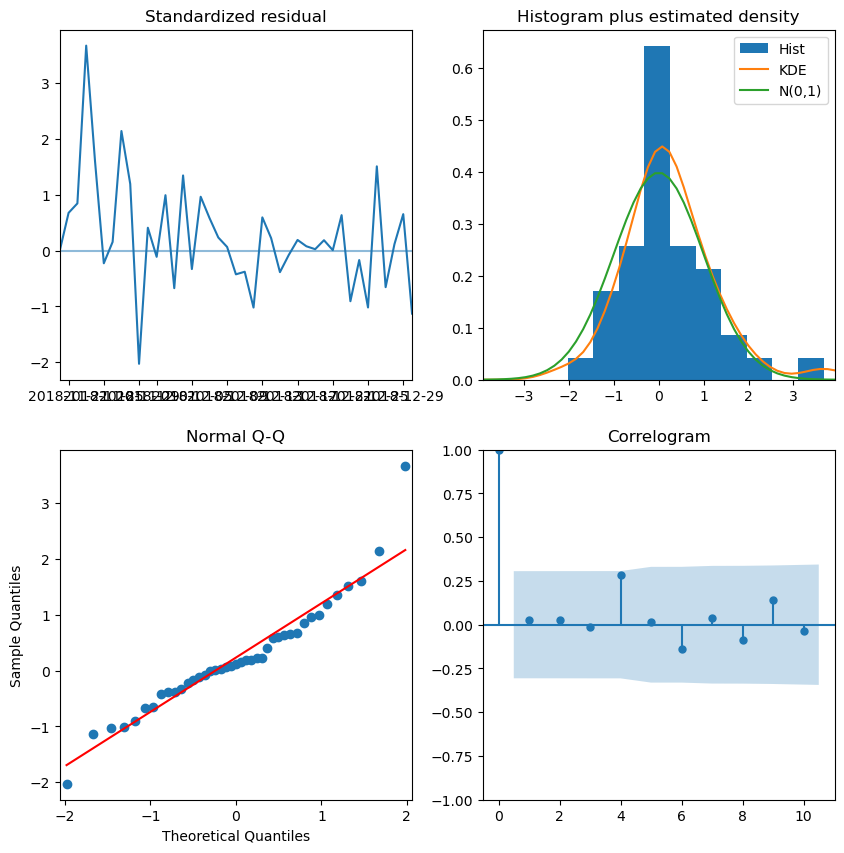

In [59]:
# residual diagnostics / model validation

for leader in leaders:
    print("=" * 50)
    print(f"Diagnostics of the {leader} series")
    print("=" * 50)
    models_p_yhrm_vader[leader.lower()].plot_diagnostics(figsize=(10,10))
    plt.show();

In [60]:
# forecasting (ARIMA vs ARIMA-X)

p_yhrm_vader_predictions = make_predictions(models_p_yhrm_vader)
print('='*50)
print('One-point-ahead forecast for P-YHRM index (VADER)')
print('='*50)
p_yhrm_vader_predictions

One-point-ahead forecast for P-YHRM index (VADER)


,Leader,Forecast,Lower_Bound,Upper_Bound
0,fayulu,0.309618,0.112250,0.455426
1,ramazani,0.248164,0.039288,0.415714
2,tshisekedi,0.442219,0.128405,0.682393


### BERT results

#### P-TSSW

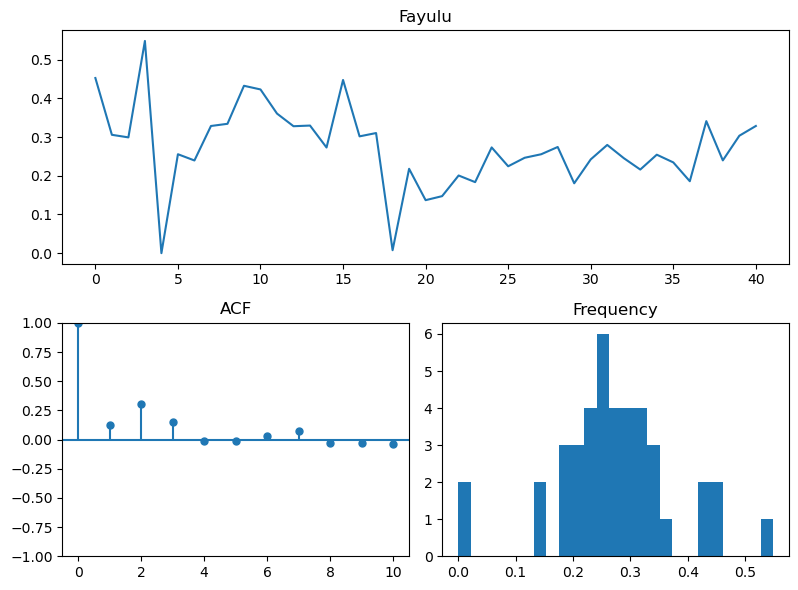

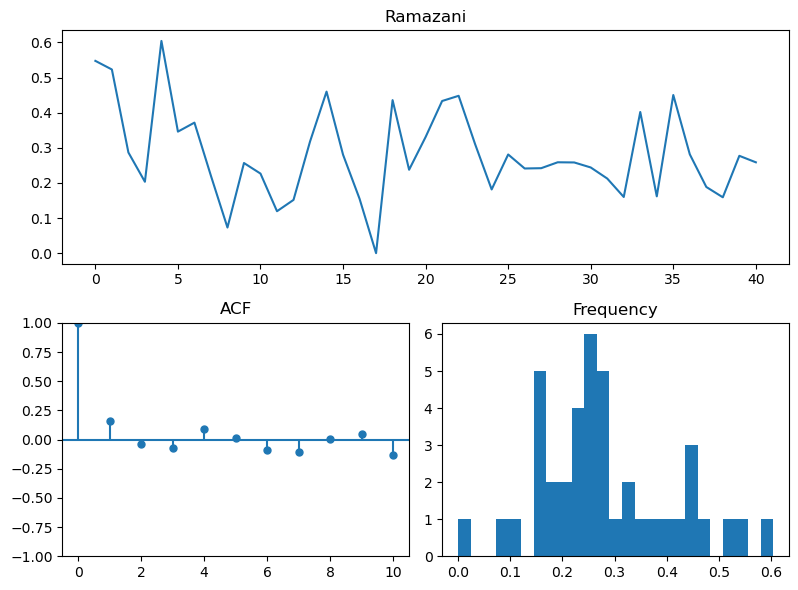

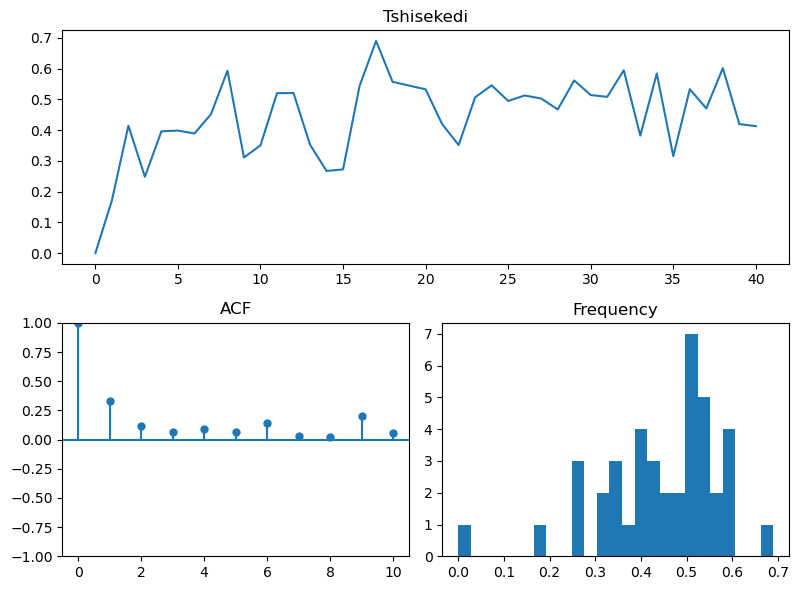

In [61]:
# visual inspection

warnings.filterwarnings('ignore')
[tsdisplay(globals()[f'p_tssw_bert_{leader.lower()}'], lag_max=10, title=f'{leader}') for leader in leaders];

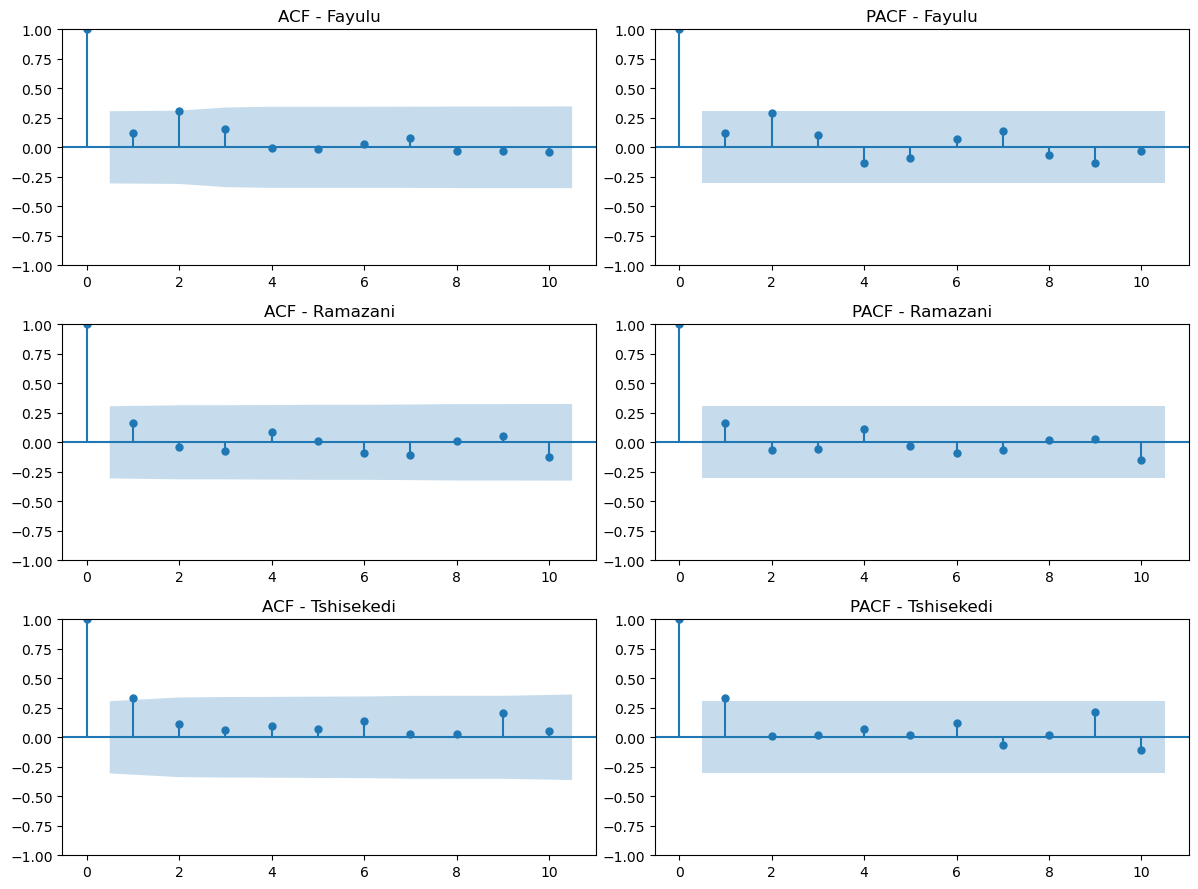

In [62]:
# Correlograms

plot_correlograms('p_tssw_bert_', lags=10)

In [63]:
# unit root test

adf_b_tssw_vader = calculate_adf_stats('p_tssw_bert_')
adf_b_tssw_vader

,fayulu,ramazani,tshisekedi
ADF (c),-3.020672,-5.551076,-5.317180
p-value (c),0.033008,0.000002,0.000005
ADF (ct),-2.997632,-5.559567,-3.651526
p-value (ct),0.132744,0.000018,0.025754
ADF (ctt),-4.303404,-5.518712,-4.561215
p-value (ctt),0.012530,0.000117,0.005270


In [64]:
# model selection / parameters fitting

models_p_tssw_bert, summary_p_tssw_bert = estimate_arima_models('p_tssw_bert_')

for leader in leaders:
    print("=" * 50)
    print(f"Fitted model for {leader}")
    print("=" * 50)
    display(models_p_tssw_bert[leader.lower()].summary())

ARIMA Models for: p_tssw_bert_

Summary Table:
    Leader                 Series     Order        AIC        BIC
    Fayulu     p_tssw_bert_fayulu (0, 0, 0) -65.151857 -61.724713
  Ramazani   p_tssw_bert_ramazani (0, 0, 0) -48.314383 -44.887238
Tshisekedi p_tssw_bert_tshisekedi (0, 1, 1) -50.065343 -46.687584
Fitted model for Fayulu


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:                        SARIMAX   Log Likelihood                  34.576
Date:                Tue, 18 Nov 2025   AIC                            -65.152
Time:                        17:50:59   BIC                            -61.725
Sample:                    11-20-2018   HQIC                           -63.904
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2730      0.016     16.757      0.000       0.241       0.305
sigma2         0.0108      0.002      5.744      0.000       0.007       0.015
===================================================================================
Ljung-Box (L1) (Q):                   0.66   Jarque-Bera (JB):                 2.68
Prob(Q):                              0.42   Prob(JB):                         0.26
Heteroskedasticity (H):               0.13   Skew:                            -0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.23
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Ramazani


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:                        SARIMAX   Log Likelihood                  26.157
Date:                Tue, 18 Nov 2025   AIC                            -48.314
Time:                        17:50:59   BIC                            -44.887
Sample:                    11-20-2018   HQIC                           -47.066
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2827      0.021     13.363      0.000       0.241       0.324
sigma2         0.0163      0.004      4.316      0.000       0.009       0.024
===================================================================================
Ljung-Box (L1) (Q):                   1.14   Jarque-Bera (JB):                 1.53
Prob(Q):                              0.29   Prob(JB):                         0.47
Heteroskedasticity (H):               0.31   Skew:                             0.47
Prob(H) (two-sided):                  0.03   Kurtosis:                         3.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Tshisekedi


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(0, 1, 1)   Log Likelihood                  27.033
Date:                Tue, 18 Nov 2025   AIC                            -50.065
Time:                        17:50:59   BIC                            -46.688
Sample:                    11-20-2018   HQIC                           -48.844
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6642      0.138     -4.824      0.000      -0.934      -0.394
sigma2         0.0149      0.004      4.232      0.000       0.008       0.022
===================================================================================
Ljung-Box (L1) (Q):                   0.68   Jarque-Bera (JB):                 0.37
Prob(Q):                              0.41   Prob(JB):                         0.83
Heteroskedasticity (H):               0.47   Skew:                             0.15
Prob(H) (two-sided):                  0.19   Kurtosis:                         2.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Diagnostics of the Fayulu series


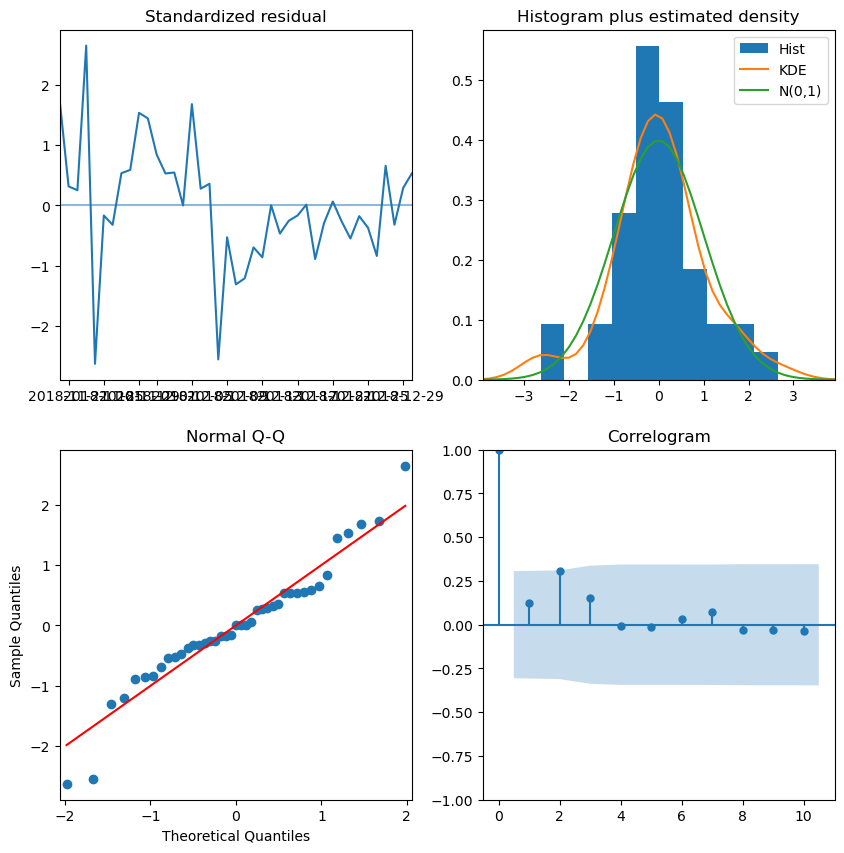

Diagnostics of the Ramazani series


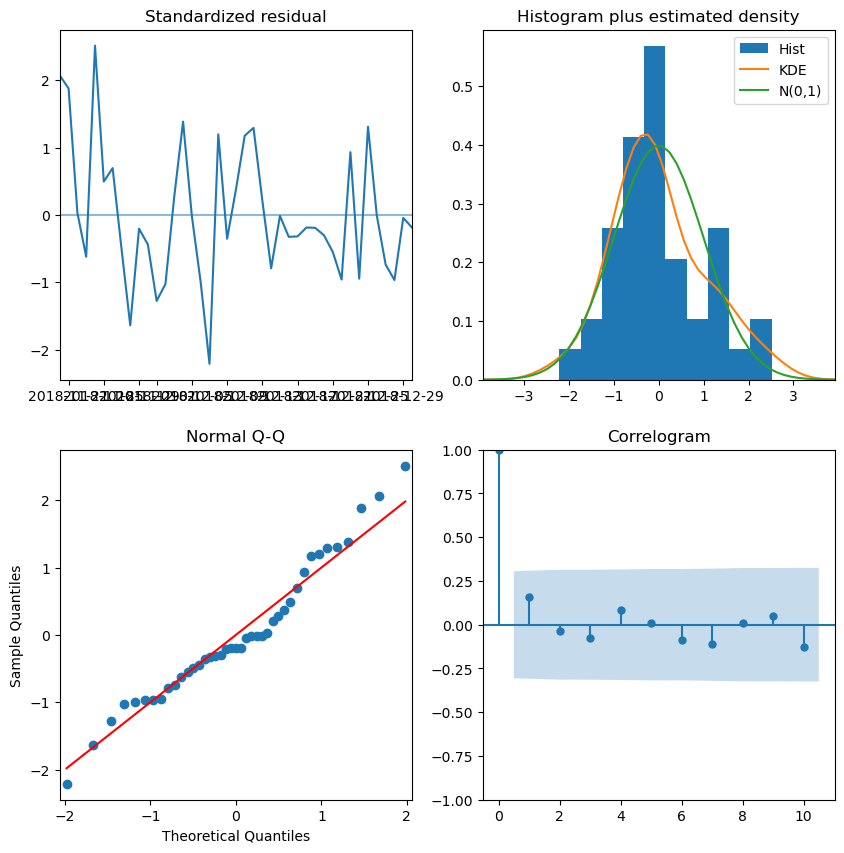

Diagnostics of the Tshisekedi series


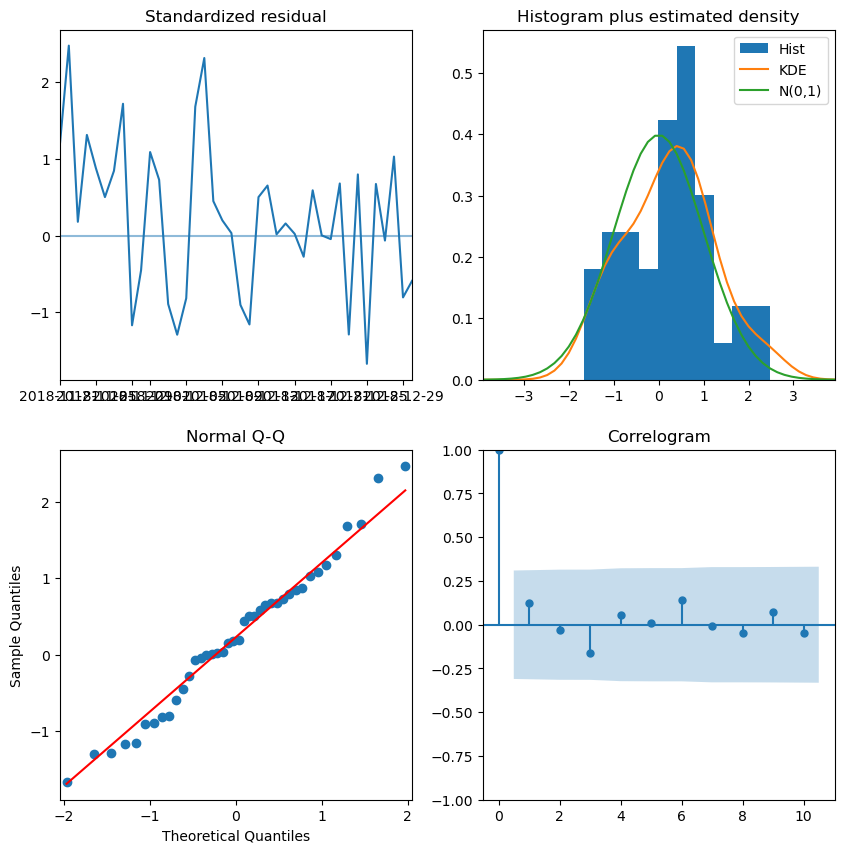

In [65]:
# residual diagnostics / model validation

for leader in leaders:
    print("=" * 50)
    print(f"Diagnostics of the {leader} series")
    print("=" * 50)
    models_p_tssw_bert[leader.lower()].plot_diagnostics(figsize=(10,10))
    plt.show();

In [66]:
# forecasting (ARIMA vs ARIMA-X)

p_tssw_bert_predictions = make_predictions(models_p_tssw_bert)
print('='*50)
print('One-point-ahead forecast for P-TSSW index (BERT)')
print('='*50)
p_tssw_bert_predictions

One-point-ahead forecast for P-TSSW index (BERT)


,Leader,Forecast,Lower_Bound,Upper_Bound
0,fayulu,0.268622,0.101748,0.444258
1,ramazani,0.278204,0.072450,0.493030
2,tshisekedi,0.453174,0.259578,0.661550


#### P-WG

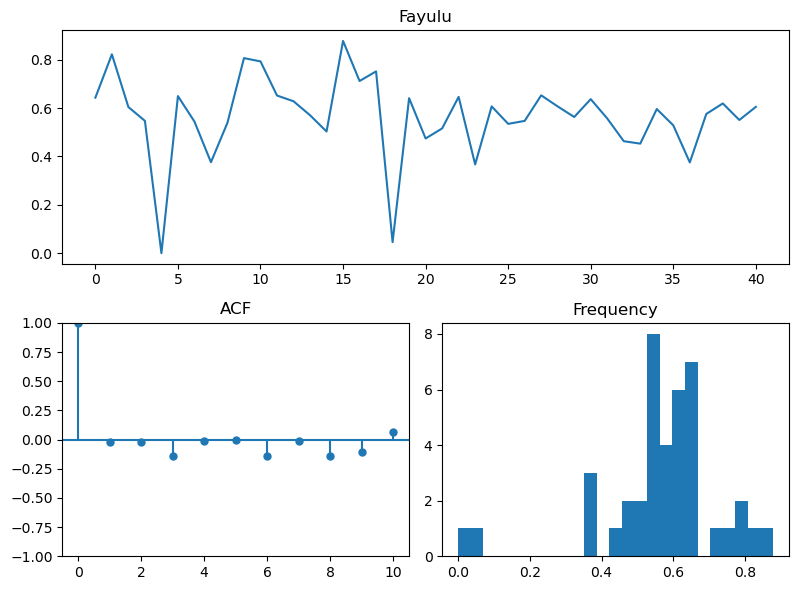

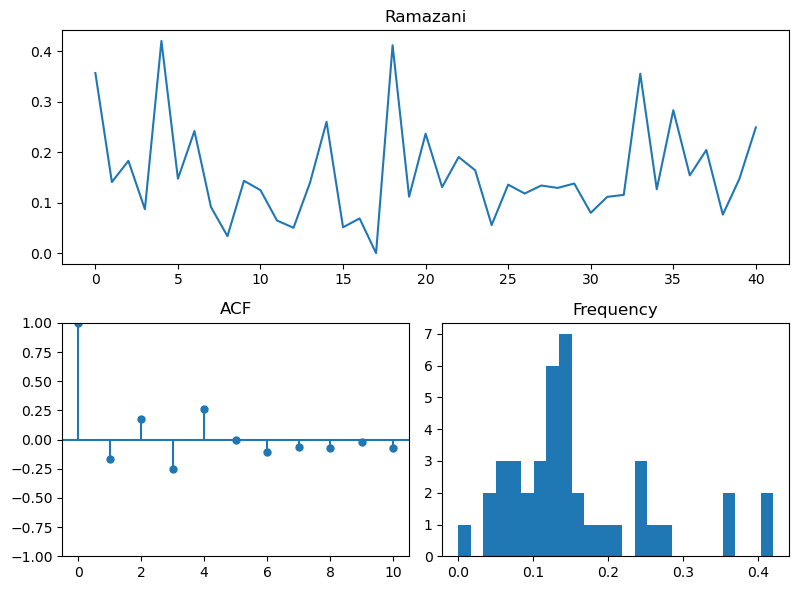

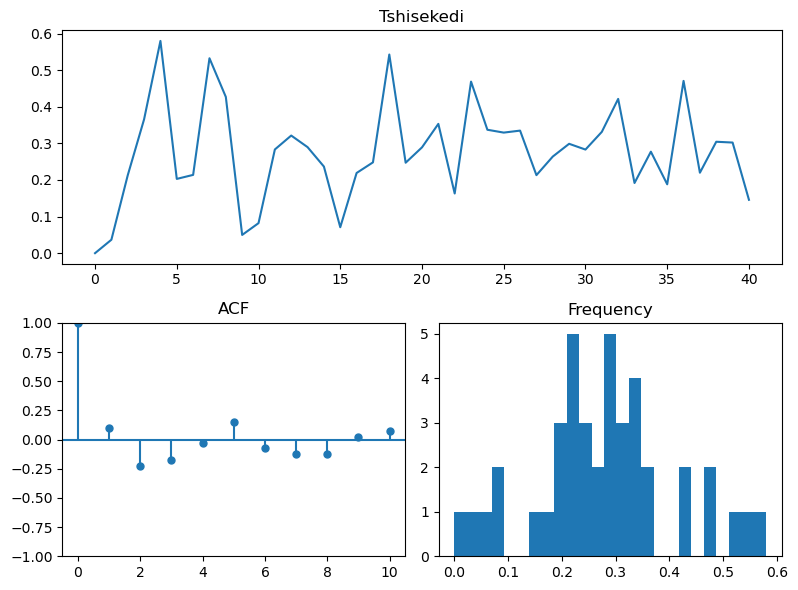

In [67]:
# visual inspection

warnings.filterwarnings('ignore')
[tsdisplay(globals()[f'p_wg_bert_{leader.lower()}'], lag_max=10, title=f'{leader}') for leader in leaders];

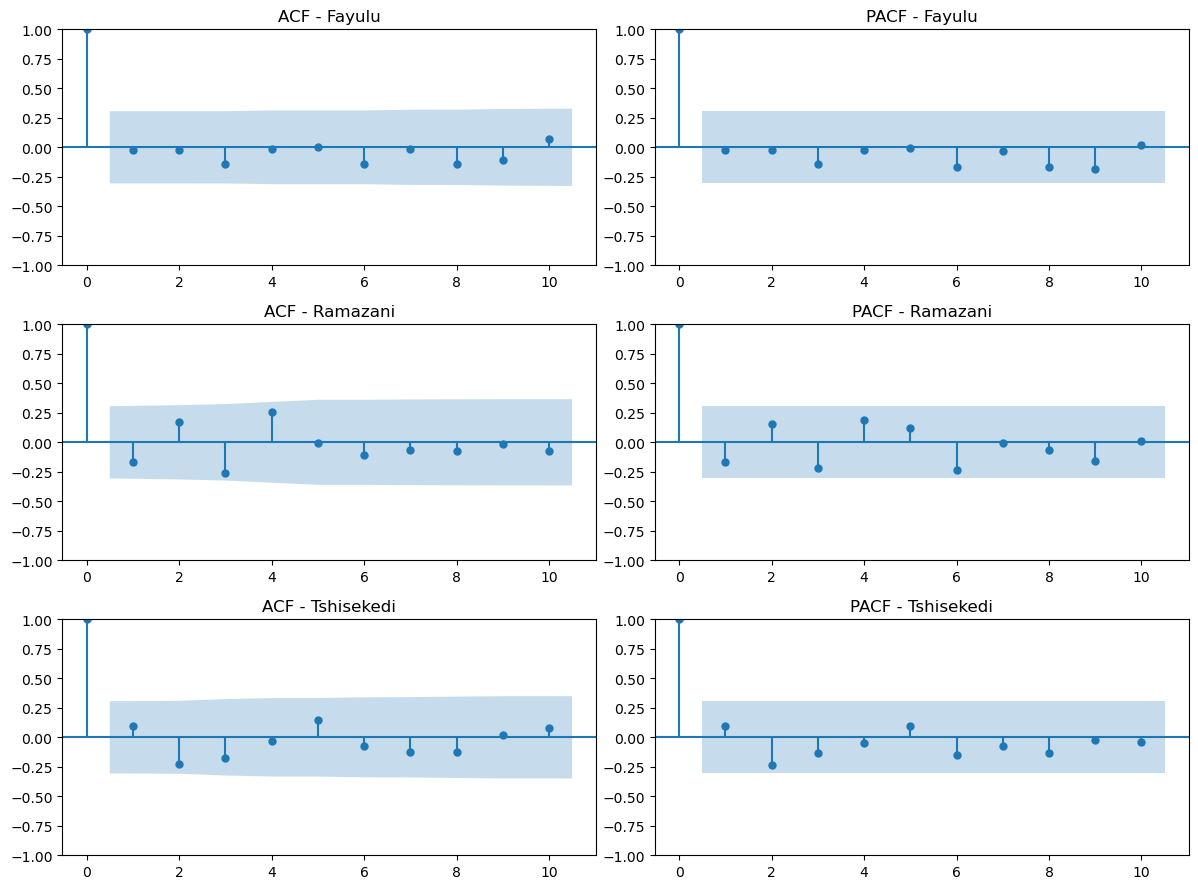

In [68]:
# Correlograms

plot_correlograms('p_wg_bert_', lags=10)

In [69]:
# unit root test

adf_b_tssw_vader = calculate_adf_stats('p_wg_bert_')
adf_b_tssw_vader

,fayulu,ramazani,tshisekedi
ADF (c),-6.331416e+00,-7.701446e+00,-1.898649
p-value (c),2.900097e-08,1.335975e-11,0.332697
ADF (ct),-6.274761e+00,-7.567633e+00,-2.269480
p-value (ct),5.708427e-07,7.120920e-10,0.450899
ADF (ctt),-6.194510e+00,-7.830275e+00,-3.201144
p-value (ctt),4.997233e-06,8.634875e-10,0.208736


In [70]:
# model selection / parameters fitting

models_p_wg_bert, summary_p_wg_bert = estimate_arima_models('p_wg_bert_')

for leader in leaders:
    print("=" * 50)
    print(f"Fitted model for {leader}")
    print("=" * 50)
    display(models_p_wg_bert[leader.lower()].summary())

ARIMA Models for: p_wg_bert_

Summary Table:
    Leader               Series     Order        AIC        BIC
    Fayulu     p_wg_bert_fayulu (0, 0, 0) -26.760436 -23.333291
  Ramazani   p_wg_bert_ramazani (3, 0, 2) -71.369592 -59.374588
Tshisekedi p_wg_bert_tshisekedi (2, 0, 0) -44.701146 -37.846857
Fitted model for Fayulu


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:                        SARIMAX   Log Likelihood                  15.380
Date:                Tue, 18 Nov 2025   AIC                            -26.760
Time:                        17:51:06   BIC                            -23.333
Sample:                    11-20-2018   HQIC                           -25.512
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.5656      0.032     17.583      0.000       0.503       0.629
sigma2         0.0276      0.005      6.029      0.000       0.019       0.037
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                33.17
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               0.14   Skew:                            -1.38
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Ramazani


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(3, 0, 2)   Log Likelihood                  42.685
Date:                Tue, 18 Nov 2025   AIC                            -71.370
Time:                        17:51:06   BIC                            -59.375
Sample:                    11-20-2018   HQIC                           -67.002
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.4463      0.096      4.629      0.000       0.257       0.635
ar.L1         -0.7620      0.352     -2.168      0.030      -1.451      -0.073
ar.L2         -0.7301      0.261     -2.796      0.005      -1.242      -0.218
ar.L3         -0.3516      0.182     -1.928      0.054      -0.709       0.006
ma.L1          0.8070      0.598      1.350      0.177      -0.364       1.978
ma.L2          0.9751      1.344      0.726      0.468      -1.658       3.608
sigma2         0.0065      0.008      0.848      0.397      -0.009       0.022
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.61
Prob(Q):                              0.96   Prob(JB):                         0.74
Heteroskedasticity (H):               0.45   Skew:                             0.21
Prob(H) (two-sided):                  0.15   Kurtosis:                         3.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Tshisekedi


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(2, 0, 0)   Log Likelihood                  26.351
Date:                Tue, 18 Nov 2025   AIC                            -44.701
Time:                        17:51:06   BIC                            -37.847
Sample:                    11-20-2018   HQIC                           -42.205
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3230      0.077      4.187      0.000       0.172       0.474
ar.L1          0.1147      0.175      0.656      0.512      -0.228       0.457
ar.L2         -0.2709      0.223     -1.214      0.225      -0.708       0.166
sigma2         0.0161      0.005      3.557      0.000       0.007       0.025
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 0.74
Prob(Q):                              0.85   Prob(JB):                         0.69
Heteroskedasticity (H):               0.38   Skew:                             0.30
Prob(H) (two-sided):                  0.08   Kurtosis:                         2.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Diagnostics of the Fayulu series


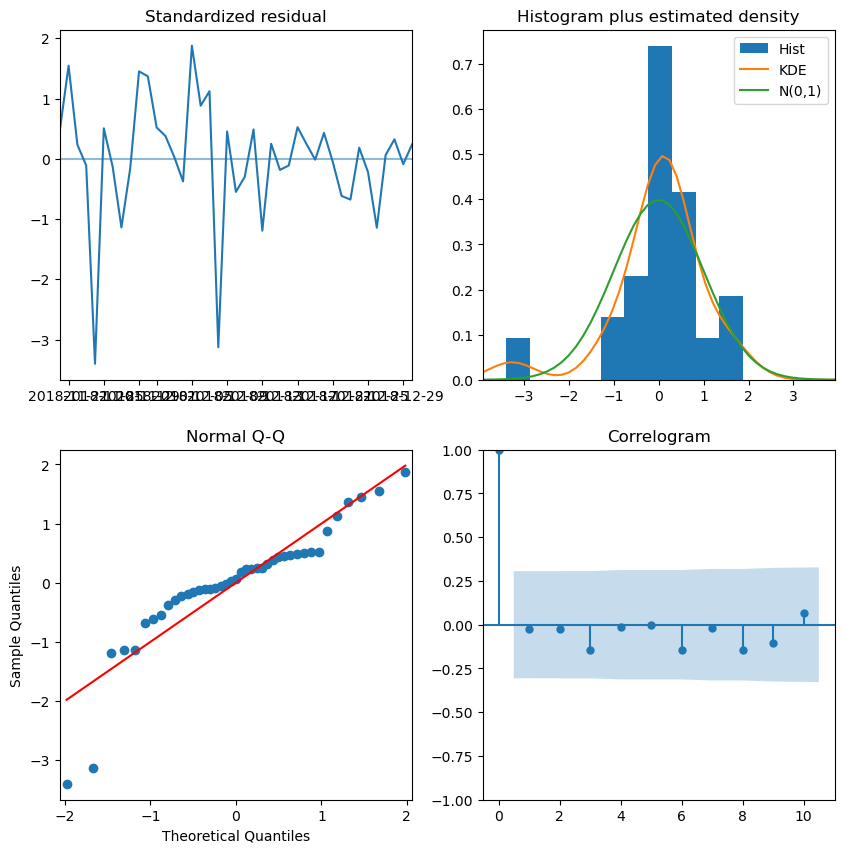

Diagnostics of the Ramazani series


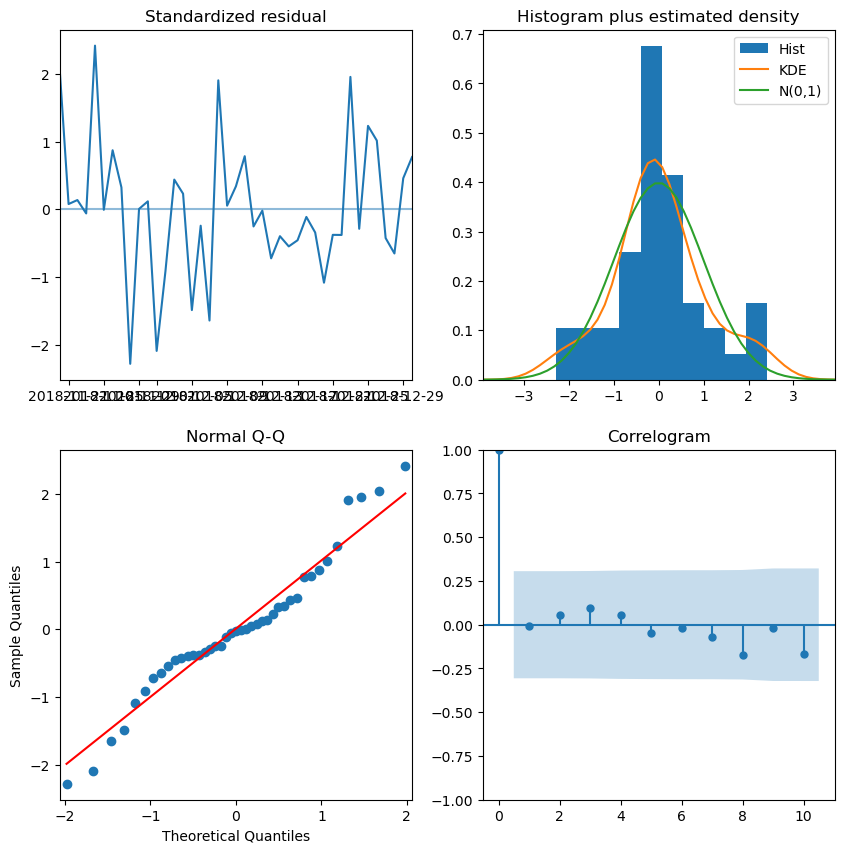

Diagnostics of the Tshisekedi series


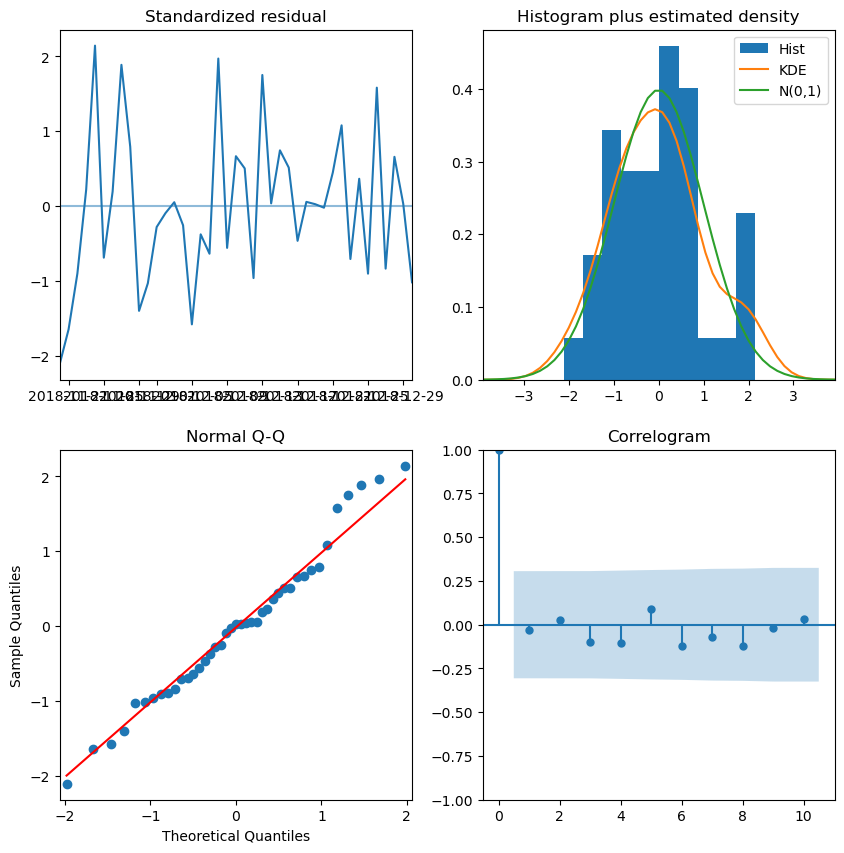

In [71]:
# residual diagnostics / model validation

for leader in leaders:
    print("=" * 50)
    print(f"Diagnostics of the {leader} series")
    print("=" * 50)
    models_p_wg_bert[leader.lower()].plot_diagnostics(figsize=(10,10))
    plt.show();

In [72]:
# forecasting (ARIMA vs ARIMA-X)

p_wg_bert_predictions = make_predictions(models_p_wg_bert)
print('='*50)
print('One-point-ahead forecast for P-WG index (BERT)')
print('='*50)
p_wg_bert_predictions

One-point-ahead forecast for P-WG index (BERT)


,Leader,Forecast,Lower_Bound,Upper_Bound
0,fayulu,0.548269,0.292085,0.839106
1,ramazani,0.201758,0.073967,0.342301
2,tshisekedi,0.249973,0.048992,0.466754


#### P-YHRM

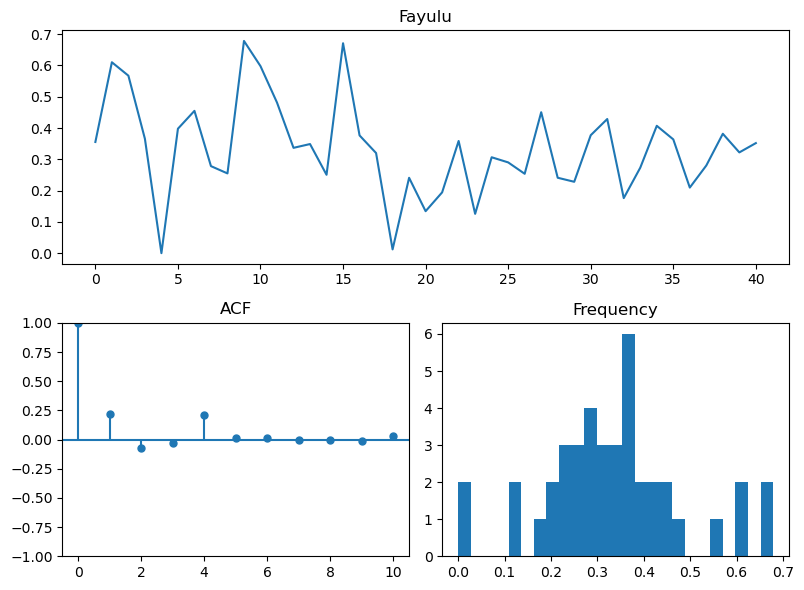

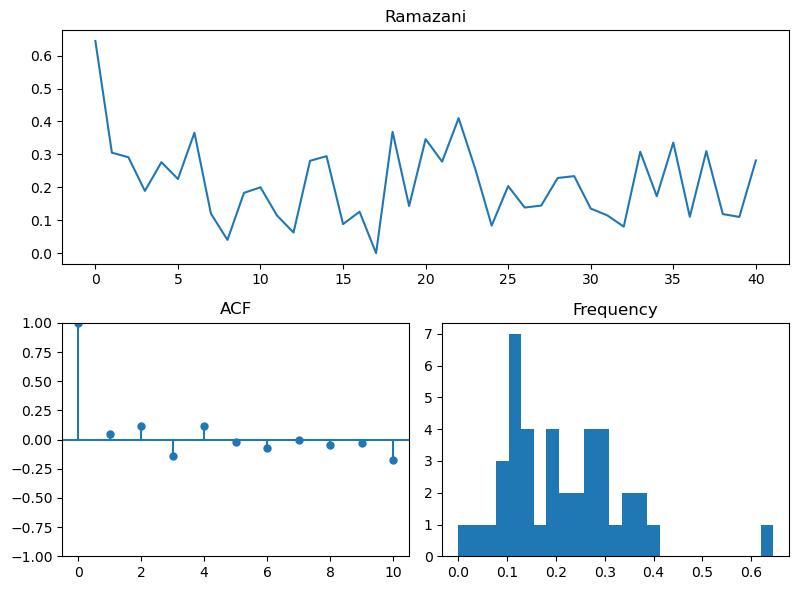

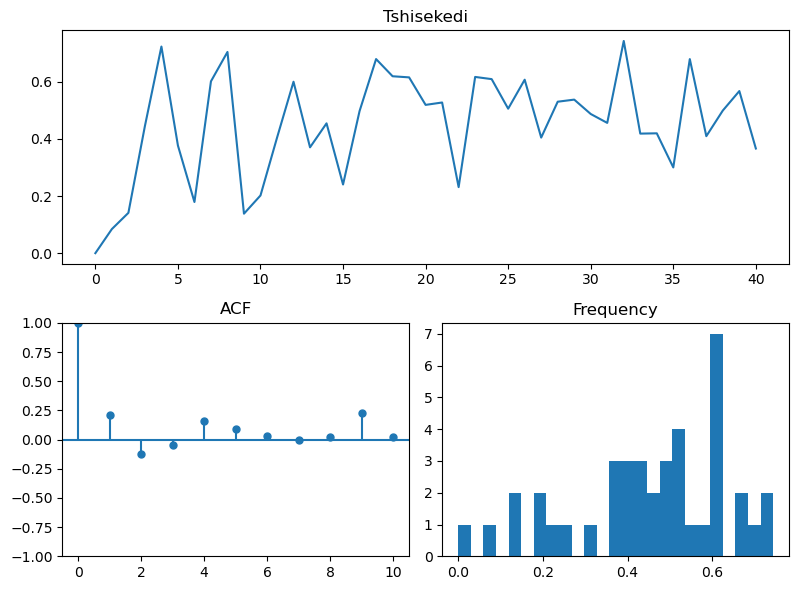

In [73]:
# visual inspection

warnings.filterwarnings('ignore')
[tsdisplay(globals()[f'p_yhrm_bert_{leader.lower()}'], lag_max=10, title=f'{leader}') for leader in leaders];

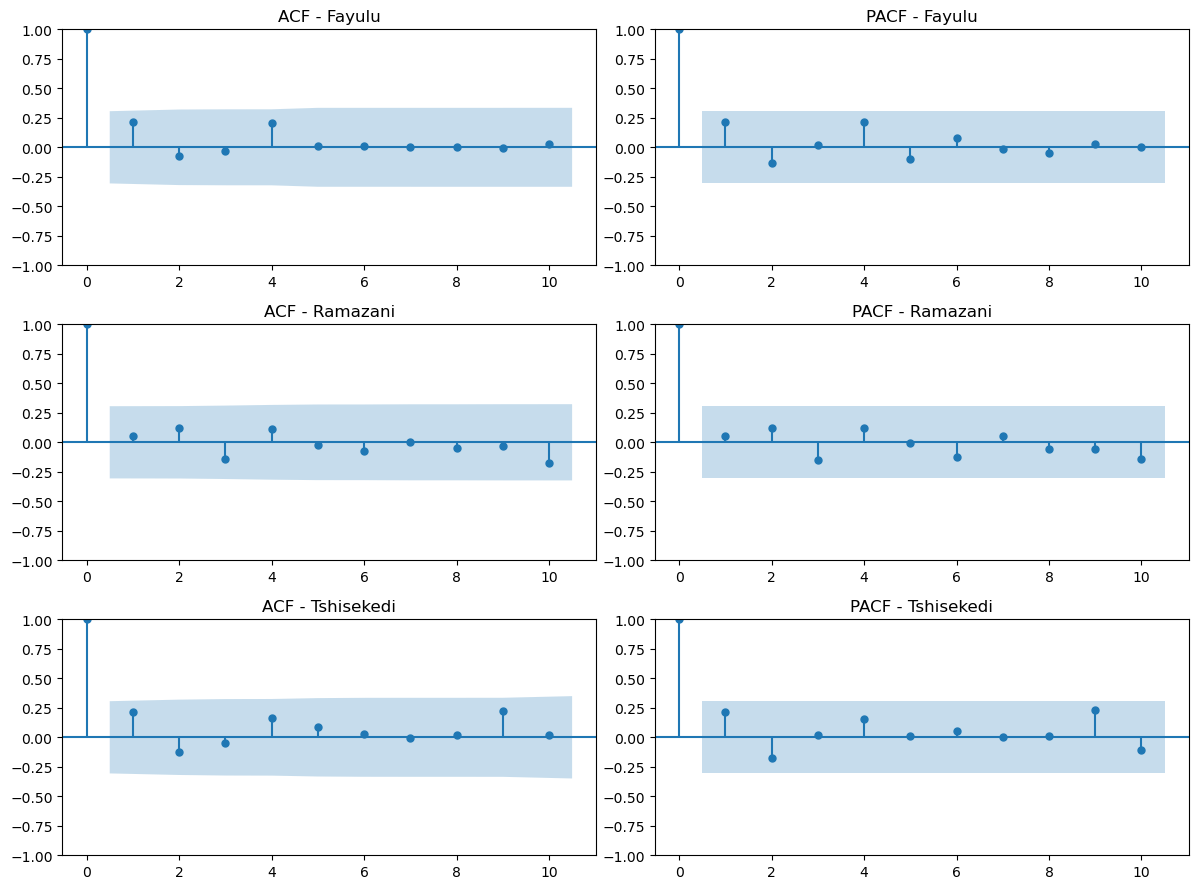

In [74]:
# Correlograms

plot_correlograms('p_yhrm_bert_', lags=10)

In [75]:
# unit root test

adf_b_tssw_vader = calculate_adf_stats('p_yhrm_bert_')
adf_b_tssw_vader

,fayulu,ramazani,tshisekedi
ADF (c),-4.940061,-3.113246,-5.415322
p-value (c),0.000029,0.025588,0.000003
ADF (ct),-5.159649,-3.037081,-5.543150
p-value (ct),0.000104,0.122007,0.000019
ADF (ctt),-5.392433,-2.932890,-4.018718
p-value (ctt),0.000203,0.328126,0.029858


In [76]:
# model selection / parameters fitting

models_p_yhrm_bert, summary_p_yhrm_bert = estimate_arima_models('p_yhrm_bert_')

for leader in leaders:
    print("=" * 50)
    print(f"Fitted model for {leader}")
    print("=" * 50)
    display(models_p_yhrm_bert[leader.lower()].summary())

ARIMA Models for: p_yhrm_bert_

Summary Table:
    Leader                 Series     Order        AIC        BIC
    Fayulu     p_yhrm_bert_fayulu (0, 0, 1) -35.231562 -30.090846
  Ramazani   p_yhrm_bert_ramazani (0, 0, 0) -52.646915 -49.219771
Tshisekedi p_yhrm_bert_tshisekedi (2, 1, 1) -16.690794  -9.935276
Fitted model for Fayulu


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(0, 0, 1)   Log Likelihood                  20.616
Date:                Tue, 18 Nov 2025   AIC                            -35.232
Time:                        17:51:12   BIC                            -30.091
Sample:                    11-20-2018   HQIC                           -33.360
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3354      0.029     11.620      0.000       0.279       0.392
ma.L1          0.2471      0.198      1.251      0.211      -0.140       0.634
sigma2         0.0214      0.004      5.123      0.000       0.013       0.030
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.18
Prob(Q):                              0.99   Prob(JB):                         0.56
Heteroskedasticity (H):               0.26   Skew:                             0.21
Prob(H) (two-sided):                  0.02   Kurtosis:                         3.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Ramazani


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:                        SARIMAX   Log Likelihood                  28.323
Date:                Tue, 18 Nov 2025   AIC                            -52.647
Time:                        17:51:12   BIC                            -49.220
Sample:                    11-20-2018   HQIC                           -51.399
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2127      0.022      9.721      0.000       0.170       0.256
sigma2         0.0147      0.003      5.466      0.000       0.009       0.020
===================================================================================
Ljung-Box (L1) (Q):                   0.11   Jarque-Bera (JB):                12.78
Prob(Q):                              0.74   Prob(JB):                         0.00
Heteroskedasticity (H):               0.35   Skew:                             0.99
Prob(H) (two-sided):                  0.06   Kurtosis:                         4.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Fitted model for Tshisekedi


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   41
Model:               SARIMAX(2, 1, 1)   Log Likelihood                  12.345
Date:                Tue, 18 Nov 2025   AIC                            -16.691
Time:                        17:51:12   BIC                             -9.935
Sample:                    11-20-2018   HQIC                           -14.248
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1106      0.175      0.632      0.527      -0.232       0.453
ar.L2         -0.2924      0.241     -1.213      0.225      -0.765       0.180
ma.L1         -0.7952      0.143     -5.565      0.000      -1.075      -0.515
sigma2         0.0305      0.008      3.754      0.000       0.015       0.046
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                 0.13
Prob(Q):                              0.72   Prob(JB):                         0.94
Heteroskedasticity (H):               0.41   Skew:                             0.10
Prob(H) (two-sided):                  0.12   Kurtosis:                         2.80
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Diagnostics of the Fayulu series


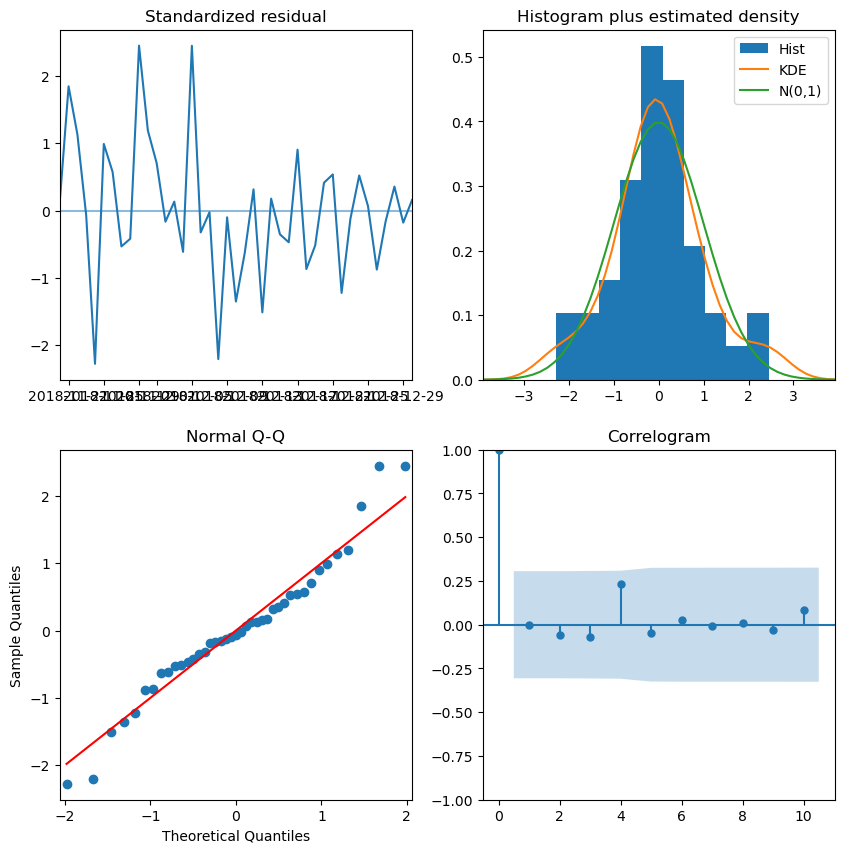

Diagnostics of the Ramazani series


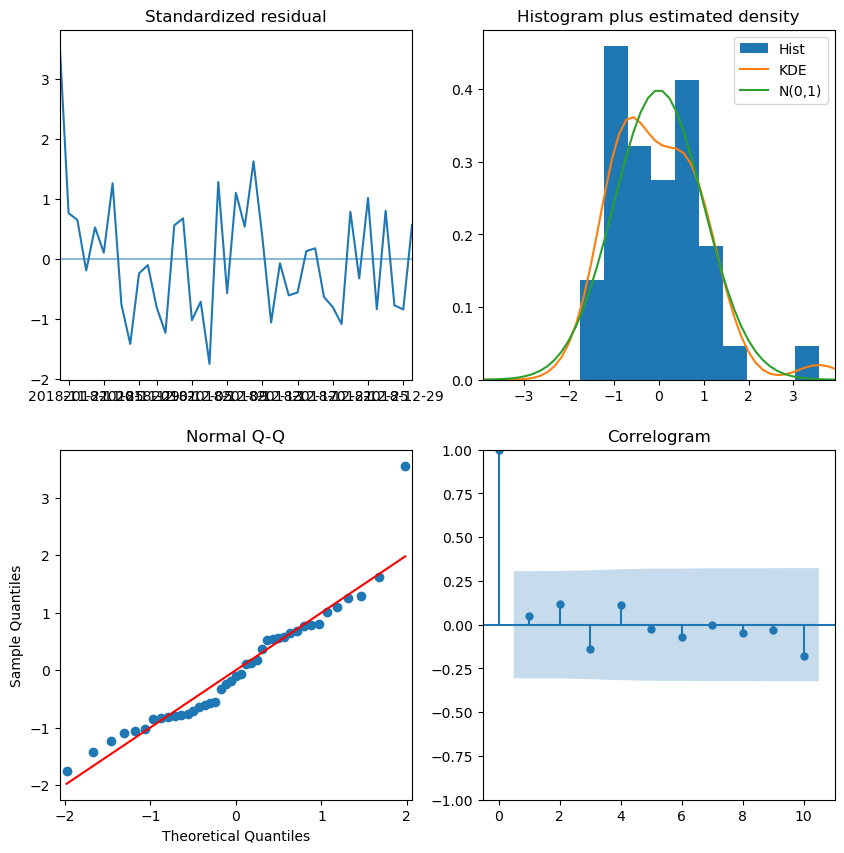

Diagnostics of the Tshisekedi series


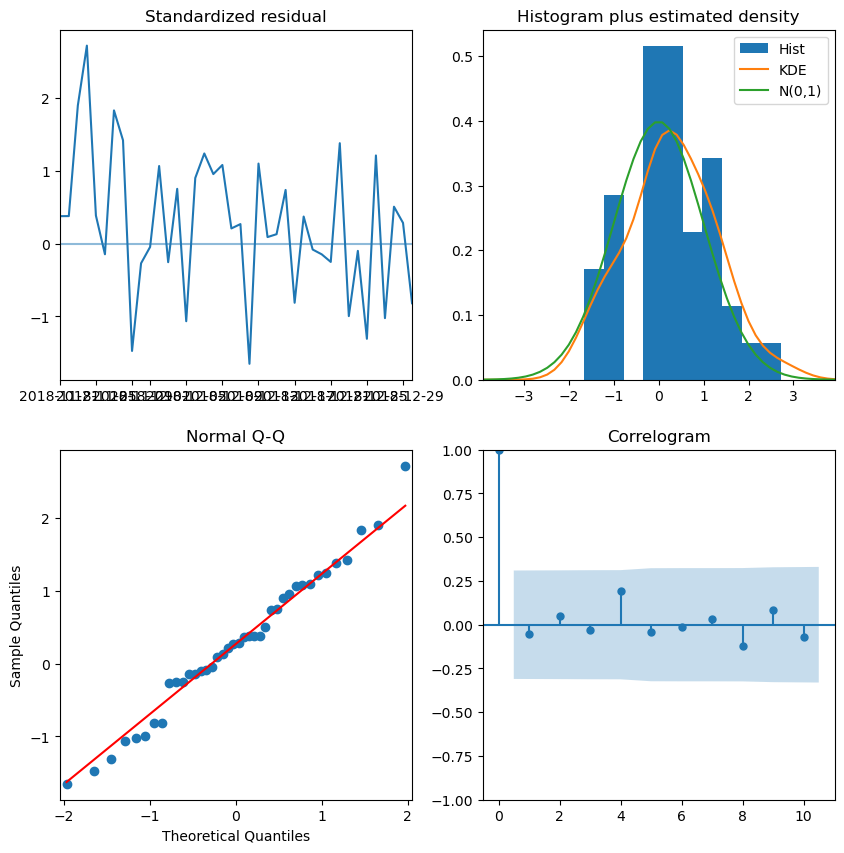

In [77]:
# residual diagnostics / model validation

for leader in leaders:
    print("=" * 50)
    print(f"Diagnostics of the {leader} series")
    print("=" * 50)
    models_p_yhrm_bert[leader.lower()].plot_diagnostics(figsize=(10,10))
    plt.show();

In [78]:
# forecasting (ARIMA vs ARIMA-X)

p_yhrm_bert_predictions = make_predictions(models_p_yhrm_bert)
print('='*50)
print('One-point-ahead forecast for P-YHRM index (BERT)')
print('='*50)
p_yhrm_bert_predictions

One-point-ahead forecast for P-YHRM index (BERT)


,Leader,Forecast,Lower_Bound,Upper_Bound
0,fayulu,0.343866,0.100555,0.581616
1,ramazani,0.214446,0.013244,0.412180
2,tshisekedi,0.441688,0.150780,0.725452


## Combining all predictions

In [79]:
# List all prediction dataframes
prediction_dfs = [
    (b_tssw_vader_predictions, 'baseline', 'TSSW', 'VADER'),
    (b_tssw_bert_predictions, 'baseline', 'TSSW', 'BERT'),
    (b_wg_vader_predictions, 'baseline', 'WG', 'VADER'),
    (b_wg_bert_predictions, 'baseline', 'WG', 'BERT'),
    (b_yhrm_vader_predictions, 'baseline', 'YHRM', 'VADER'),
    (b_yhrm_bert_predictions, 'baseline', 'YHRM', 'BERT'),
    (p_tssw_vader_predictions, 'penalized', 'TSSW', 'VADER'),
    (p_tssw_bert_predictions, 'penalized', 'TSSW', 'BERT'),
    (p_wg_vader_predictions, 'penalized', 'WG', 'VADER'),
    (p_wg_bert_predictions, 'penalized', 'WG', 'BERT'),
    (p_yhrm_vader_predictions, 'penalized', 'YHRM', 'VADER'),
    (p_yhrm_bert_predictions, 'penalized', 'YHRM', 'BERT')
]

In [80]:
# Extract metadata from dataframe names and combine
combined_data = []

for df, variant, index, approach in prediction_dfs:
    df_copy = df[['Leader', 'Forecast']].copy()
    df_copy['Variant'] = variant
    df_copy['Index'] = index
    df_copy['Approach'] = approach
    combined_data.append(df_copy)

In [81]:
# Combine all dataframes
predictions_data = pd.concat(combined_data, ignore_index=True)
predictions_data = predictions_data[['Variant', 'Index', 'Approach', 'Leader', 'Forecast']]
predictions_data = predictions_data.sort_values(['Variant', 'Index', 'Approach', 'Leader']).reset_index(drop=True)
predictions_data.info()
predictions_data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variant   36 non-null     object 
 1   Index     36 non-null     object 
 2   Approach  36 non-null     object 
 3   Leader    36 non-null     object 
 4   Forecast  36 non-null     float64
dtypes: float64(1), object(4)
memory usage: 1.5+ KB


,Variant,Index,Approach,Leader,Forecast
0,baseline,TSSW,BERT,fayulu,0.296594
1,baseline,TSSW,BERT,ramazani,0.324114
2,baseline,TSSW,BERT,tshisekedi,0.379292
3,baseline,TSSW,VADER,fayulu,0.271643
4,baseline,TSSW,VADER,ramazani,0.342571
5,baseline,TSSW,VADER,tshisekedi,0.385786
6,baseline,WG,BERT,fayulu,0.589260
7,baseline,WG,BERT,ramazani,0.197868
8,baseline,WG,BERT,tshisekedi,0.212872
9,baseline,WG,VADER,fayulu,0.581769


In [82]:
# Export to CSV
csv_filename = "predictions_data.csv"
predictions_data.to_csv(csv_filename)
print(f"\nDataFrame successfully exported to: {csv_filename}")


DataFrame successfully exported to: predictions_data.csv
